# Overview of the mini dataset

## Motivation
The performance of a machine learning model is highly dependent on the quality of the dataset used for training. The quality of the dataset can be affected by several factors such as the number of images or the distribution of the classes.  Therefore, it is important to have a good understanding of the dataset before training the model. To simplify a quick exploration of the data, we created a `overview` module. The overview module iterates over all the images found in the given dataset and extracts the needed information of the image or image path. The extracted information are then summarized in a single dataframe.

## Requirements
For this notebook to run, you need have followed the instructions in the `README.md` file within the setup section to install the required packages and setup the dataset. The different paths of the code cell bellow should exist for a successful run of the notebook.

In [1]:

from pathlib import Path

# paths used in the notebook, 
# if you want to run the notebook on other data, please change the paths accordingly.
dataset_path = Path(r"..") / "data" / "mini_dataset"

# path to example images
img_path = dataset_path / "aphanizomenon" / "SPC-EAWAG-0P5X-1570543372901157-3725350526242-001629-055-1224-2176-84-64.jpeg"
img_path_2 = dataset_path / "aphanizomenon" / "SPC-EAWAG-0P5X-1570543374882008-3725352526408-001649-138-1826-1500-72-56.jpeg"

print(f"Dataset path exists: {dataset_path.exists()}")
print(f"First image path exists: {img_path.exists()}")
print(f"Second image path exists: {img_path_2.exists()}") 

Dataset path exists: True
First image path exists: True
Second image path exists: True



# Exploring a single image
Start small by exploring a single image. 

## Loading the image

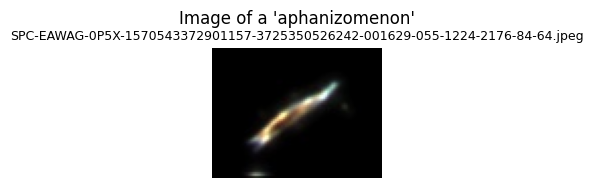

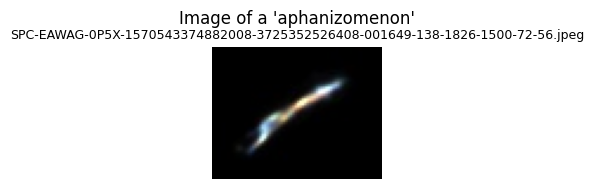

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

def show_image(img_path):
    plt.figure(figsize=(2, 2))
    img = plt.imread(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.suptitle(f"Image of a '{img_path.parent.name}'", fontsize=12)
    plt.title(img_path.name, fontsize=9)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

show_image(img_path)
show_image(img_path_2)

## Generating an overview of the mini dataset

The dictionary below contains the paths to the different versions of the dataset. The paths are used to generate the overview of the dataset and the tag for identifing the version of the dataset for further analysis. Equals the functionality of the configuration "config/dataset_versions.json". 

In [3]:
# define the paths to the data folders of the actual ZooLake versions
zoolake_version_path = {"mini": dataset_path}


The generated overview of the dataset will be stored in a dataframe. The dataframe contains the following columns:

- `image`: The name of the image file
- `hash`: The hash value of the image
- `class`: The class of the image, extracted from the parent folder of the image
- `timestamp`: The timestamp of the image, extracted from the filename of the image (SPC specific)
- `version_*`: Column containing a bool if the image is part of the given version of the dataset

In [4]:
from lit_ecology_classifier.data_overview.overview_creator import OverviewCreator

overview_creator = OverviewCreator(zoolake_version_path)
overview_df = overview_creator.get_overview_df()
overview_df.head()

,image,class,sha256,date,version_mini
0,SPC-EAWAG-0P5X-1591646991657195-12392367470731...,aphanizomenon,8193d264dd6fdeb40234471720ae359cdbb8634c8836e6...,2020-06-08 20:09:51+00:00,True
1,SPC-EAWAG-0P5X-1591628470416286-12373846494770...,aphanizomenon,650b97daf897675b5a2daa085cfb3b2c191148d80e9e9d...,2020-06-08 15:01:10+00:00,True
2,SPC-EAWAG-0P5X-1656774336043045-61281211853089...,aphanizomenon,d207cd30c406d352aabac6073bea40d1477a18972e8cff...,2022-07-02 15:05:36+00:00,True
3,SPC-EAWAG-0P5X-1591610837289696-12356213628703...,aphanizomenon,14bdb4fb957cf02d1ef4a14955f2f3904d42bc1b42af01...,2020-06-08 10:07:17+00:00,True
4,SPC-EAWAG-0P5X-1656766937511689-61273813411030...,aphanizomenon,3279765c63868f36b999e4eb6ca7de31795e0ad18f66de...,2022-07-02 13:02:17+00:00,True


## Exploring the mini dataset

In [5]:
# Check that not two images are duplicate
duplicate_df = overview_creator.get_duplicates_df()

INFO:root:No duplicates found in the dataset


No duplicates found in the dataset


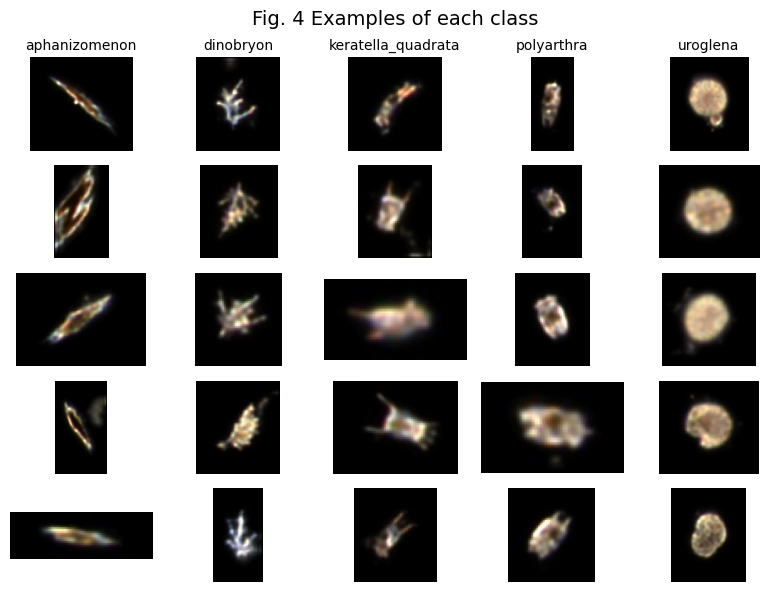

In [6]:
import matplotlib.pyplot as plt
import os
import pandas as pd

def image_examples():
    overview_df["image_path"] = overview_df.apply(lambda x: os.path.join(dataset_path, x["class"], x["image"]), axis=1)
    images_per_class = 5
    classes = overview_df["class"].unique()

    # Erstellen einer Figure mit Subplots
    fig, axes = plt.subplots(images_per_class, len(classes), figsize=(8,6))

    for j, label in enumerate(classes):
        class_images = overview_df[overview_df["class"] == label]["image_path"].head(len(classes))
        
        for i, img_path in enumerate(class_images):
            ax = axes[i, j] 
            img = plt.imread(img_path)
            ax.imshow(img)
            ax.axis("off")
            if i == 0:
                ax.set_title(label, fontsize=10)

    plt.tight_layout()
    plt.suptitle("Fig. 4 Examples of each class", fontsize=14)
    plt.subplots_adjust(top=0.9)
    plt.show()

image_examples()

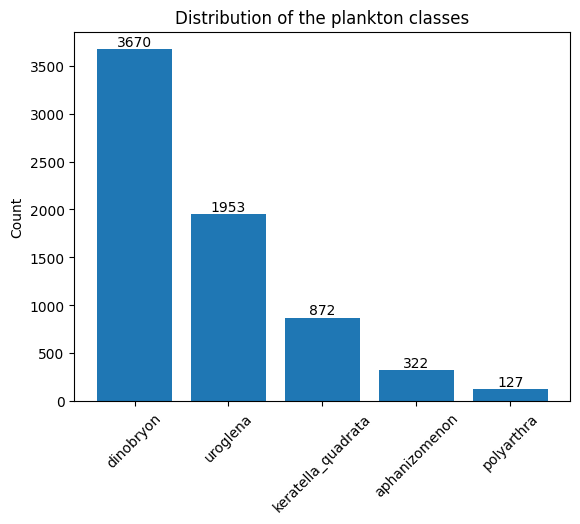

In [7]:
def plot_distributions_of_plankton_classes(df):
    counts_class= df['class'].value_counts()
    order_by_count = list(counts_class.index)
    df['class'] = pd.Categorical(df['class'], order_by_count)
    df = df.sort_values(by='class')
    plt.bar(counts_class.index, counts_class.values)

    # add the count of each class to the bar
    for i, count in enumerate(counts_class.values):
        plt.text(i, count, count, ha='center', va='bottom')
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.title("Distribution of the plankton classes")
    plt.show()


plot_distributions_of_plankton_classes(overview_df)


In [8]:
artifacts_path = dataset_path / '..' / "mini_dataset_artifact"
overview_path = artifacts_path / "overview.csv"

if not artifacts_path.exists():
    artifacts_path.mkdir(parents=True)

overview_creator.save_overview_df(overview_path)

INFO:root:Saved overview to ../data/mini_dataset/../mini_dataset_artifact/overview.csv


# Creation of splits
We now present how the splits for the models and the dataset version are handled inside the plankton classifier pipeline.

## Motivation
The split overview was created with the ambition of keeping informations and track of the used split and allow a simple and understandable reproduction. This makes things simpler, when multiple people work over time independently work on the same project.

The split overview contains: 
$$
\small
\begin{array}{c}
\textbf{Description of the split overview dataframe}\\
\newline
\begin{array}{|l|l|}
\hline
\textbf{Column name} & \textbf{Description} \\
\hline
\text{Dataset version} & \text{Version of the Dataset used for the split} \\
\text{Split strategy} & \text{Used split strategy} \\ 
\text{Filter strategy} & \text{Used filtersplit strategy} \\
\text{Combined split hash} & \text{Hash value to identfiy the split} \\
\text{Description} & \text{Place to add a short description of the split} \\
\text{Args*} & \text{Arguments used inside the filter and split strategy are also saved}\\
\hline
\end{array}
\end{array}
$$

## Creation of a simple split

The simplest way to create a split is to use the build in split strategies based on the `sklearn` library. The built in split strategies are:

- `Stratified`: Creates a stratified split based on the "class" column of the given dataset overview.
- `Random`: Creates a random split based on the given dataset overview.

and the filter strategies:

- `PlanktonFilter`: This filters unwanted images. Can be ignored for the purpose of this exercise.


### Split with random strategy

In [9]:
from lit_ecology_classifier.splitting.split_processor import SplitProcessor

split_args = {"train_size": 0.8}

random_split_processor = SplitProcessor(
                                artefacts_folder= artifacts_path,
                                image_overview= overview_df,
                                split_strategy= "Random",
                                filter_strategy= "PlanktonFilter",
                                split_args= split_args
                                )

random_split_df = random_split_processor.get_split_df()
random_split_df.head()

INFO:lit_ecology_classifier.splitting.split_processor:Arguments do not match, creating a new split.
INFO:lit_ecology_classifier.splitting.split_processor:Creating a new split based on the given split and filter strategy.
INFO:lit_ecology_classifier.splitting.split_processor:No class map provided, generating class map.
INFO:root:Classes to keep based on defined priority classes, if emtpy no prio are set:[] 
             Classes to keep based on defined rest classes. If empty, no class are filtered out: []
INFO:lit_ecology_classifier.splitting.split_processor:Class map generated: {'aphanizomenon': 0, 'dinobryon': 1, 'keratella_quadrata': 2, 'polyarthra': 3, 'uroglena': 4}
INFO:lit_ecology_classifier.splitting.split_processor:Df columns: Index(['image', 'class', 'sha256', 'date', 'version_mini', 'image_path'], dtype='object')


,image,class,sha256,date,version_mini,image_path,class_map,split
0,SPC-EAWAG-0P5X-1591646991657195-12392367470731...,aphanizomenon,8193d264dd6fdeb40234471720ae359cdbb8634c8836e6...,2020-06-08 20:09:51+00:00,True,../data/mini_dataset/aphanizomenon/SPC-EAWAG-0...,0,test
1,SPC-EAWAG-0P5X-1591628470416286-12373846494770...,aphanizomenon,650b97daf897675b5a2daa085cfb3b2c191148d80e9e9d...,2020-06-08 15:01:10+00:00,True,../data/mini_dataset/aphanizomenon/SPC-EAWAG-0...,0,train
2,SPC-EAWAG-0P5X-1656774336043045-61281211853089...,aphanizomenon,d207cd30c406d352aabac6073bea40d1477a18972e8cff...,2022-07-02 15:05:36+00:00,True,../data/mini_dataset/aphanizomenon/SPC-EAWAG-0...,0,train
3,SPC-EAWAG-0P5X-1591610837289696-12356213628703...,aphanizomenon,14bdb4fb957cf02d1ef4a14955f2f3904d42bc1b42af01...,2020-06-08 10:07:17+00:00,True,../data/mini_dataset/aphanizomenon/SPC-EAWAG-0...,0,train
4,SPC-EAWAG-0P5X-1656766937511689-61273813411030...,aphanizomenon,3279765c63868f36b999e4eb6ca7de31795e0ad18f66de...,2022-07-02 13:02:17+00:00,True,../data/mini_dataset/aphanizomenon/SPC-EAWAG-0...,0,train


In [10]:
random_class_map = random_split_processor.get_class_map()
random_split_processor.get_class_map()
random_class_map

{'aphanizomenon': 0,
 'dinobryon': 1,
 'keratella_quadrata': 2,
 'polyarthra': 3,
 'uroglena': 4}

In [11]:
random_split_entry = random_split_processor.get_new_split_entry()
random_split_entry.head()

,split_strategy,filter_strategy,combined_split_hash,description,priority_classes,rest_classes,split_train_size
0,Random,PlanktonFilter,4d1860aa6bfc3ab6f32cb7a4bdc8cc9b0092213b3b0c9c...,None,,,0.8


In [12]:
random_split_processor.save_split("Random split of the mini dataset")

INFO:lit_ecology_classifier.splitting.split_processor:Saving split data to: ../data/mini_dataset/../mini_dataset_artifact/splits/4d1860aa6bfc3ab6f32cb7a4.csv
INFO:lit_ecology_classifier.splitting.split_processor:Split data saved to: ../data/mini_dataset/../mini_dataset_artifact/splits/4d1860aa6bfc3ab6f32cb7a4.csv
INFO:lit_ecology_classifier.splitting.split_processor:Split metadata appended saved to: ../data/mini_dataset/../mini_dataset_artifact/split_overview.csv


In [13]:
random_split_hash = random_split_entry['combined_split_hash'].item()

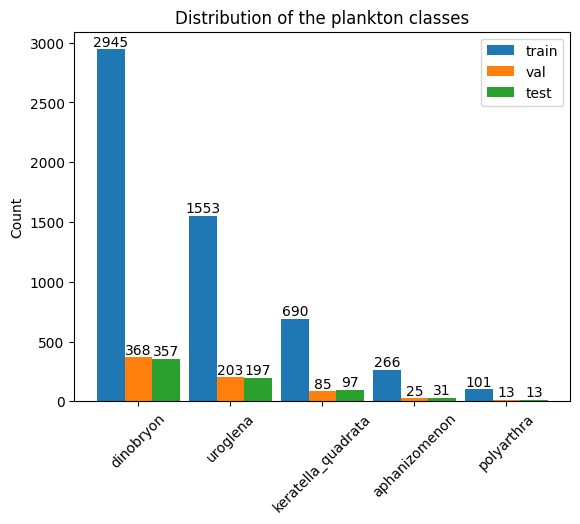

In [14]:
import numpy as np
from matplotlib import pyplot as plt

def plot_distributions_of_plankton_classes_by_split(df, splits=None):


    if splits is None:
        splits=['train','val','test']

    width = .9/len(splits)
    
    for isplit,split in enumerate(splits):
        
        counts_class= df[df['split']==split]['class'].value_counts() 
        order_by_count = list(counts_class.index)
        df['class'] = pd.Categorical(df['class'], order_by_count)
        df = df.sort_values(by='class')
        
        # plt.bar(counts_class.index, counts_class.values, width)
        plt.bar(np.arange(len(counts_class.values))+isplit*width, counts_class.values, width, label=split)
    
        # add the count of each class to the bar
        for i, count in enumerate(counts_class.values):
            plt.text(i+width*isplit, count, count, ha='center', va='bottom')
    plt.ylabel("Count")
    
    plt.xticks(np.arange(len(counts_class.values))+width, counts_class.index,rotation=45)
    plt.legend()
    plt.title("Distribution of the plankton classes")
    plt.show()

plot_distributions_of_plankton_classes_by_split(random_split_df)

### Split with stratified strategy

INFO:lit_ecology_classifier.splitting.split_processor:Arguments do not match, creating a new split.
INFO:lit_ecology_classifier.splitting.split_processor:Creating a new split based on the given split and filter strategy.
INFO:lit_ecology_classifier.splitting.split_processor:No class map provided, generating class map.
INFO:root:Classes to keep based on defined priority classes, if emtpy no prio are set:[] 
             Classes to keep based on defined rest classes. If empty, no class are filtered out: []
INFO:lit_ecology_classifier.splitting.split_processor:Class map generated: {'aphanizomenon': 0, 'dinobryon': 1, 'keratella_quadrata': 2, 'polyarthra': 3, 'uroglena': 4}
INFO:lit_ecology_classifier.splitting.split_processor:Df columns: Index(['image', 'class', 'sha256', 'date', 'version_mini', 'image_path'], dtype='object')
INFO:lit_ecology_classifier.splitting.split_strategies.stratified:Performing stratified split. Shape of data:(6944, 7)
INFO:lit_ecology_classifier.splitting.split_pr

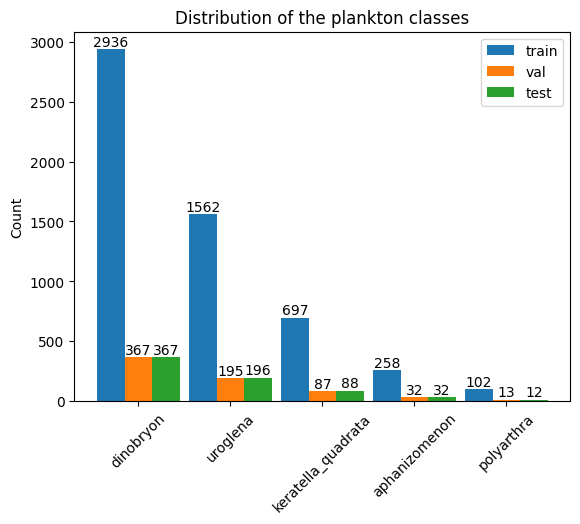

In [15]:
strat_split_processor = SplitProcessor(
                                artefacts_folder= artifacts_path,
                                image_overview= overview_df,
                                split_strategy= "Stratified",
                                filter_strategy= "PlanktonFilter",
                                split_args= split_args
                                )

strat_split_df = strat_split_processor.get_split_df()
strat_split_df.head()
strat_class_map=strat_split_processor.get_class_map()
strat_split_entry = strat_split_processor.get_new_split_entry()
strat_split_processor.save_split("Random split of the mini dataset")
strat_split_hash = strat_split_entry['combined_split_hash'].item()

plot_distributions_of_plankton_classes_by_split(strat_split_df)

## Undersampling

Make an undersampled training set where all the class counts are set to that of the minority class

In [16]:
def undersample(df):
    '''
    Undersamples training set, putting all counts to the minimum count
    '''
    min_counts=min(df[df['split']=='train']['class'].value_counts())
    all_indices=list(df.index)
    indices_keep=[]
    indices_remove=[]
    for my_class in df['class'].unique():
        class_indices_keep   =  df[(df['split']=='train') & (df['class']==my_class)].index[:min_counts].to_list()
        indices_keep.append(class_indices_keep)

    indices_keep=np.ndarray.flatten(np.array(indices_keep))

    
    return pd.concat([df.iloc[indices_keep],df[df['split']=='val'],df[df['split']=='test']])

df_undersampled=undersample(strat_split_df)


Class counts

In [17]:
print('Original dataset')
print('Training set')
print(strat_split_df[strat_split_df['split']=='train']['class'].value_counts())
print('Validation set')
print(strat_split_df[strat_split_df['split']=='val']['class'].value_counts())
print('Test set')
print(strat_split_df[strat_split_df['split']=='test']['class'].value_counts())

Original dataset
Training set
class
dinobryon             2936
uroglena              1562
keratella_quadrata     697
aphanizomenon          258
polyarthra             102
Name: count, dtype: int64
Validation set
class
dinobryon             367
uroglena              195
keratella_quadrata     87
aphanizomenon          32
polyarthra             13
Name: count, dtype: int64
Test set
class
dinobryon             367
uroglena              196
keratella_quadrata     88
aphanizomenon          32
polyarthra             12
Name: count, dtype: int64


Undersampled class counts

In [18]:
print('Undersampled dataset')
print('Training set')
print(df_undersampled[df_undersampled['split']=='train']['class'].value_counts())
print('Validation set')
print(df_undersampled[df_undersampled['split']=='val']['class'].value_counts())
print('Test set')
print(df_undersampled[df_undersampled['split']=='test']['class'].value_counts())

Undersampled dataset
Training set
class
dinobryon             102
uroglena              102
keratella_quadrata    102
aphanizomenon         102
polyarthra            102
Name: count, dtype: int64
Validation set
class
dinobryon             367
uroglena              195
keratella_quadrata     87
aphanizomenon          32
polyarthra             13
Name: count, dtype: int64
Test set
class
dinobryon             367
uroglena              196
keratella_quadrata     88
aphanizomenon          32
polyarthra             12
Name: count, dtype: int64


## Oversampling

Make an undersampled training set where all the class counts are set to that of the minority class

In [19]:
def approximate_oversampling(df):
    '''
    Oversamples training set, by multiplying all the images of the minority class an integer number of times 
    (so the ratio between majority and minority is now <2)
    '''
    max_counts=max(df[df['split']=='train']['class'].value_counts())
    indices=[]
    for my_class in df['class'].unique():
        class_counts=df[(df['split']=='train') & (df['class']==my_class)]['class'].value_counts().values[0]
        factor=int(max_counts/class_counts)
        df_to_replicate=df[(df['class']==my_class) & (df['split']=='train')]
        for i in range(factor-1):
            df=pd.concat([df,df_to_replicate],ignore_index=True)
    
    return df

df_oversampled=approximate_oversampling(strat_split_df)

In [20]:
print('Oversampled dataset')
print('Training set')
print(df_oversampled[df_oversampled['split']=='train']['class'].value_counts())
print('Validation set')
print(df_oversampled[df_oversampled['split']=='val']['class'].value_counts())
print('Test set')
print(df_oversampled[df_oversampled['split']=='test']['class'].value_counts())

Oversampled dataset
Training set
class
dinobryon             2936
polyarthra            2856
aphanizomenon         2838
keratella_quadrata    2788
uroglena              1562
Name: count, dtype: int64
Validation set
class
dinobryon             367
uroglena              195
keratella_quadrata     87
aphanizomenon          32
polyarthra             13
Name: count, dtype: int64
Test set
class
dinobryon             367
uroglena              196
keratella_quadrata     88
aphanizomenon          32
polyarthra             12
Name: count, dtype: int64


# Image Transformations


# Augmentations

# Training


THe model training is based on the [Pytorch Lightning](https://pytorch-lightning.readthedocs.io/en/latest/) framework. It is a high-level interface for Pytorch that makes it easier to train models on multiple GPUs or Clusters.

### LightningDataModule and DataLoaders

Native pytorch dataloaders are used to load the images and labels for the training. The LightningDataModule orchestrates the correct loading of the data and the creation of the dataloaders for training and validation on multiple GPUs.


In [26]:
from lit_ecology_classifier.data.datamodule import DataModule
import logging
from lightning.pytorch.loggers import CSVLogger

train_out = Path("..") / "train_out"
logger = CSVLogger(save_dir= train_out, name='csv_logs')

batch_size=32

datamodule = DataModule(
        datapath= dataset_path,
        dataset = "mini_example",
        batch_size= batch_size,
        splits= df_undersampled,
        augmentation_level = "low",
        resize_with_proportions = True,
        target_size = 224,
)

datamodule.setup()

INFO:root: Extracting class map from tar file.
INFO:lit_ecology_classifier.helpers.helpers:Extracting class map.
INFO:lit_ecology_classifier.helpers.helpers:Detected directory.
INFO:lit_ecology_classifier.helpers.helpers:Found 5 classes.
INFO:root:Class map: {'aphanizomenon': 0, 'dinobryon': 1, 'keratella_quadrata': 2, 'polyarthra': 3, 'uroglena': 4}
INFO:lit_ecology_classifier.data.datamodule:Train size of df: 510
INFO:lit_ecology_classifier.data.datamodule:Validation size of df: 694
INFO:lit_ecology_classifier.data.datamodule:Test size of df: 695


Train size of df:  510
Validation size of df:  694
Test size of df:  695


### Initialize the Model

In [27]:
from lit_ecology_classifier.models.model import LitClassifier

param_path = Path("..") / "params"

model = LitClassifier(
    train_outpath=train_out,     # Output path for training artifacts (models, metrics, ...)
    main_param_path=param_path,  # "Main directory where the training parameters are stored"
    class_map = strat_class_map,
    use_wandb=False,             # Use Weights and Biases for logging
    no_use_multi=False,          # Use multiple GPUs for training
    architecture='mobilenetv3l', # Choose the model architecture (see options in model_mapping dictionary, in ../lit_ecology_classifier/models/setup_model.py)
    add_layer=False,             # Add additional layers to the model
    finetune=False,              # if True, only train the head of the network
    batch_size=batch_size,               # Batch size for training
    lr=1e-5,                     # Learning rate for training
    lr_factor=0.01,              # Learning rate factor for training of full body
    loss="cross_entropy",        # Loss function ["cross_entropy", "focal"]
    testing=False,               # Set this to True if in testing mode, False for training
    no_TTA=False                 # Test-time augmentation - only for predict stage, 
)

model.load_datamodule(datamodule)


INFO:lit_ecology_classifier.models.setup_model:Preparing the model using a cached backbone or downloading from huggingface.
INFO:root:Model initialized with hyperparameters:
 {'add_layer': False,
 'architecture': 'mobilenetv3l',
 'batch_size': 32,
 'class_map': {'aphanizomenon': 0,
               'dinobryon': 1,
               'keratella_quadrata': 2,
               'polyarthra': 3,
               'uroglena': 4},
 'finetune': False,
 'loss': 'cross_entropy',
 'lr': 1e-05,
 'lr_factor': 0.01,
 'main_param_path': PosixPath('../params'),
 'no_TTA': False,
 'no_use_multi': False,
 'num_classes': 5,
 'testing': False,
 'train_outpath': PosixPath('../train_out'),
 'use_wandb': False}


Using standard cross entropy loss


### Pytorch Lightning Trainer


In [23]:
import os

import torch
import lightning as l
import lightning.pytorch as pl
from lightning.pytorch.callbacks import LearningRateMonitor


max_epochs = 50


accelerator = "gpu" if torch.cuda.device_count() else "cpu"
devices = torch.cuda.device_count() if "gpu" in accelerator else os.cpu_count() // 4
strategy ="ddp_notebook" if torch.cuda.device_count() > 1 else "auto"

defined_callbacks = [
    pl.callbacks.ModelCheckpoint(filename="best_model_acc_stage1", monitor="val_acc", mode="max"),
    LearningRateMonitor(logging_interval='step')
    ]


/home/marco/miniconda3/envs/plank/lib/python3.9/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [24]:
trainer = l.Trainer(
        accelerator= accelerator,
        devices=1,
        logger=logger,
        max_epochs= max_epochs,
        log_every_n_steps=40,
        callbacks=[pl.callbacks.ModelCheckpoint(filename="best_model_acc_stage1", monitor="val_acc", mode="max"),LearningRateMonitor(logging_interval='step')],
        check_val_every_n_epoch=max(max_epochs // 8,1),
        strategy= strategy,
        default_root_dir=train_out,
    )


INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


INFO:lit_ecology_classifier.data.datamodule:Train size of df: 510
INFO:lit_ecology_classifier.data.datamodule:Validation size of df: 694
INFO:lit_ecology_classifier.data.datamodule:Test size of df: 695
INFO: 
  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | MobileNetV3      | 4.2 M  | train
1 | loss  | CrossEntropyLoss | 0      | train
---------------------------------------------------
4.2 M     Trainable params
0         Non-trainable params
4.2 M     Total params
16.834    Total estimated model params size (MB)
297       Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | MobileNetV3      | 4.2 M  | train
1 | loss  | CrossEntropyLoss | 0      | train
---------------------------------------------------
4.2 M     Trainable params
0         Non-trainable params
4.2 M   

Train size of df:  510
Validation size of df:  694
Test size of df:  695


Sanity Checking: |                                                                                            …

/media/marco/dropbox-2Tb/Dropbox/LAVORO/PROJECTS/AQUASCOPE/PLANKTON-CLASSIFIER/lit_ecology_classifier/notebooks/lit_ecology_classifier/helpers/modelling_plots.py:121: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  y_axis.set_yscale("log")
/home/marco/miniconda3/envs/plank/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


0


...

41


/home/marco/miniconda3/envs/plank/lib/python3.9/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Validation: |                                                                                                 …

47


/home/marco/miniconda3/envs/plank/lib/python3.9/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


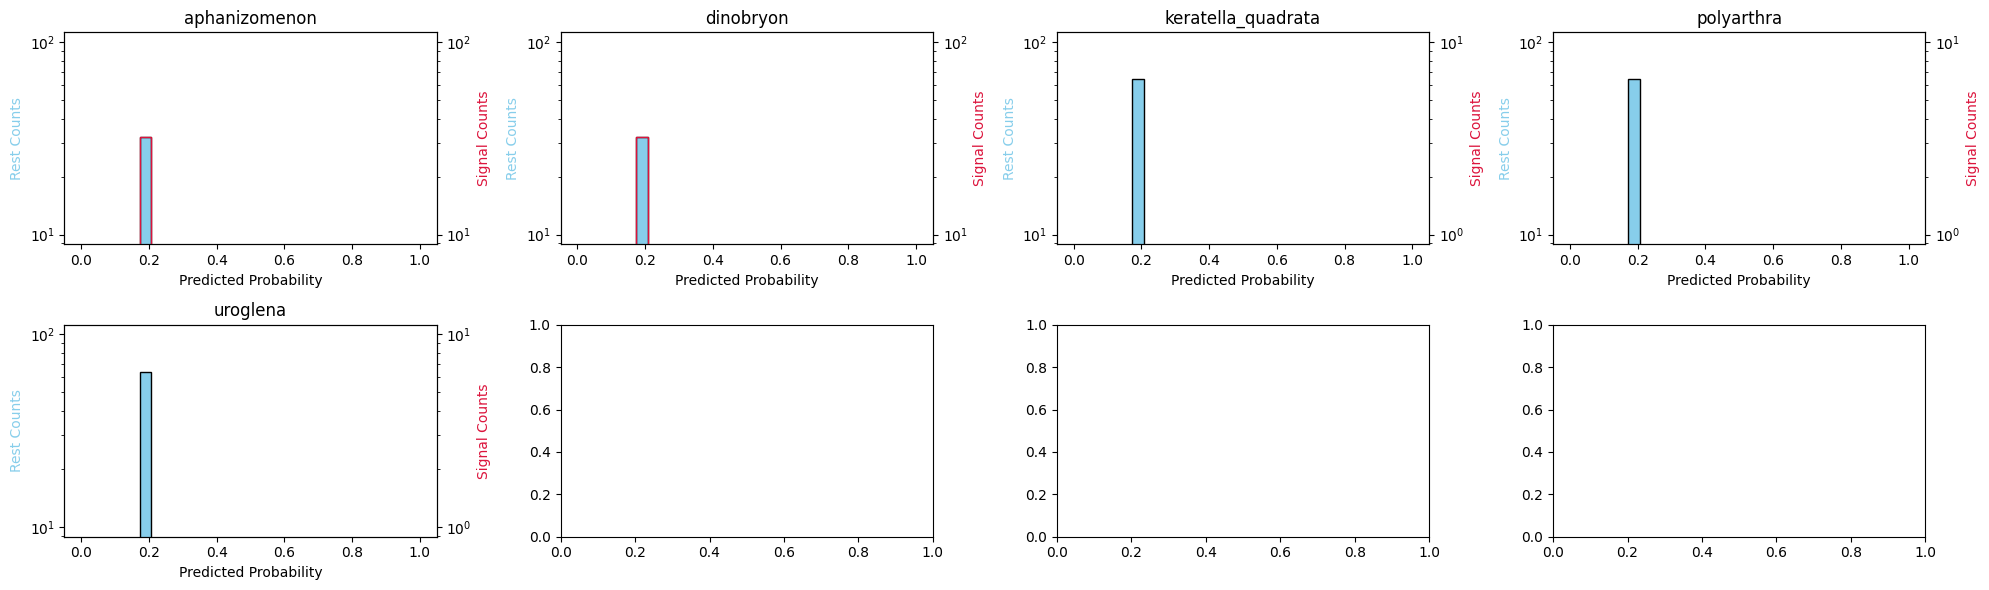

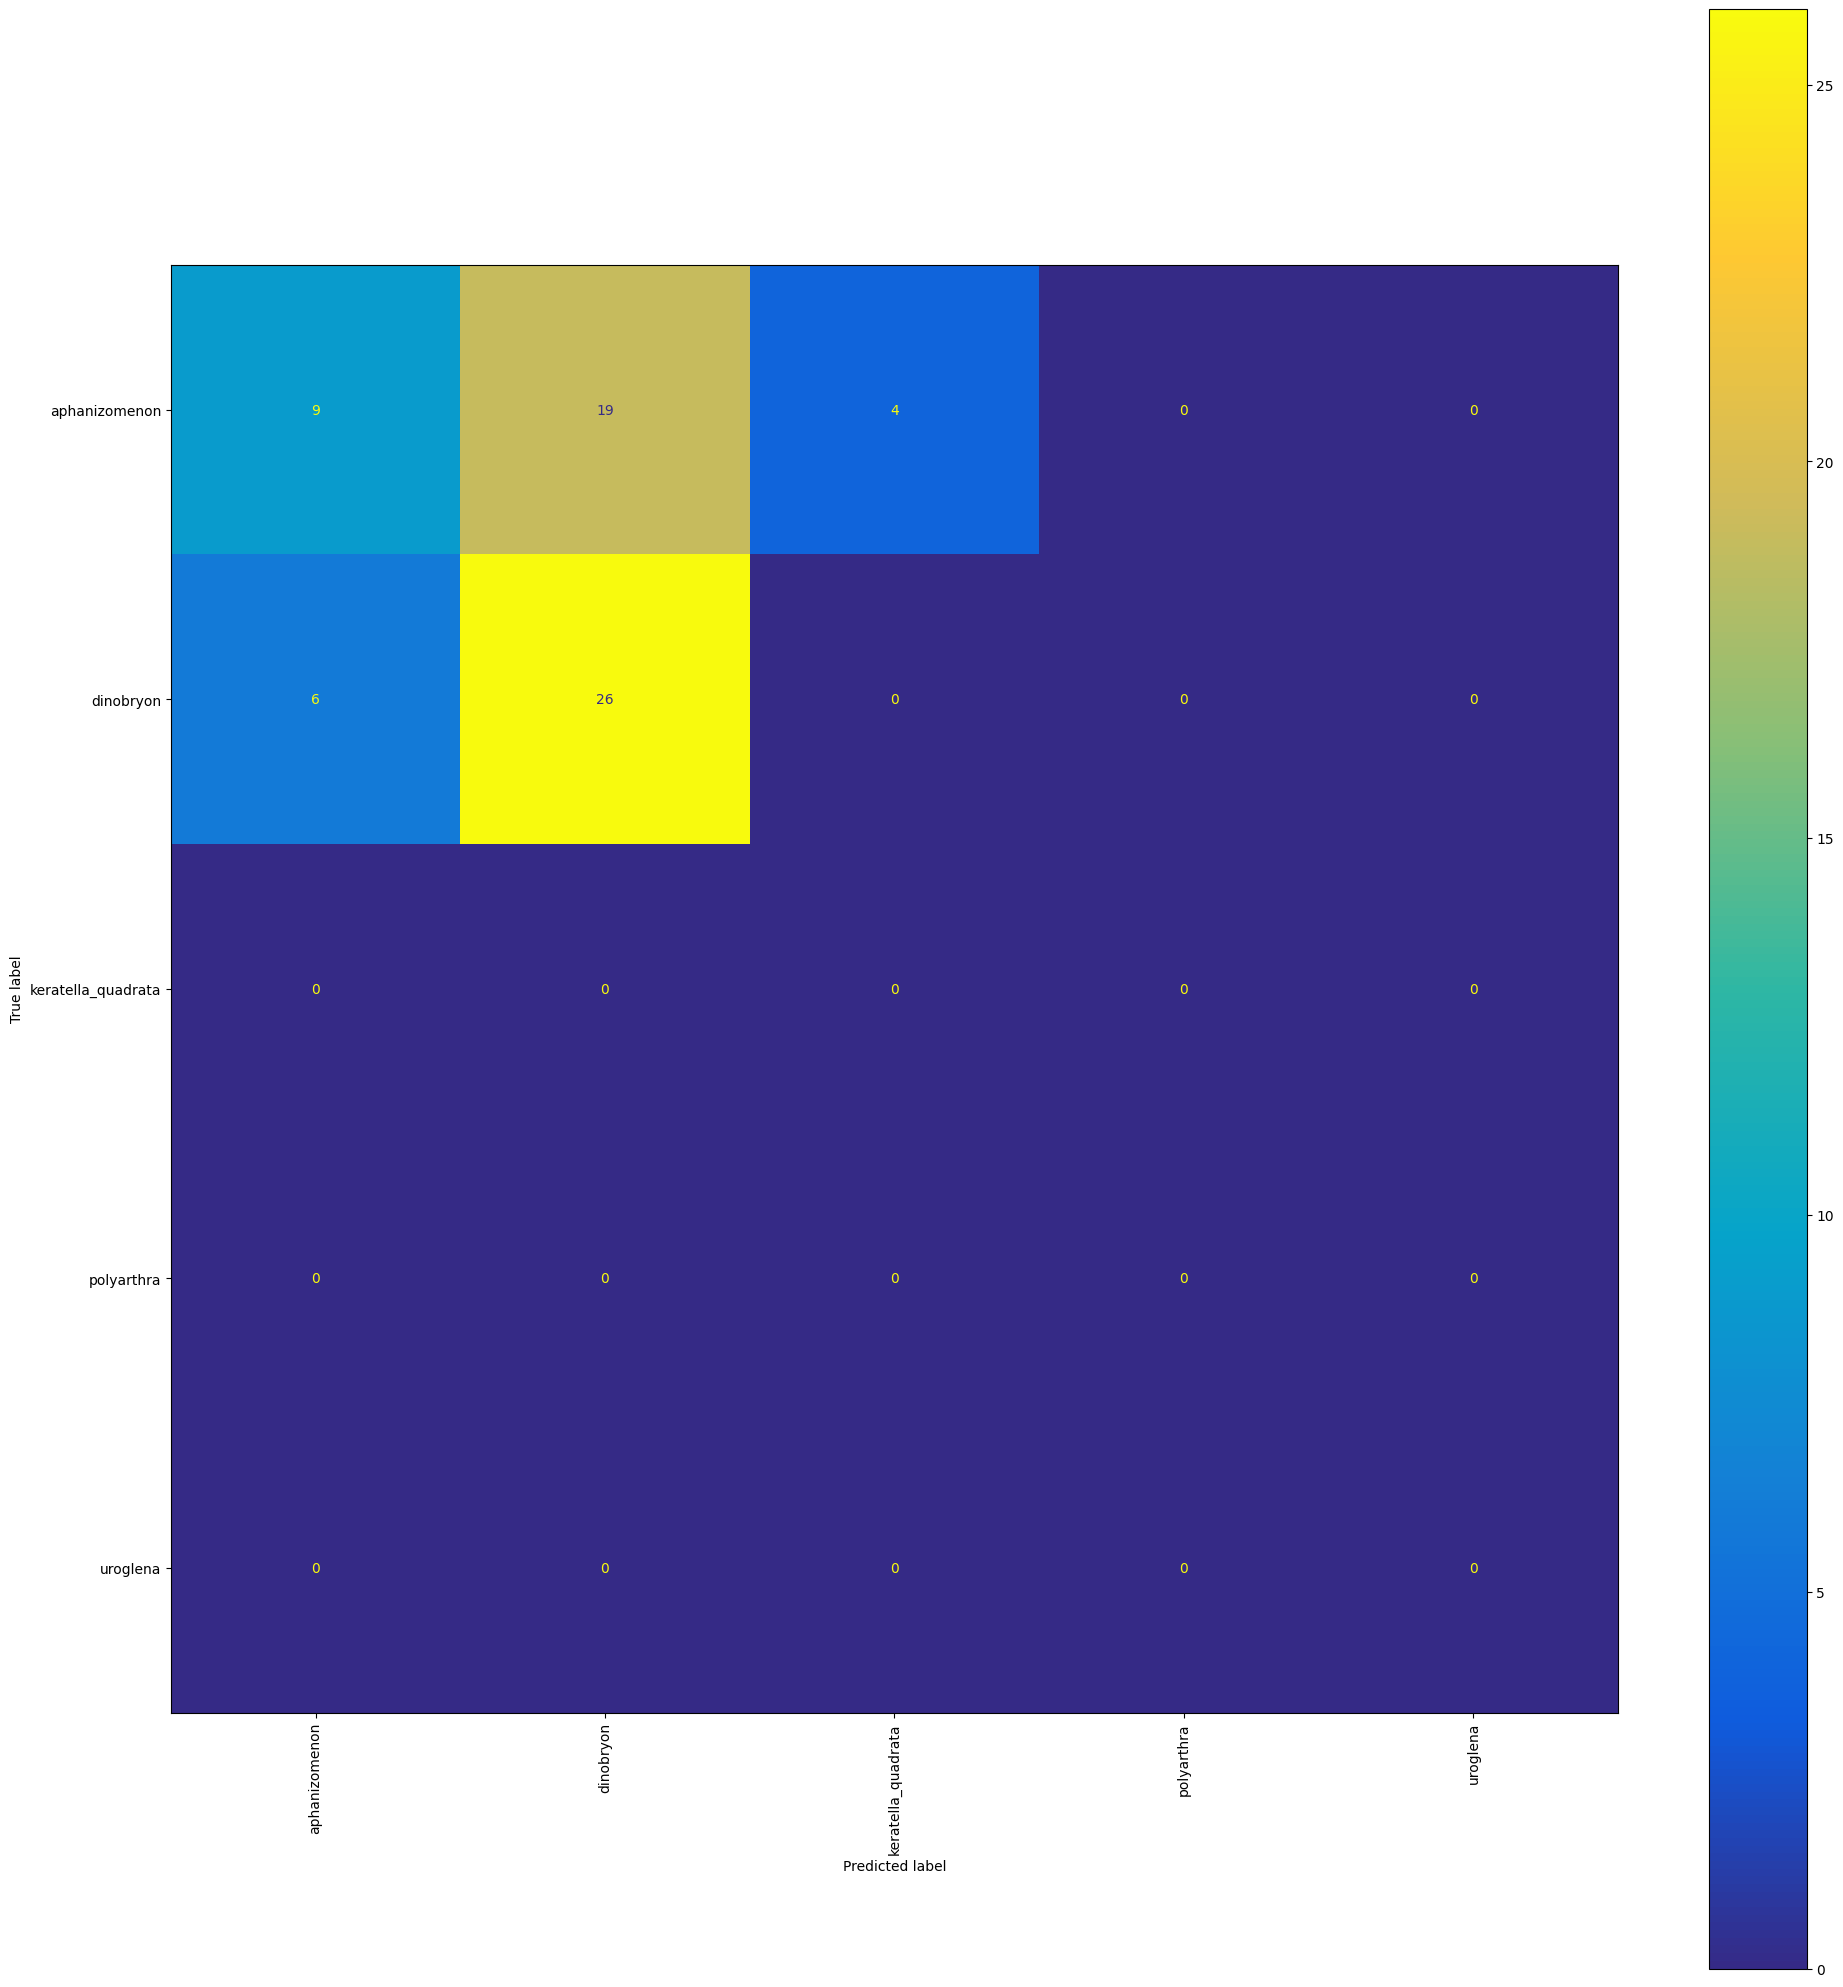

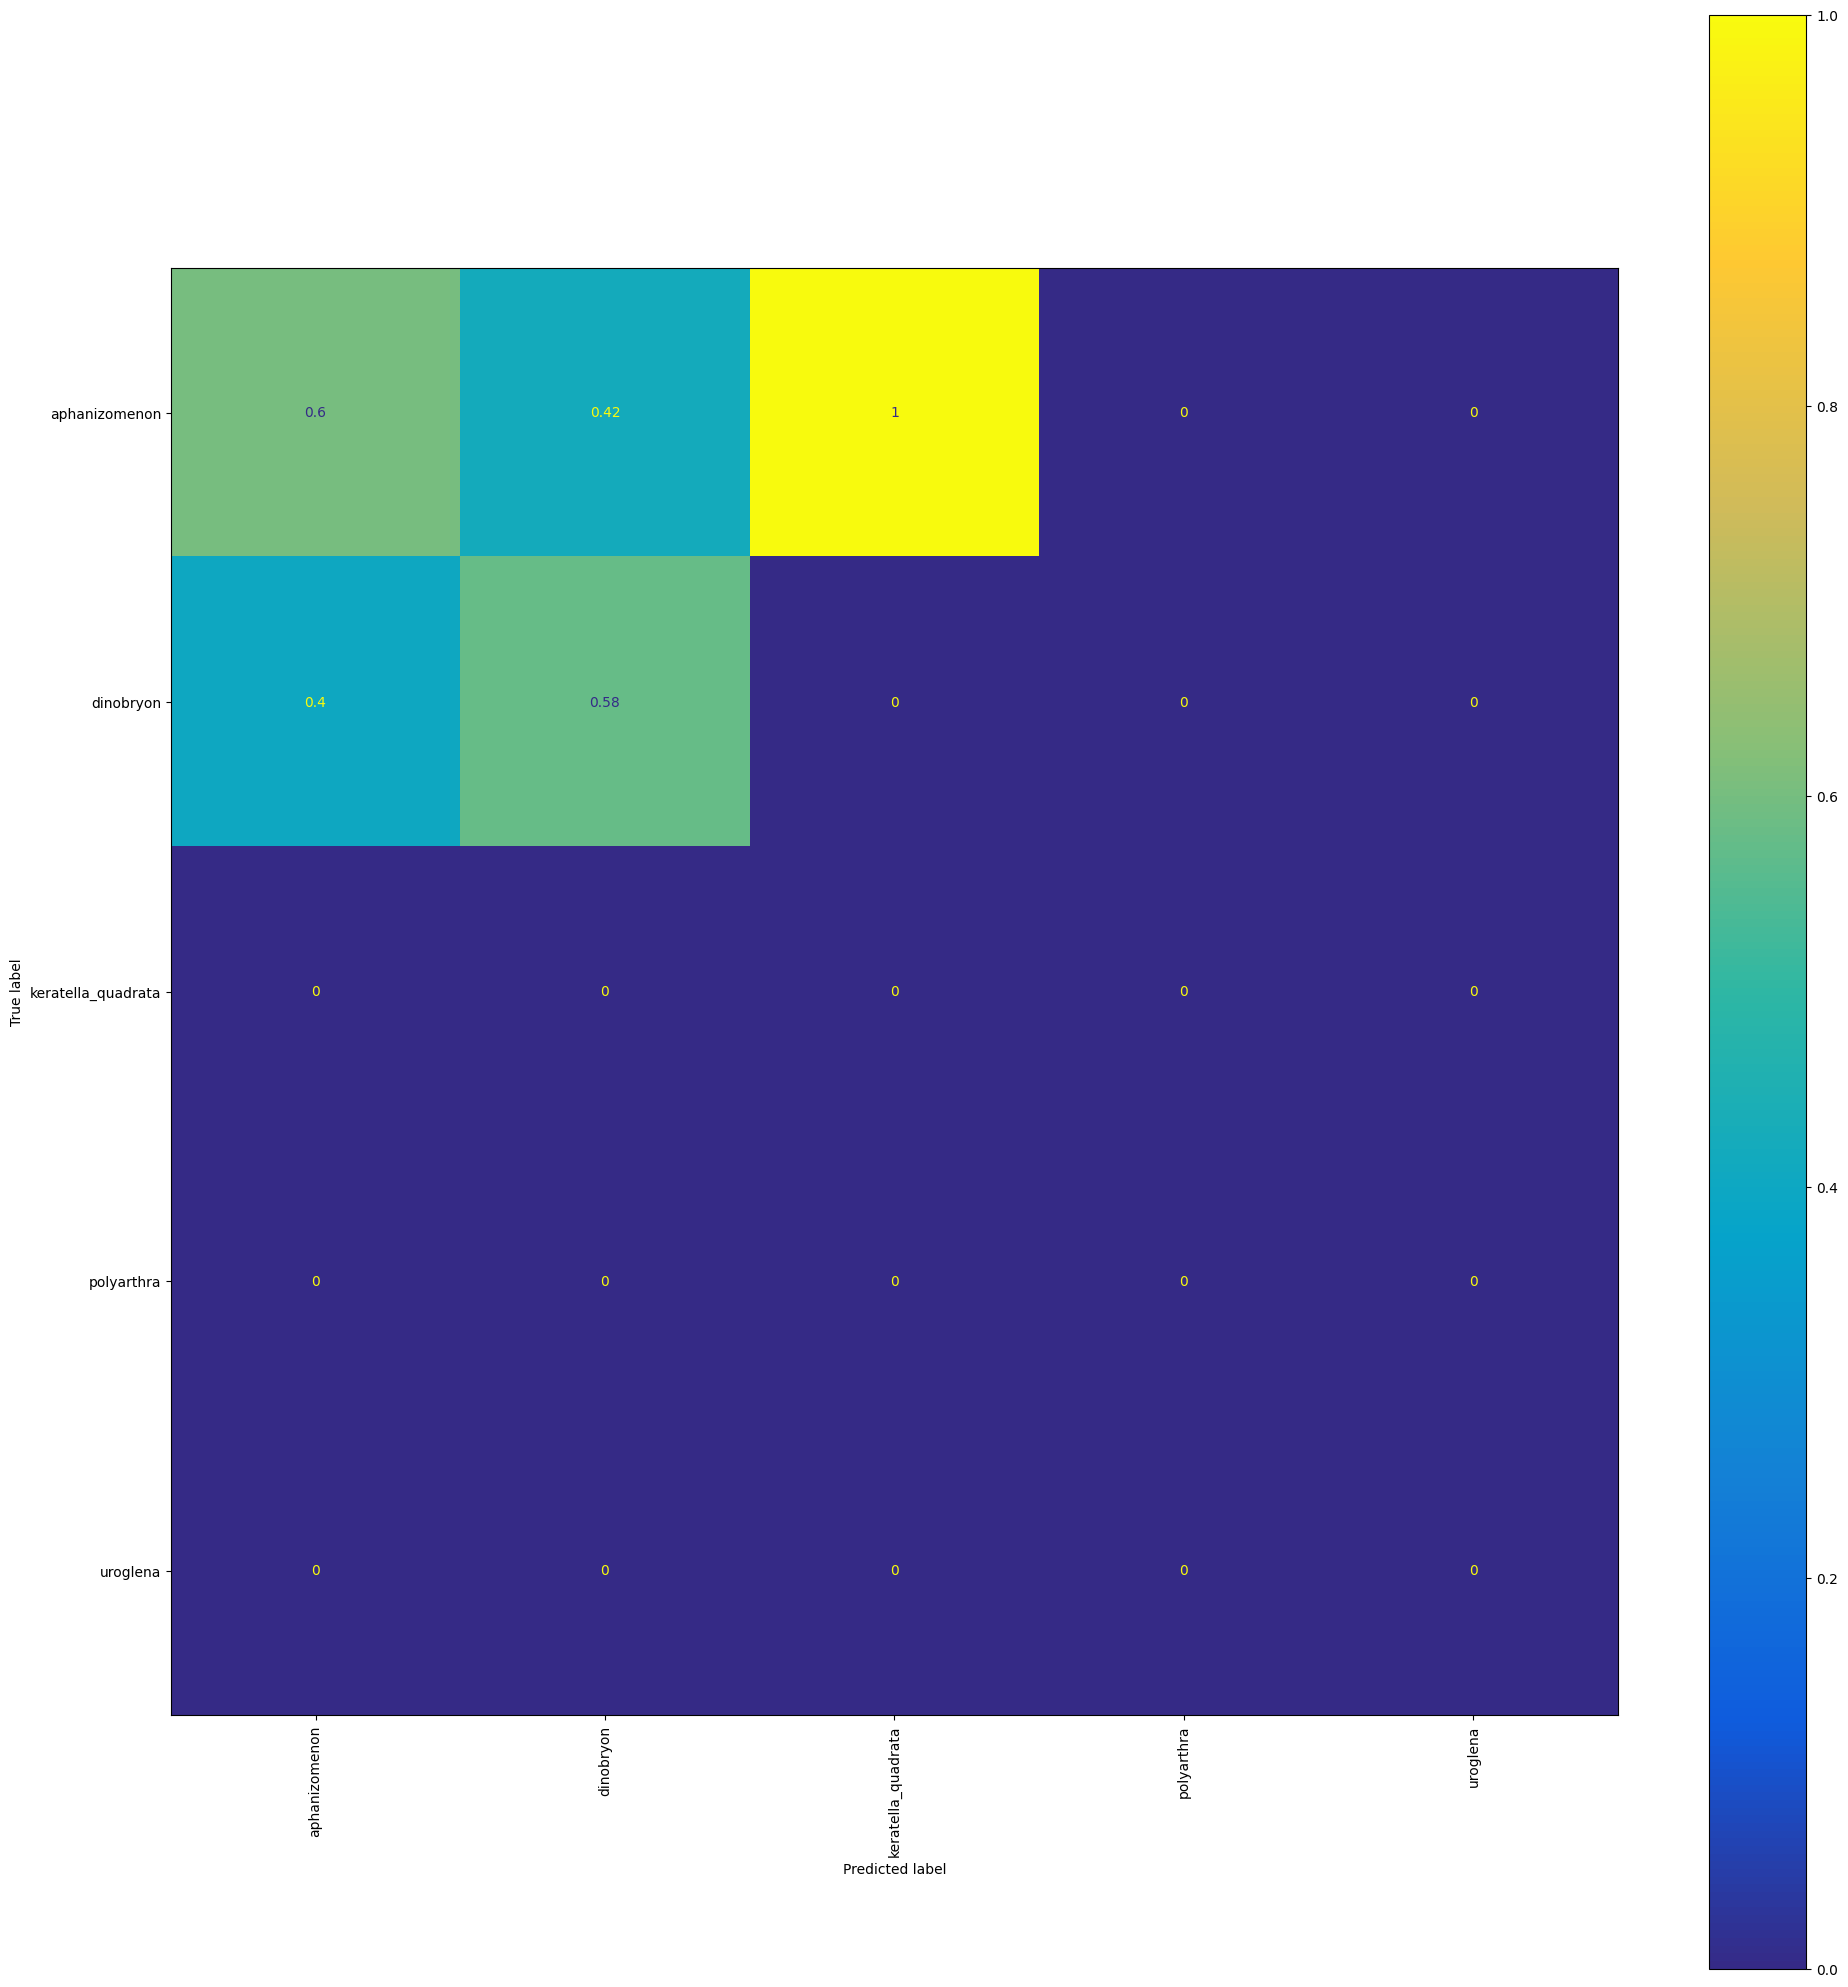

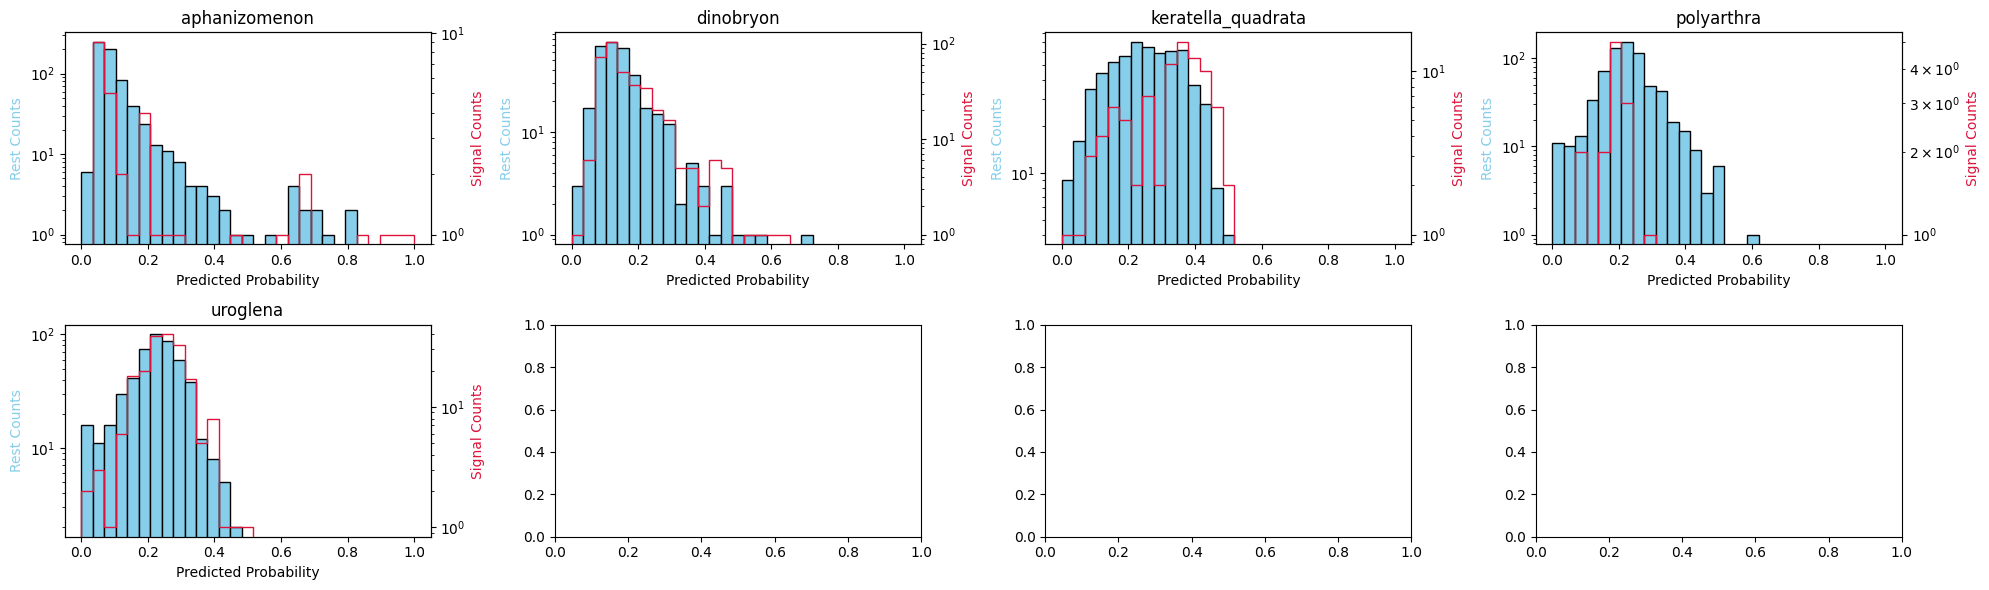

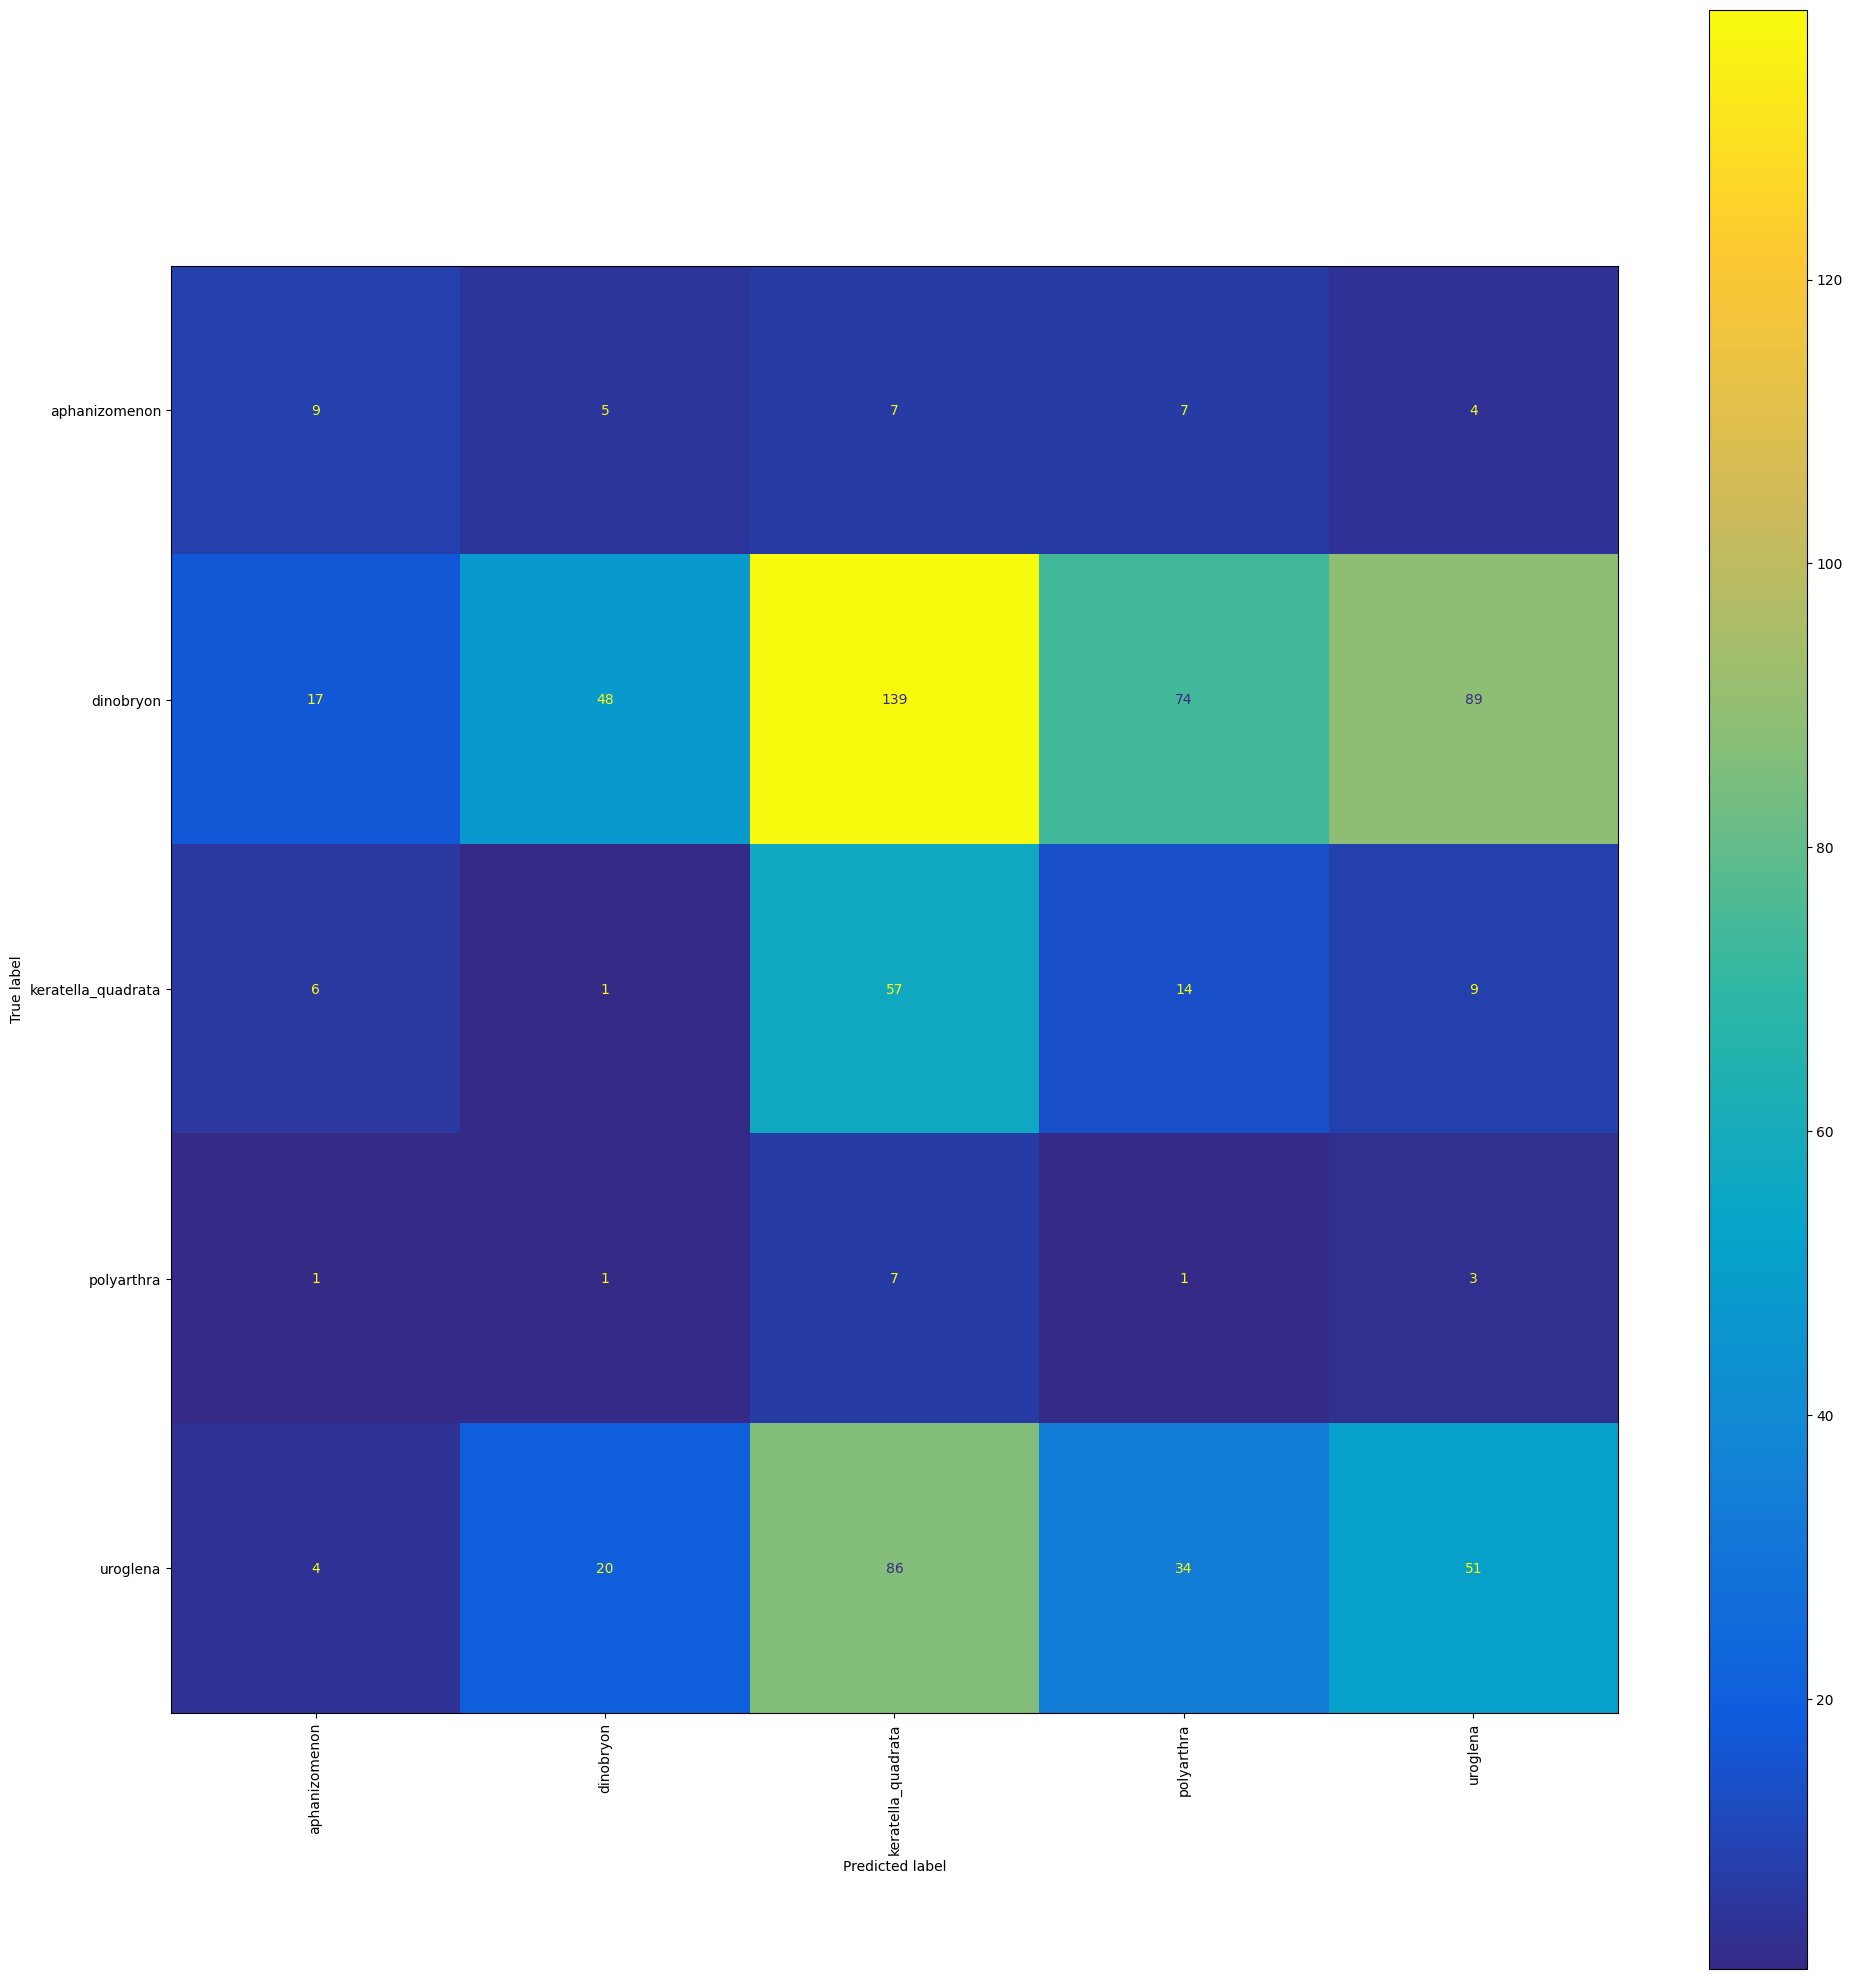

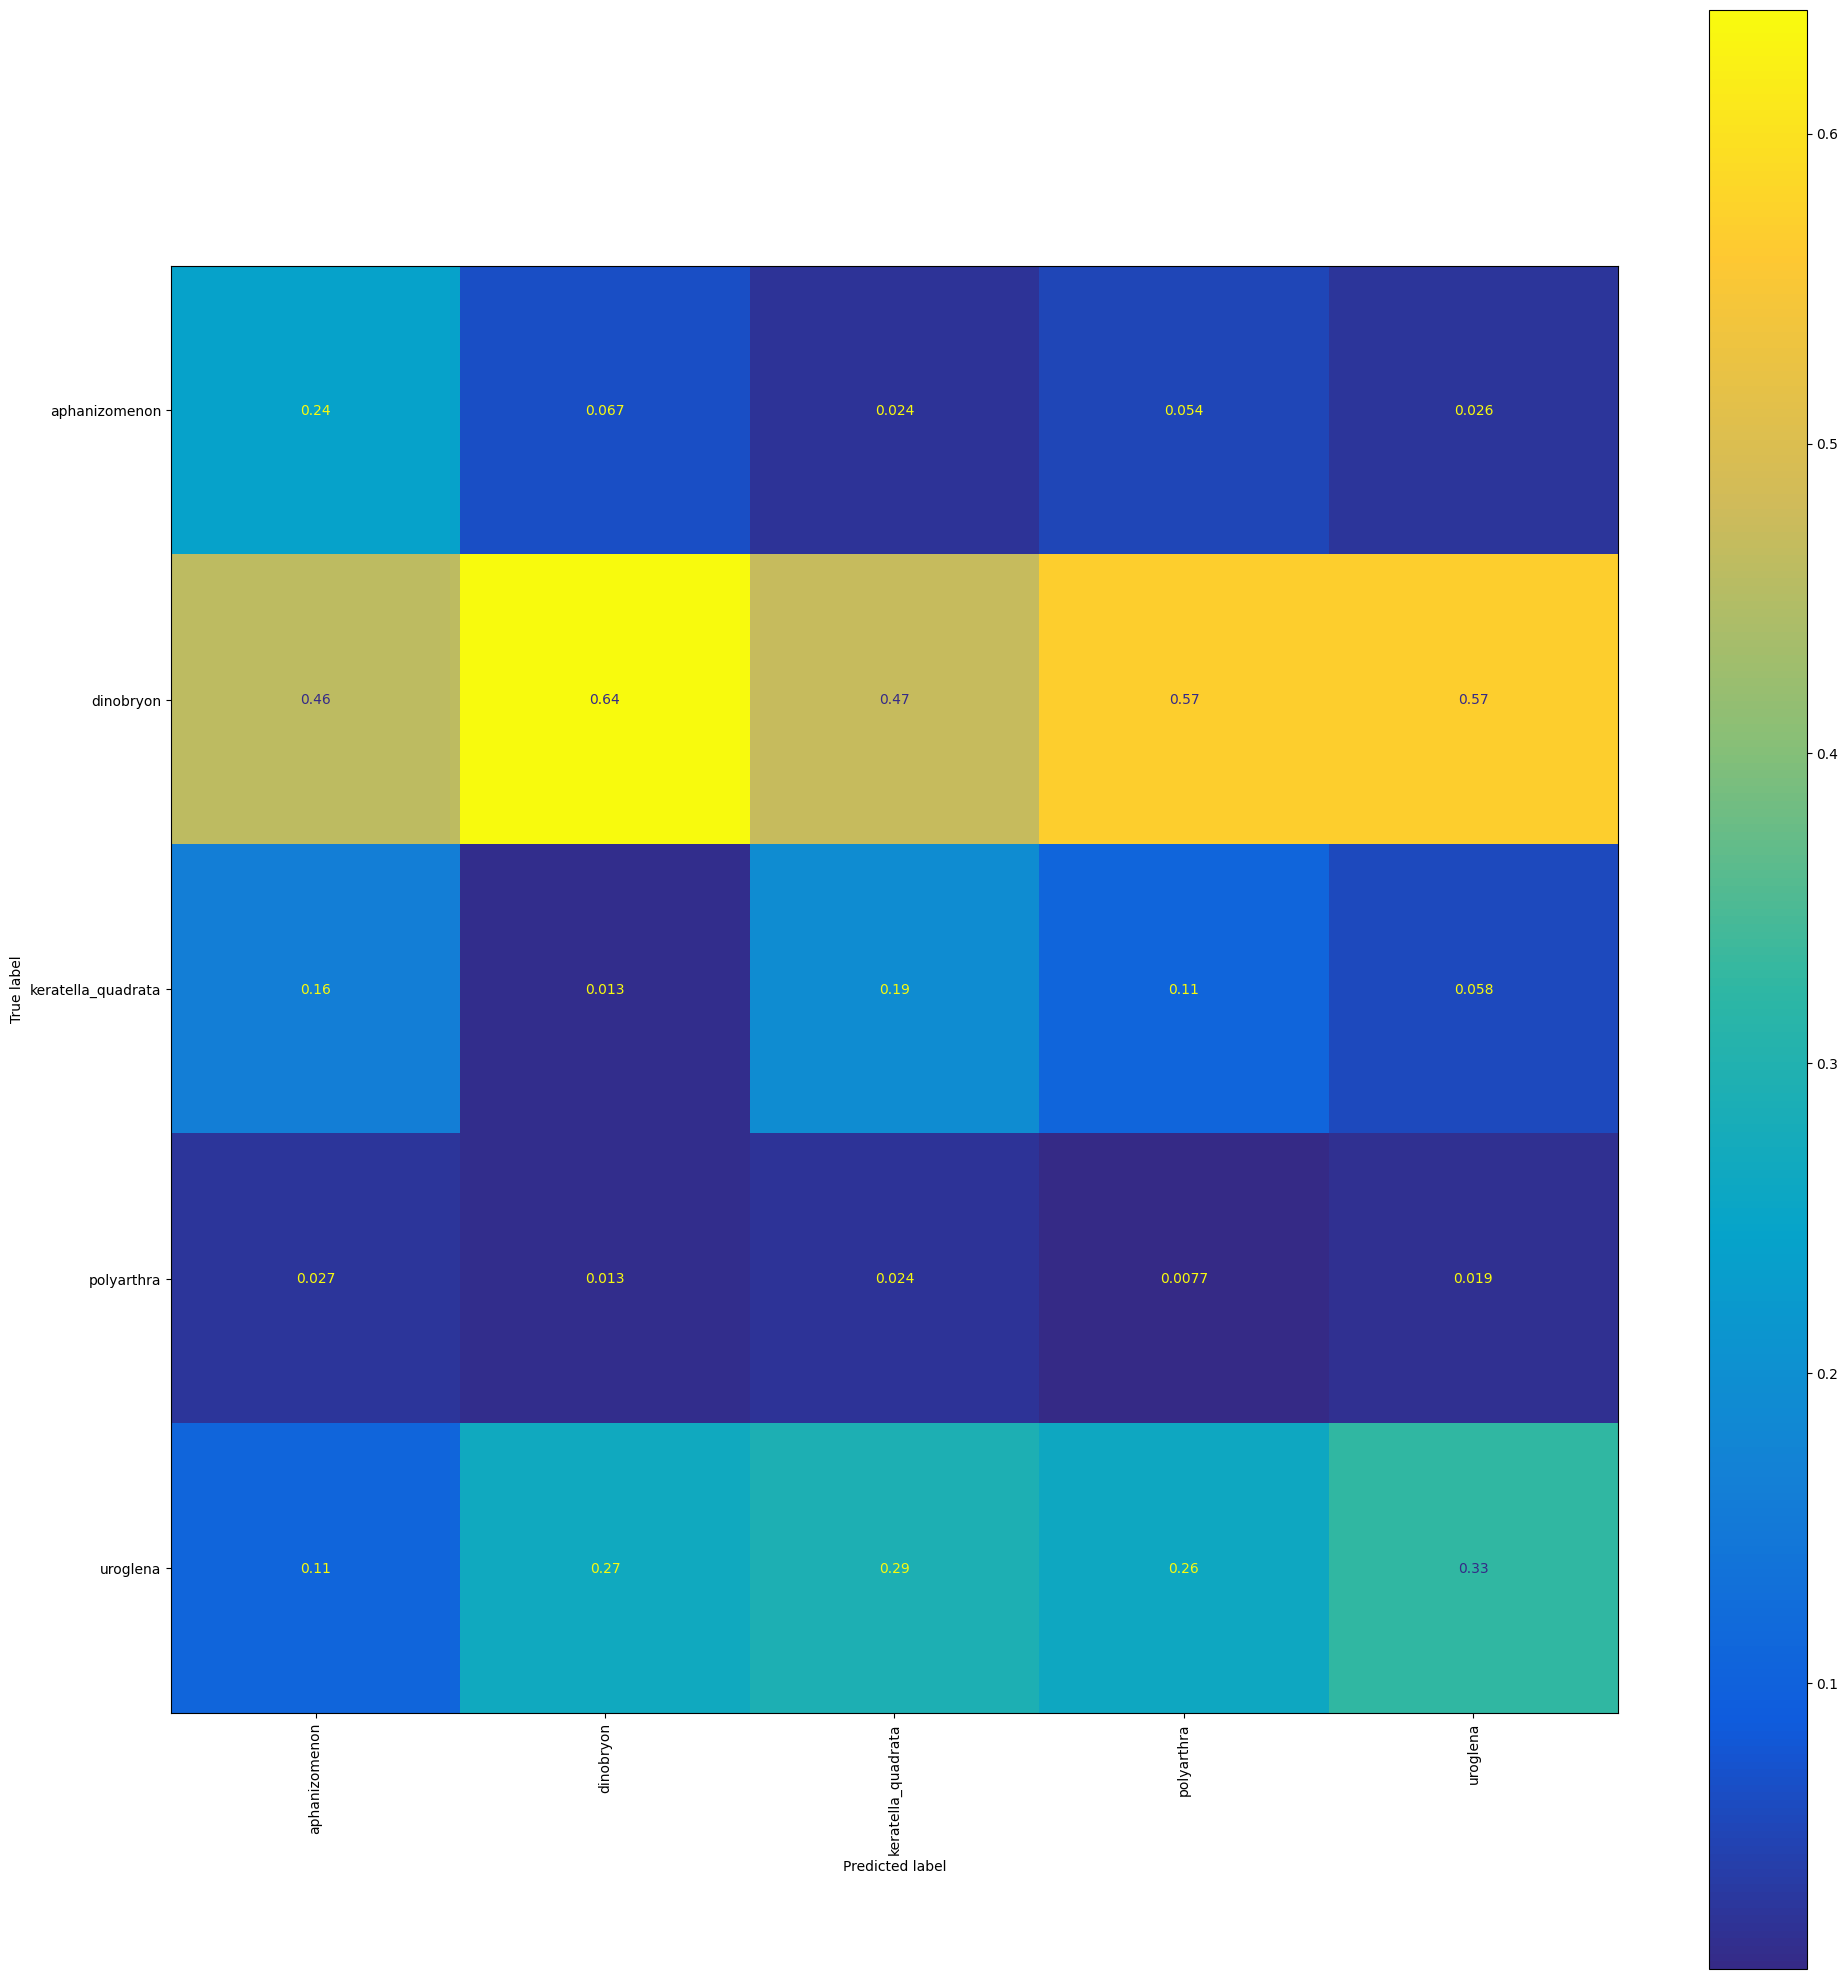

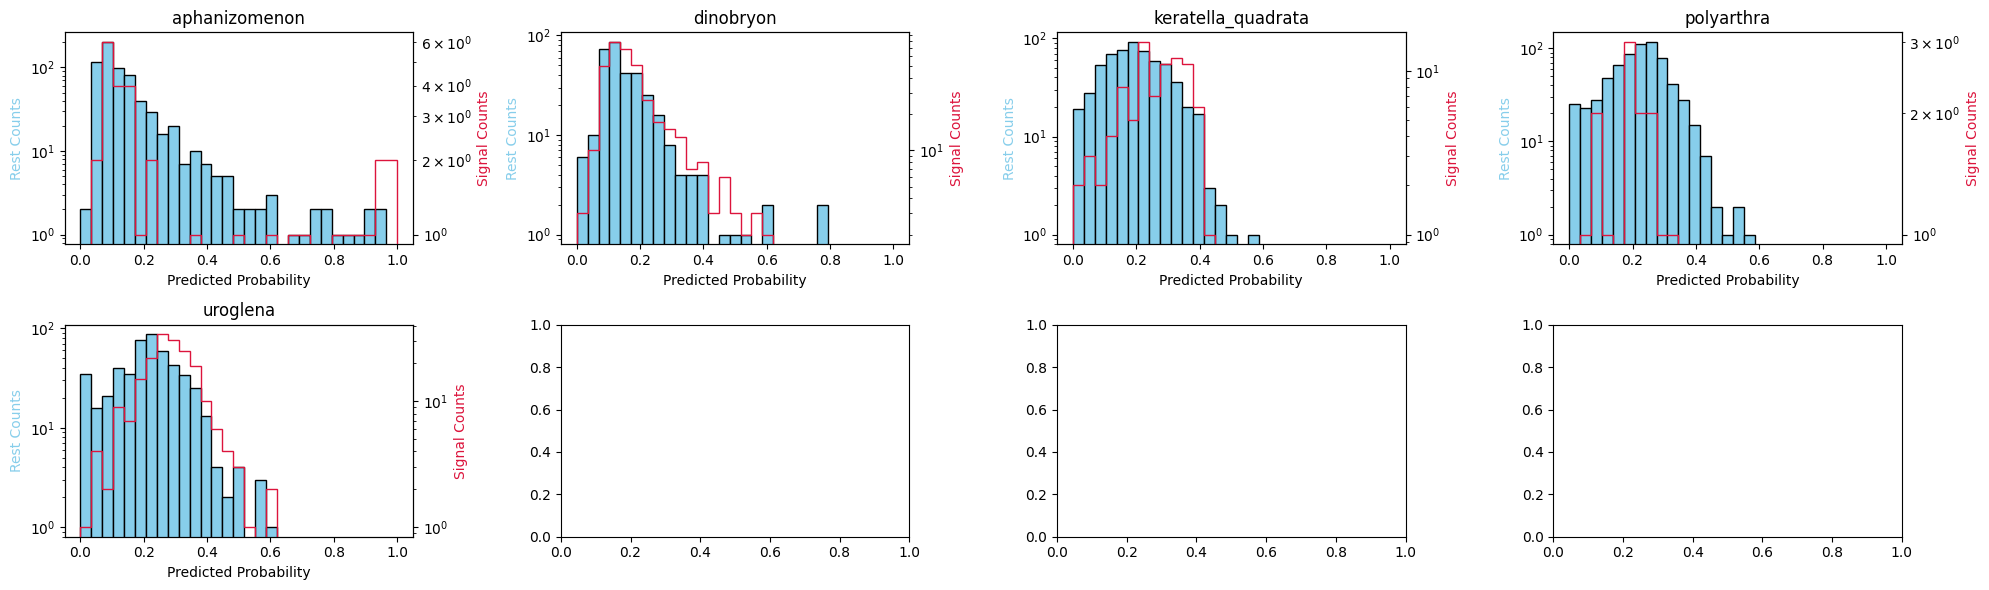

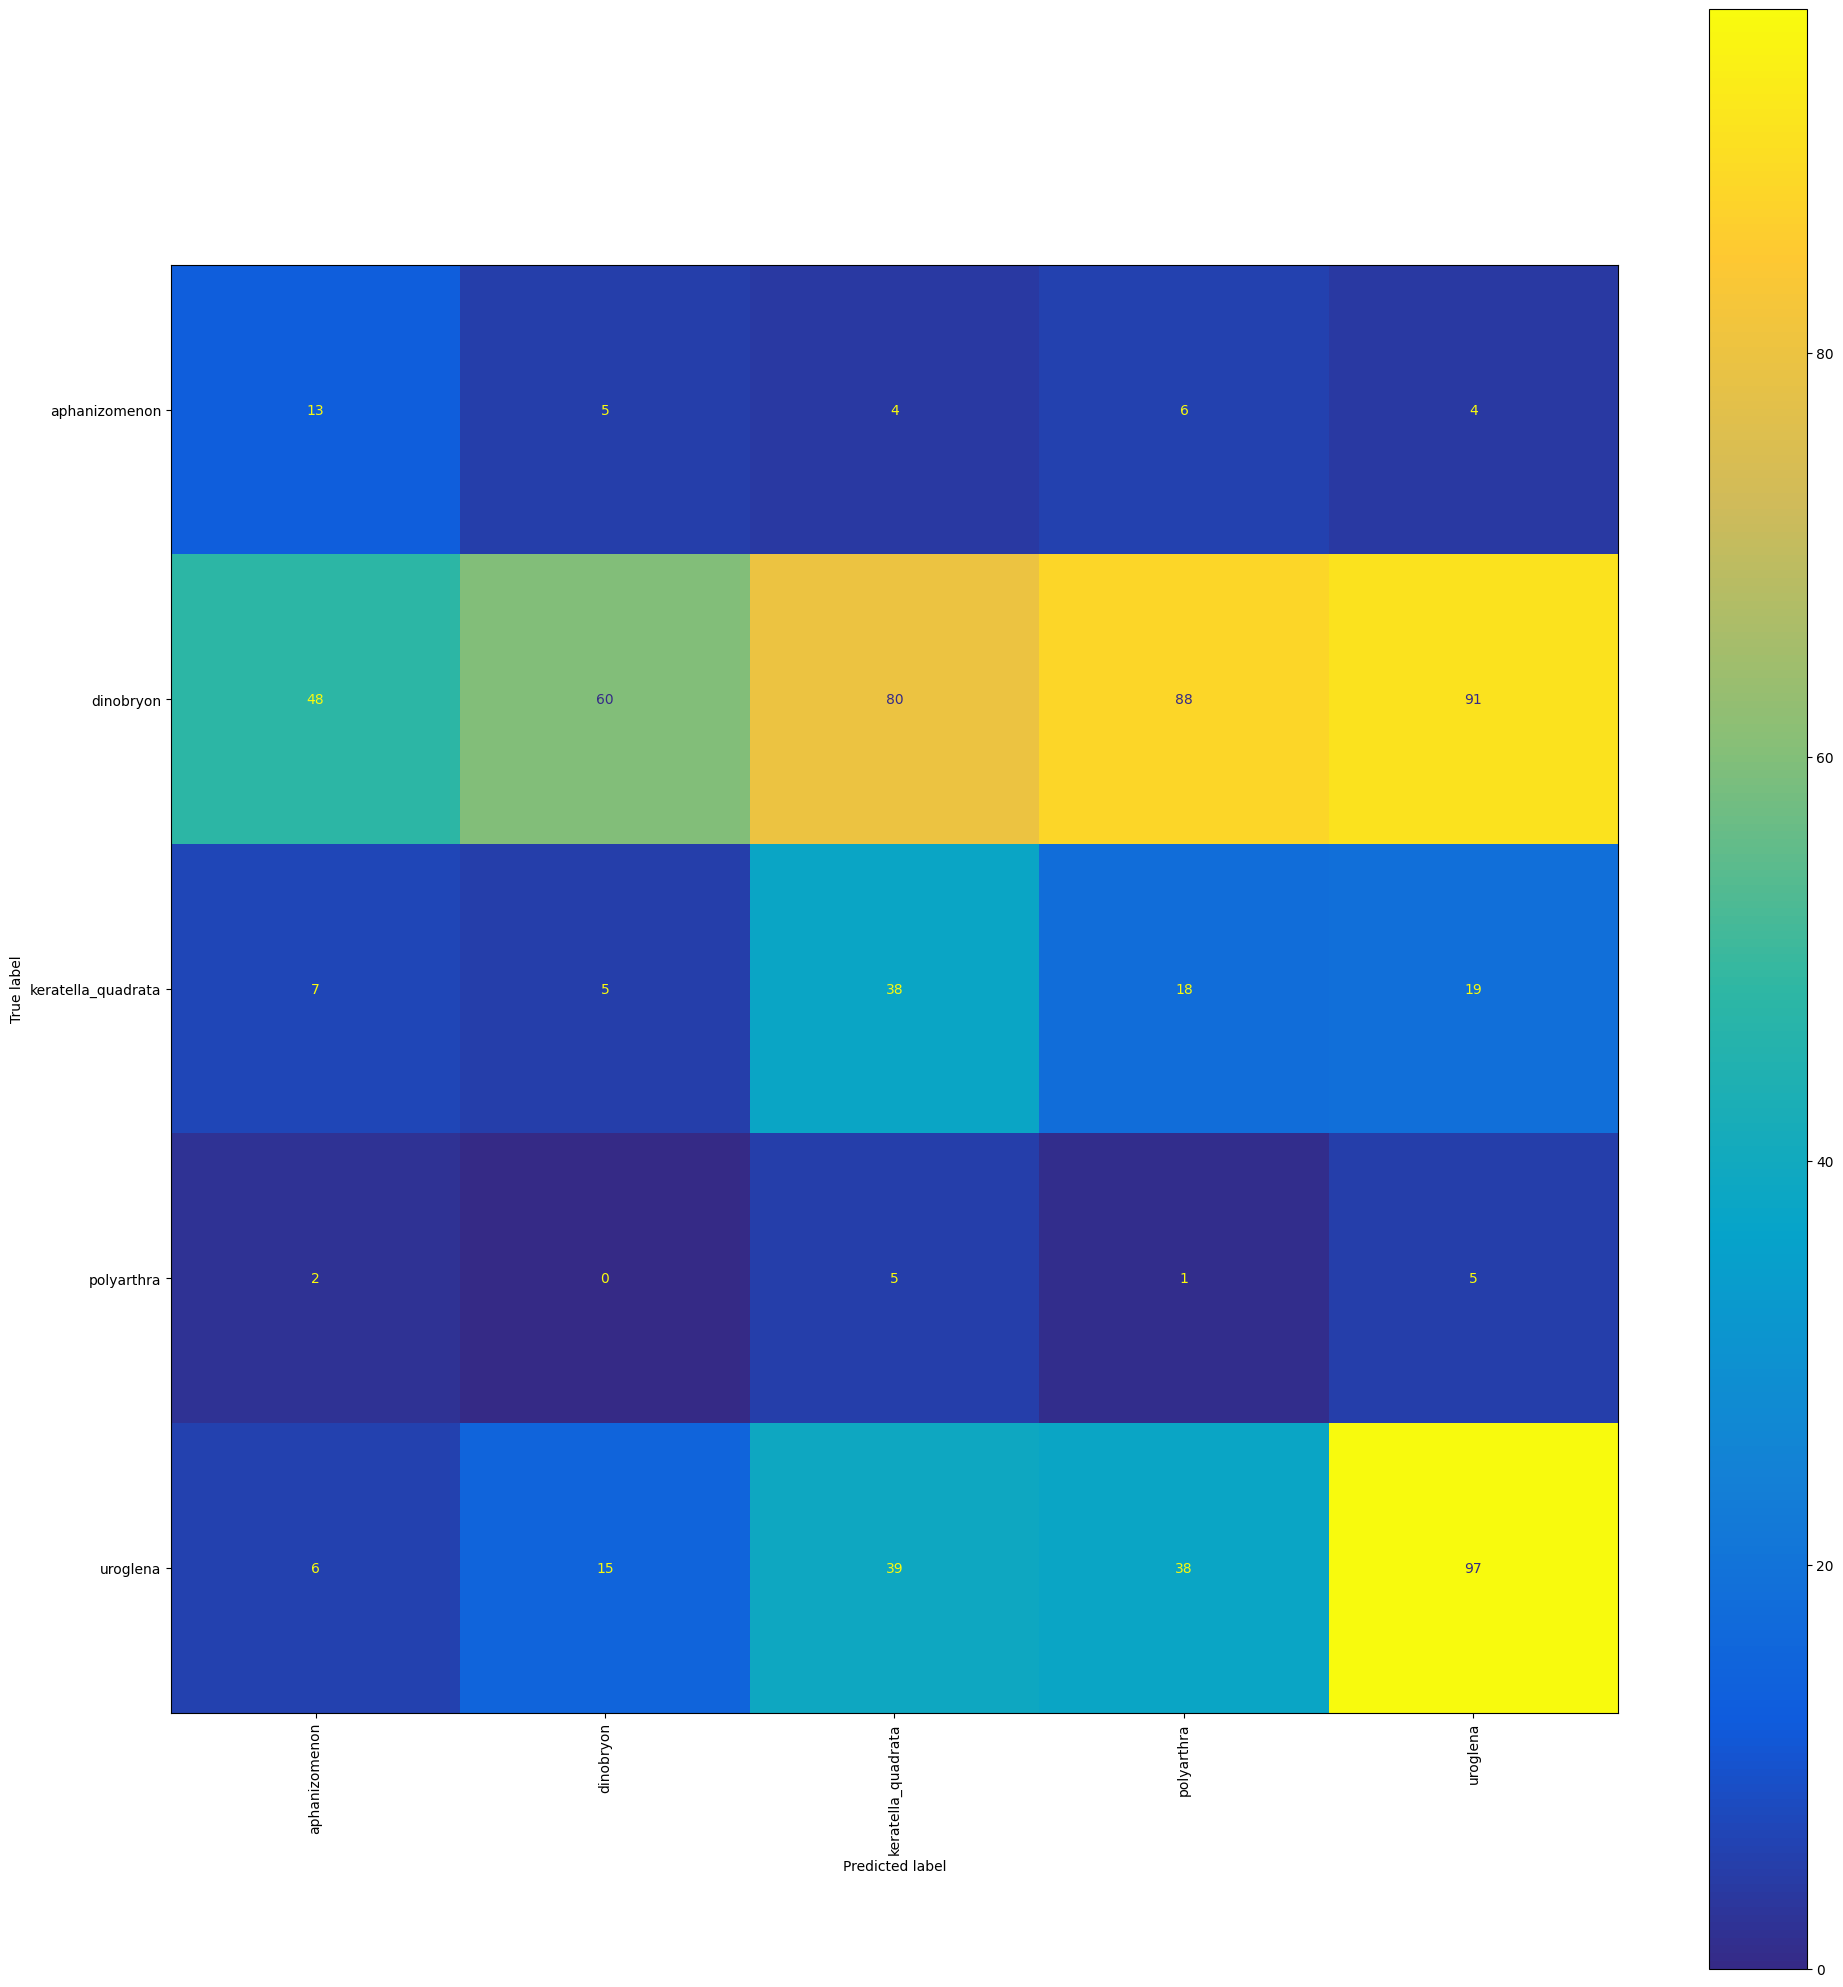

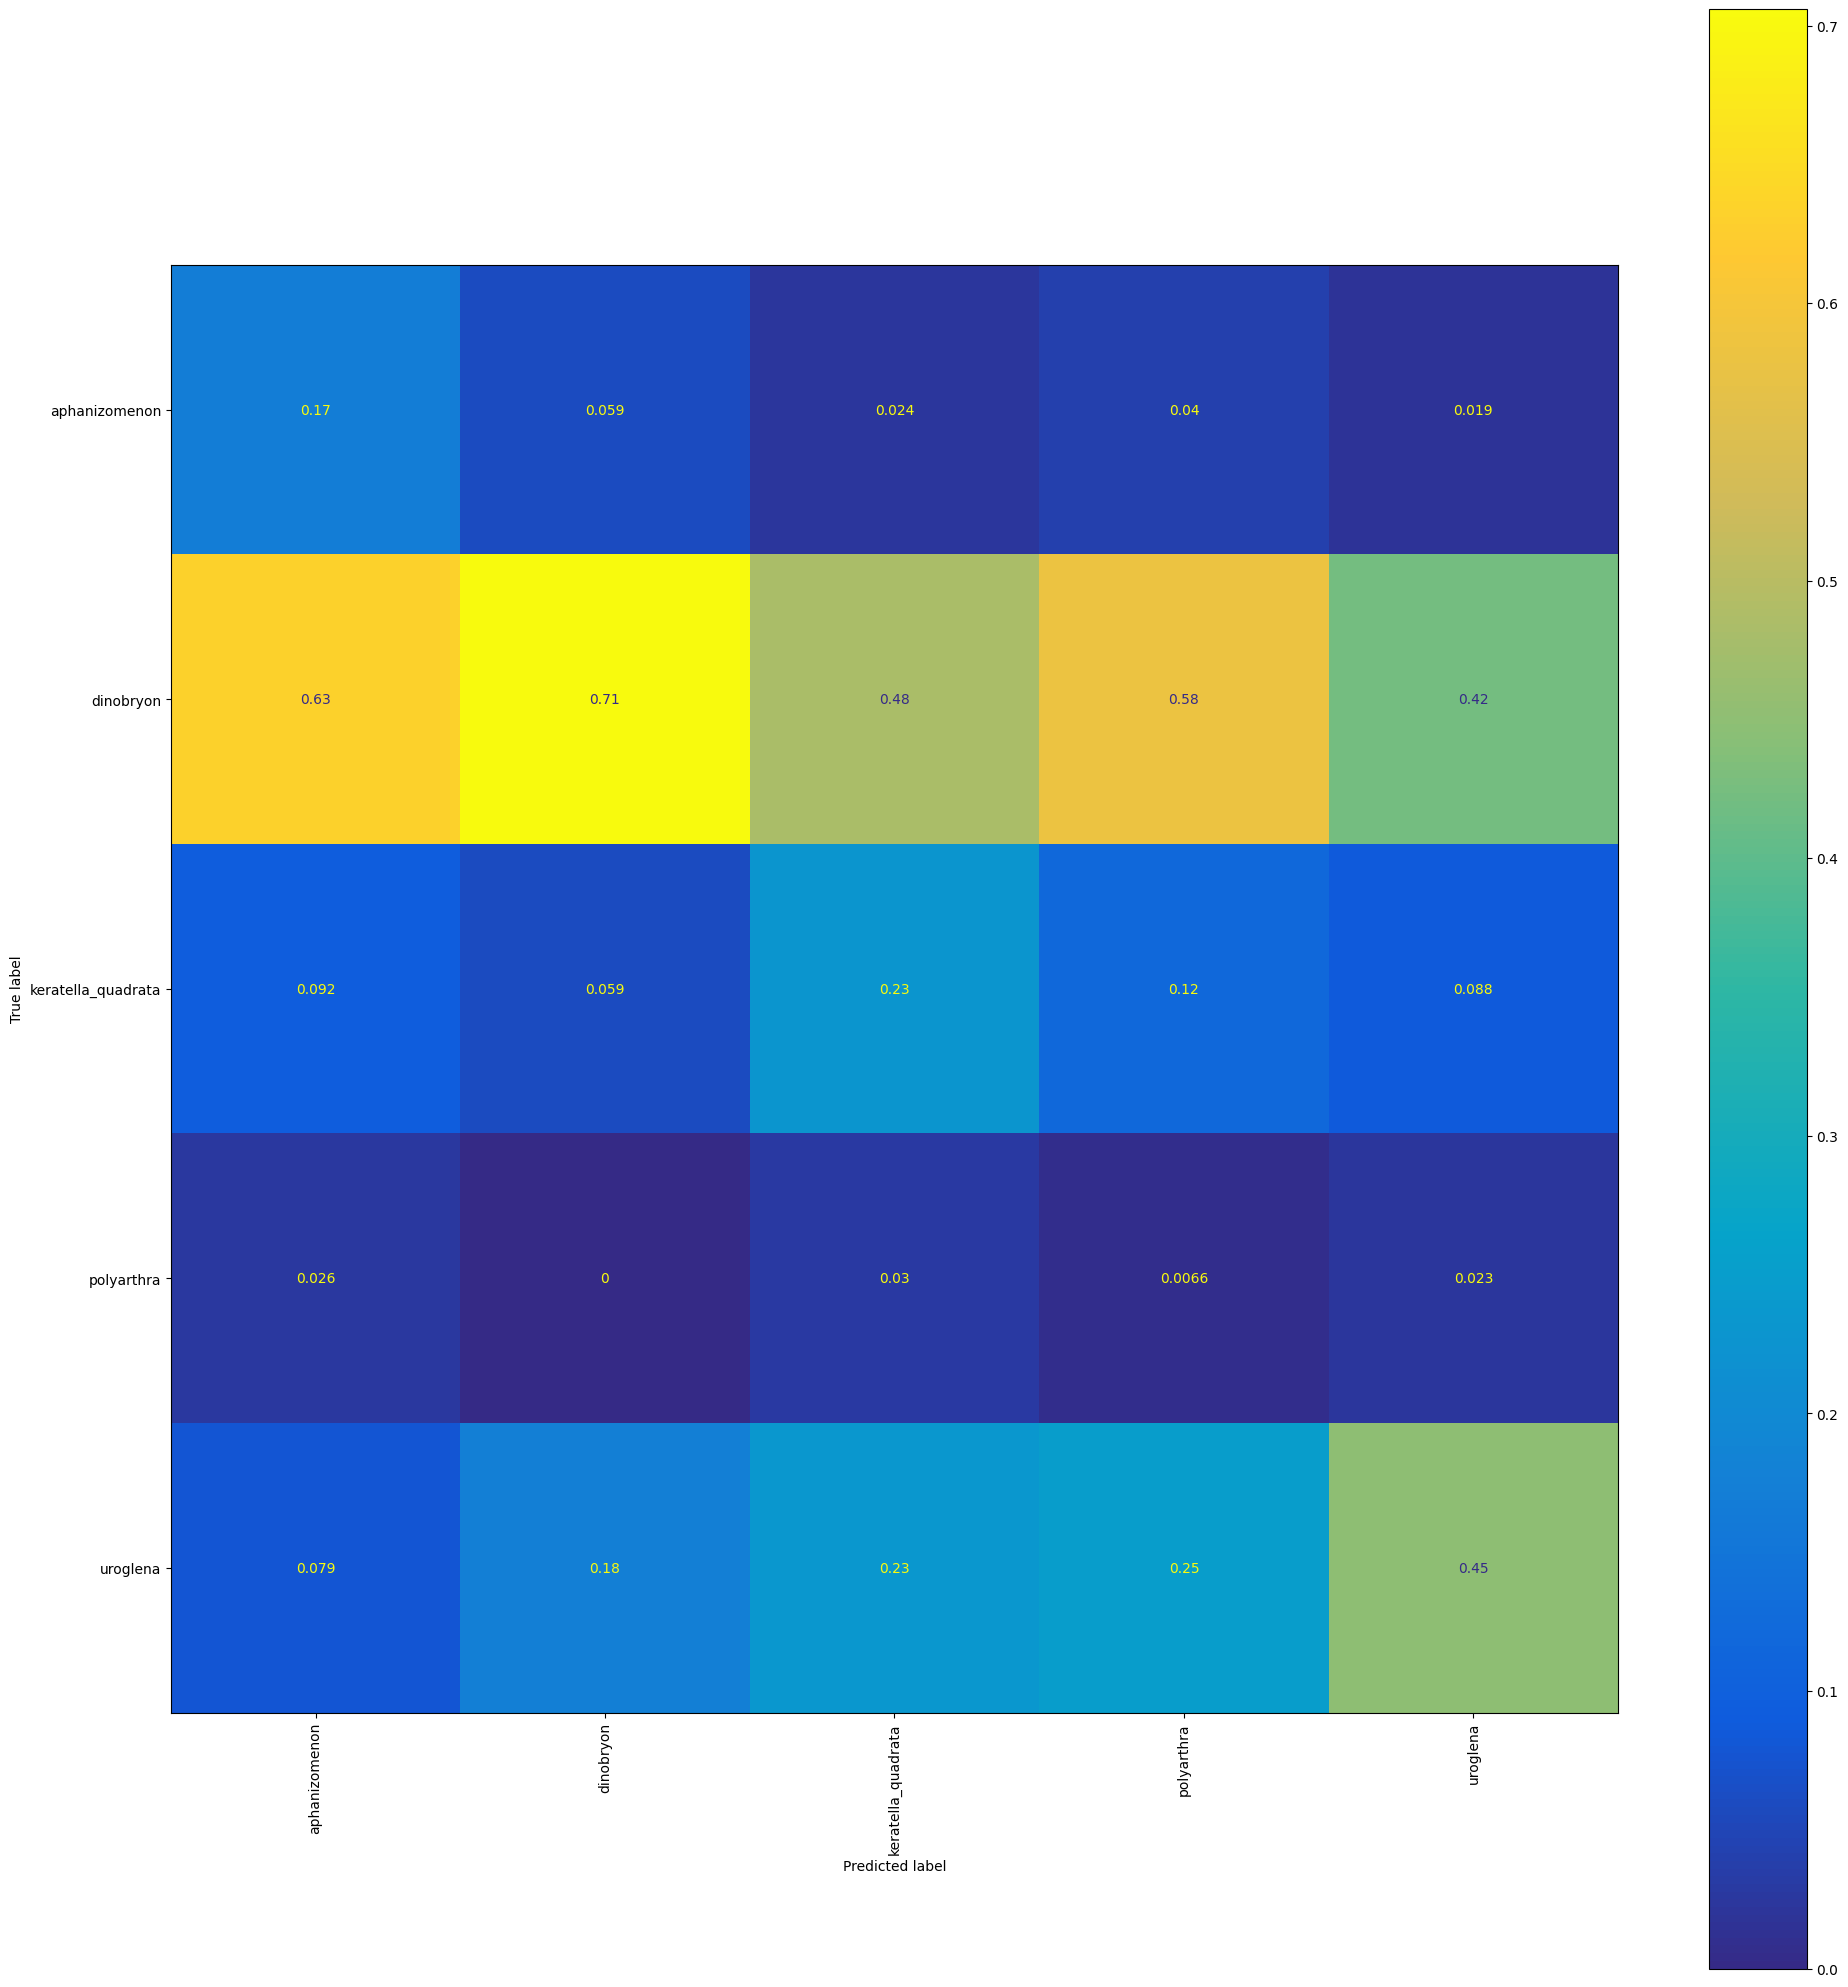

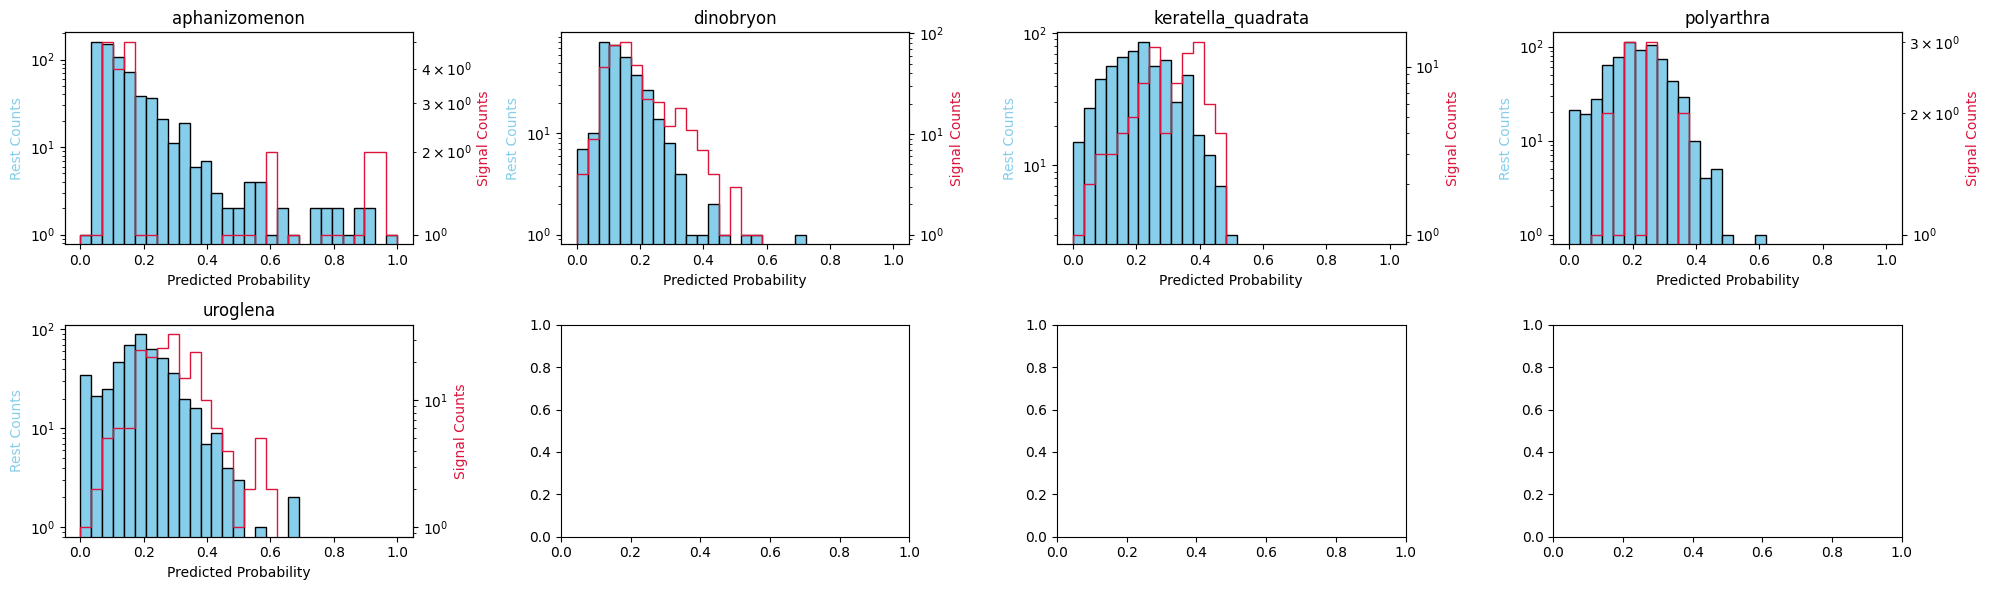

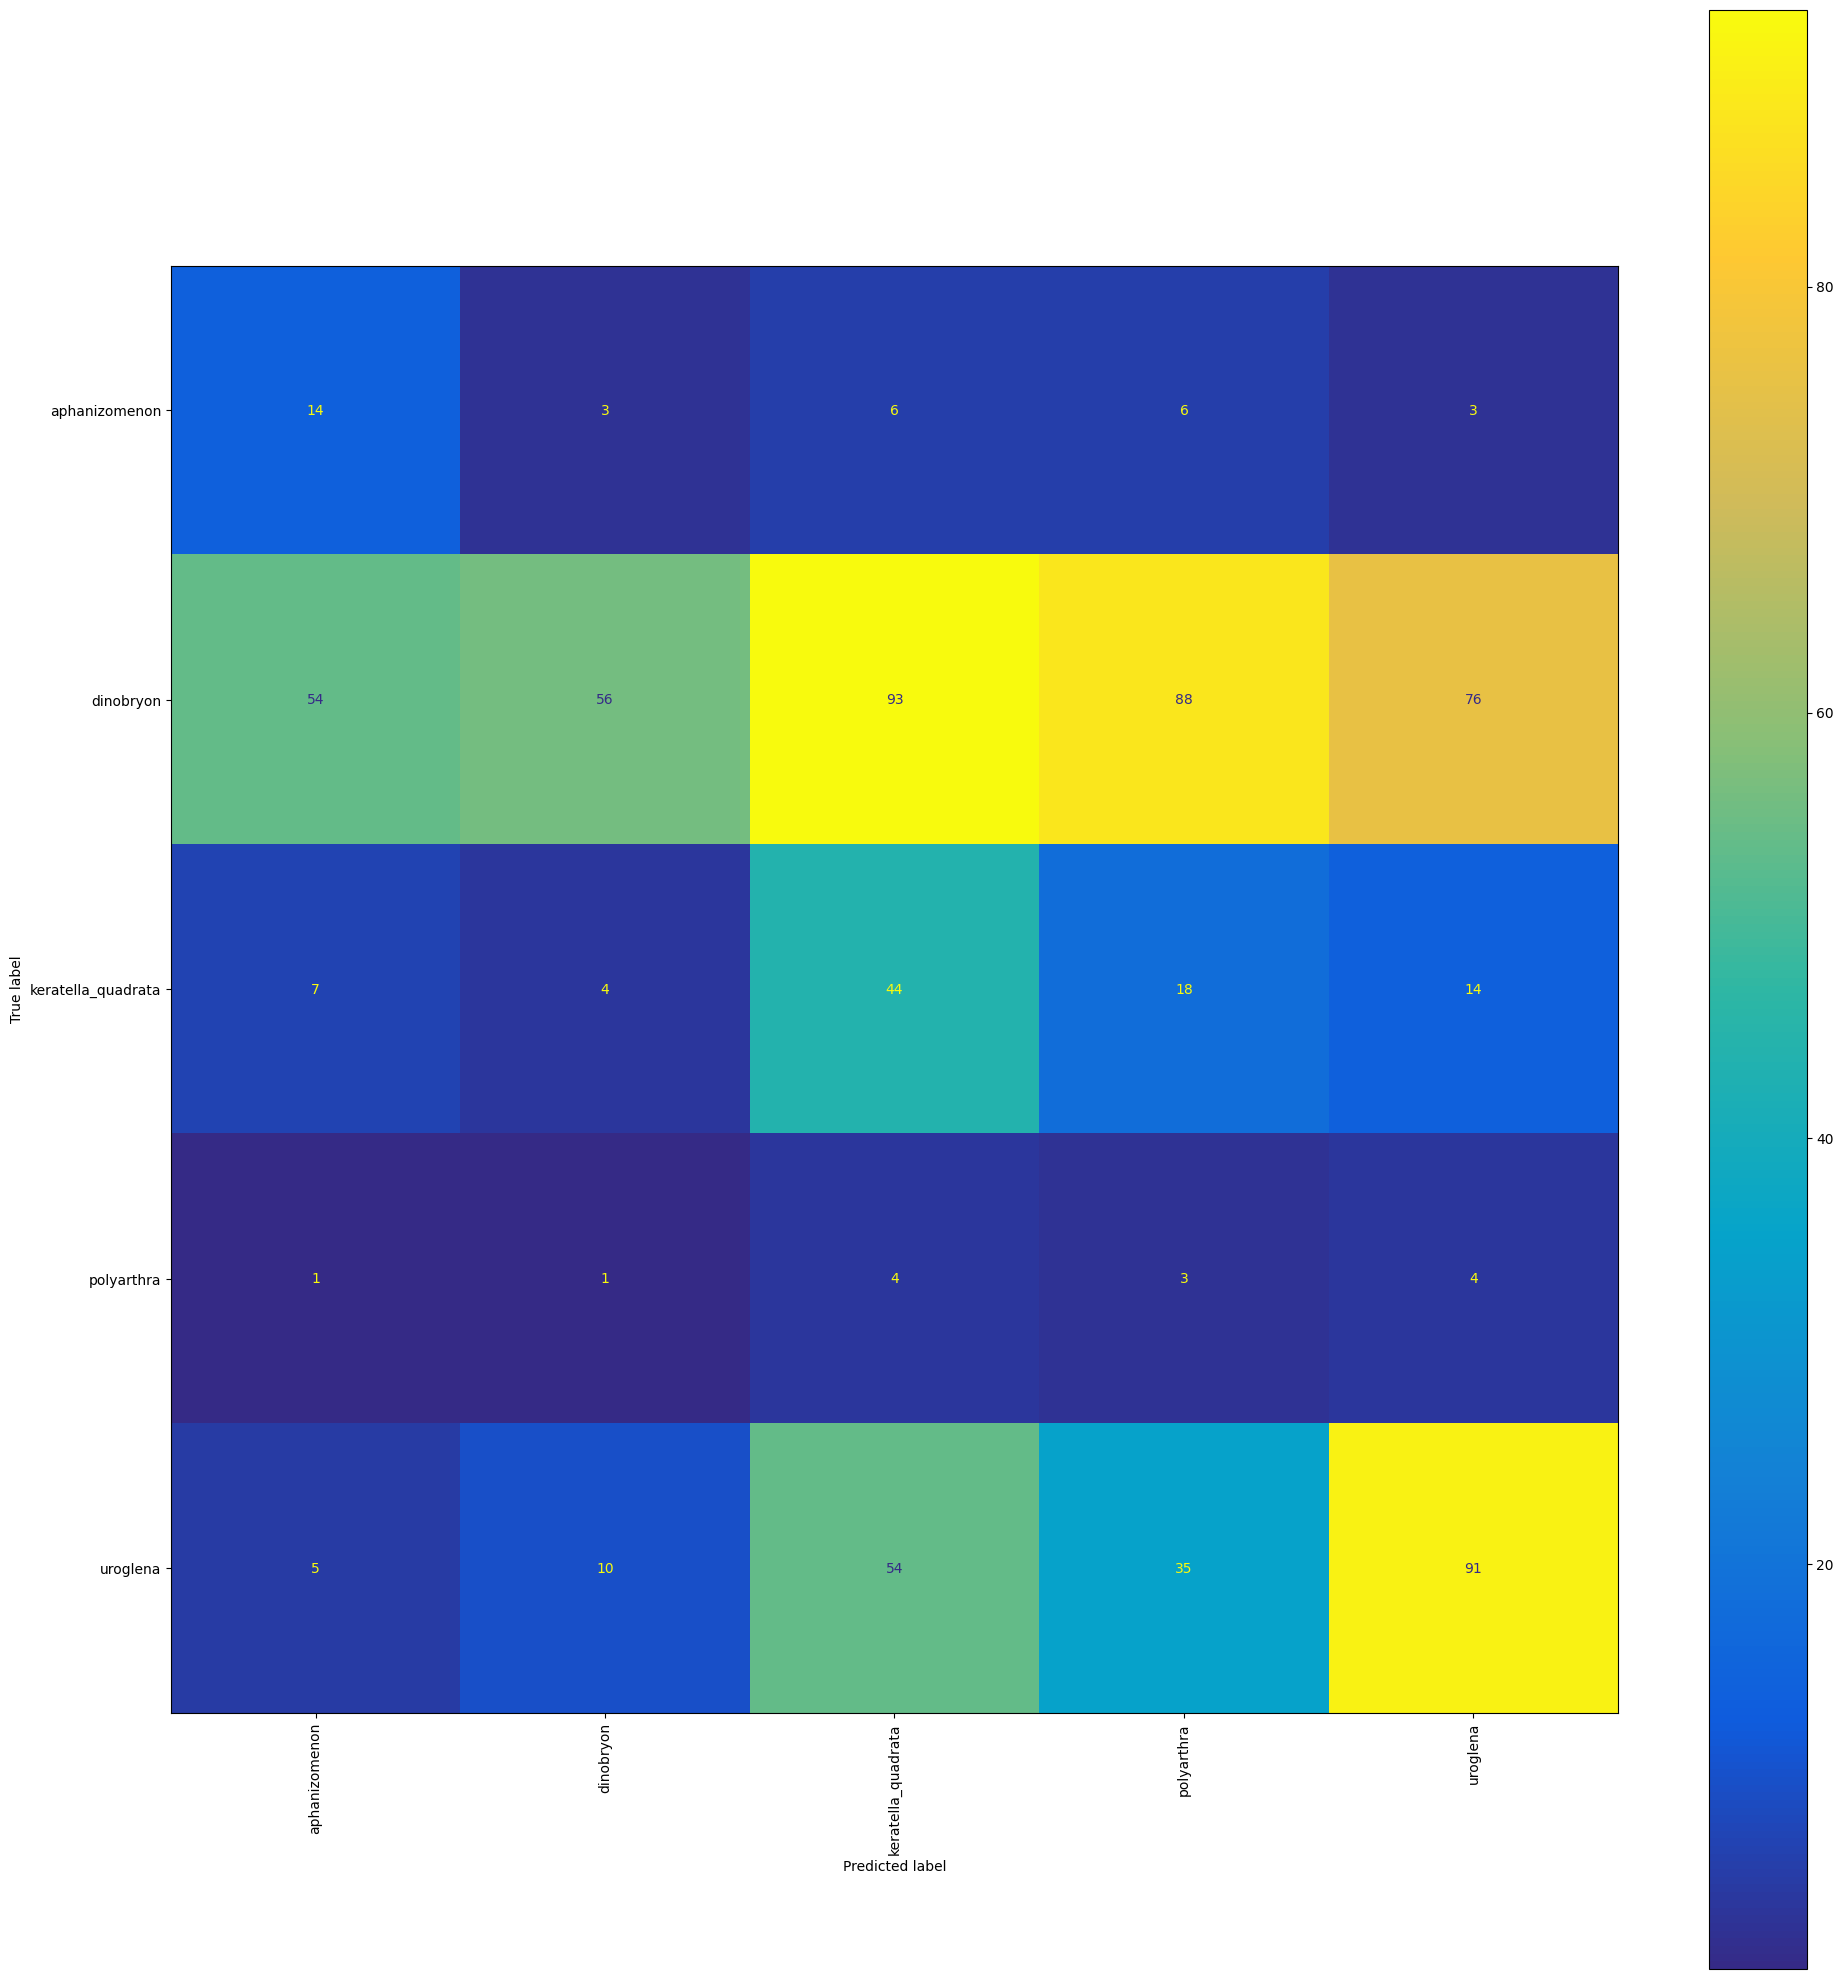

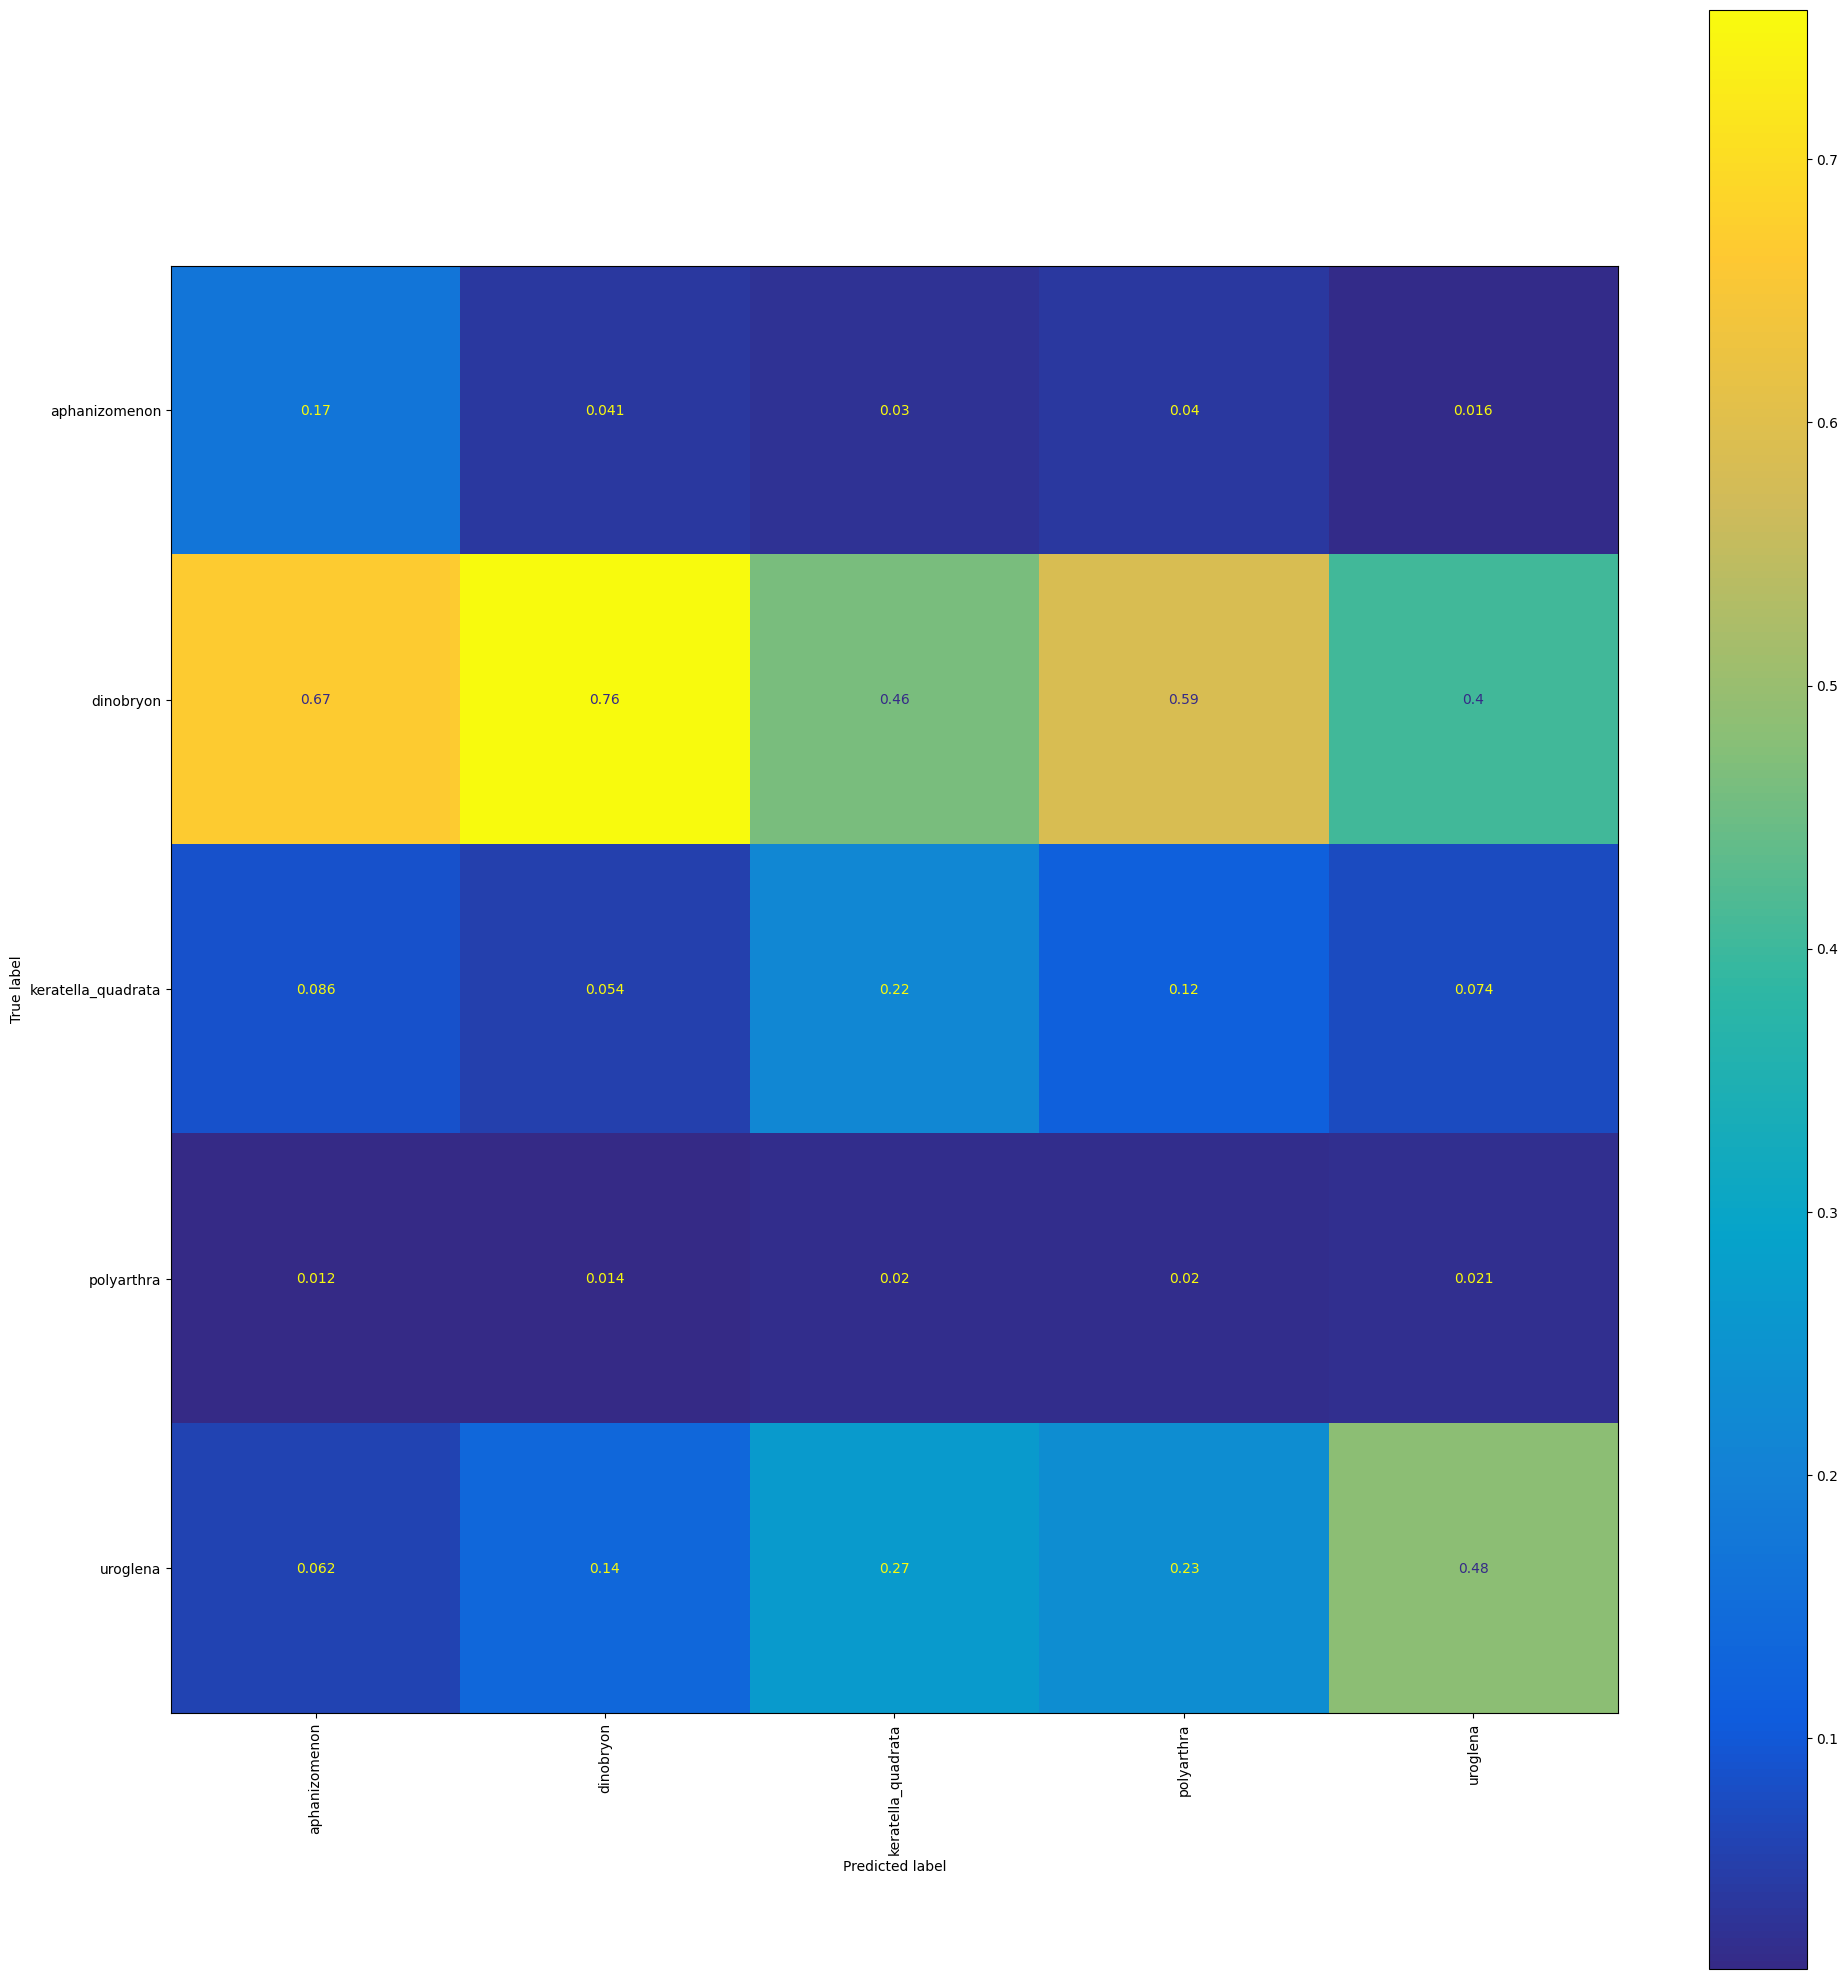

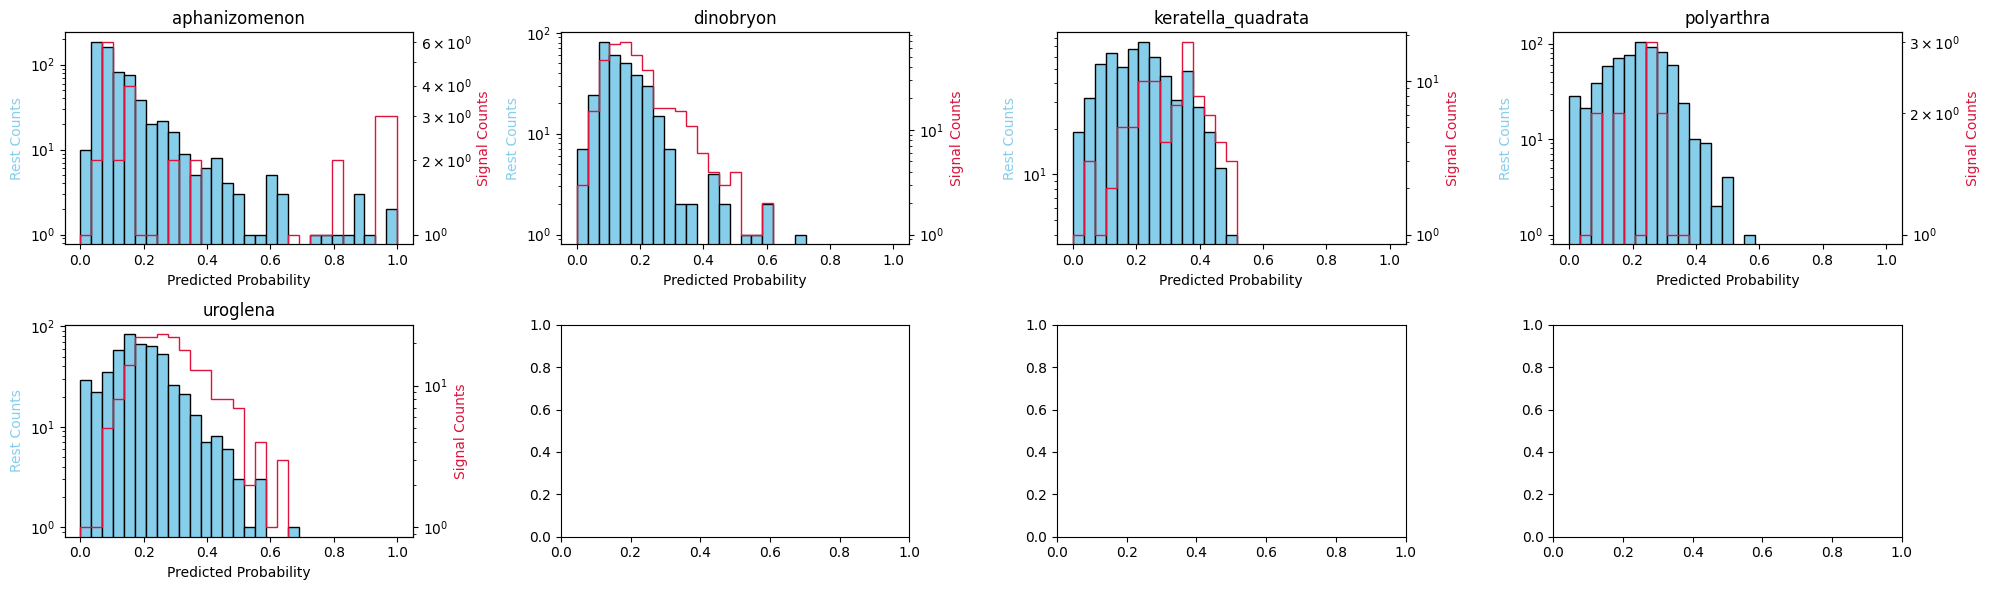

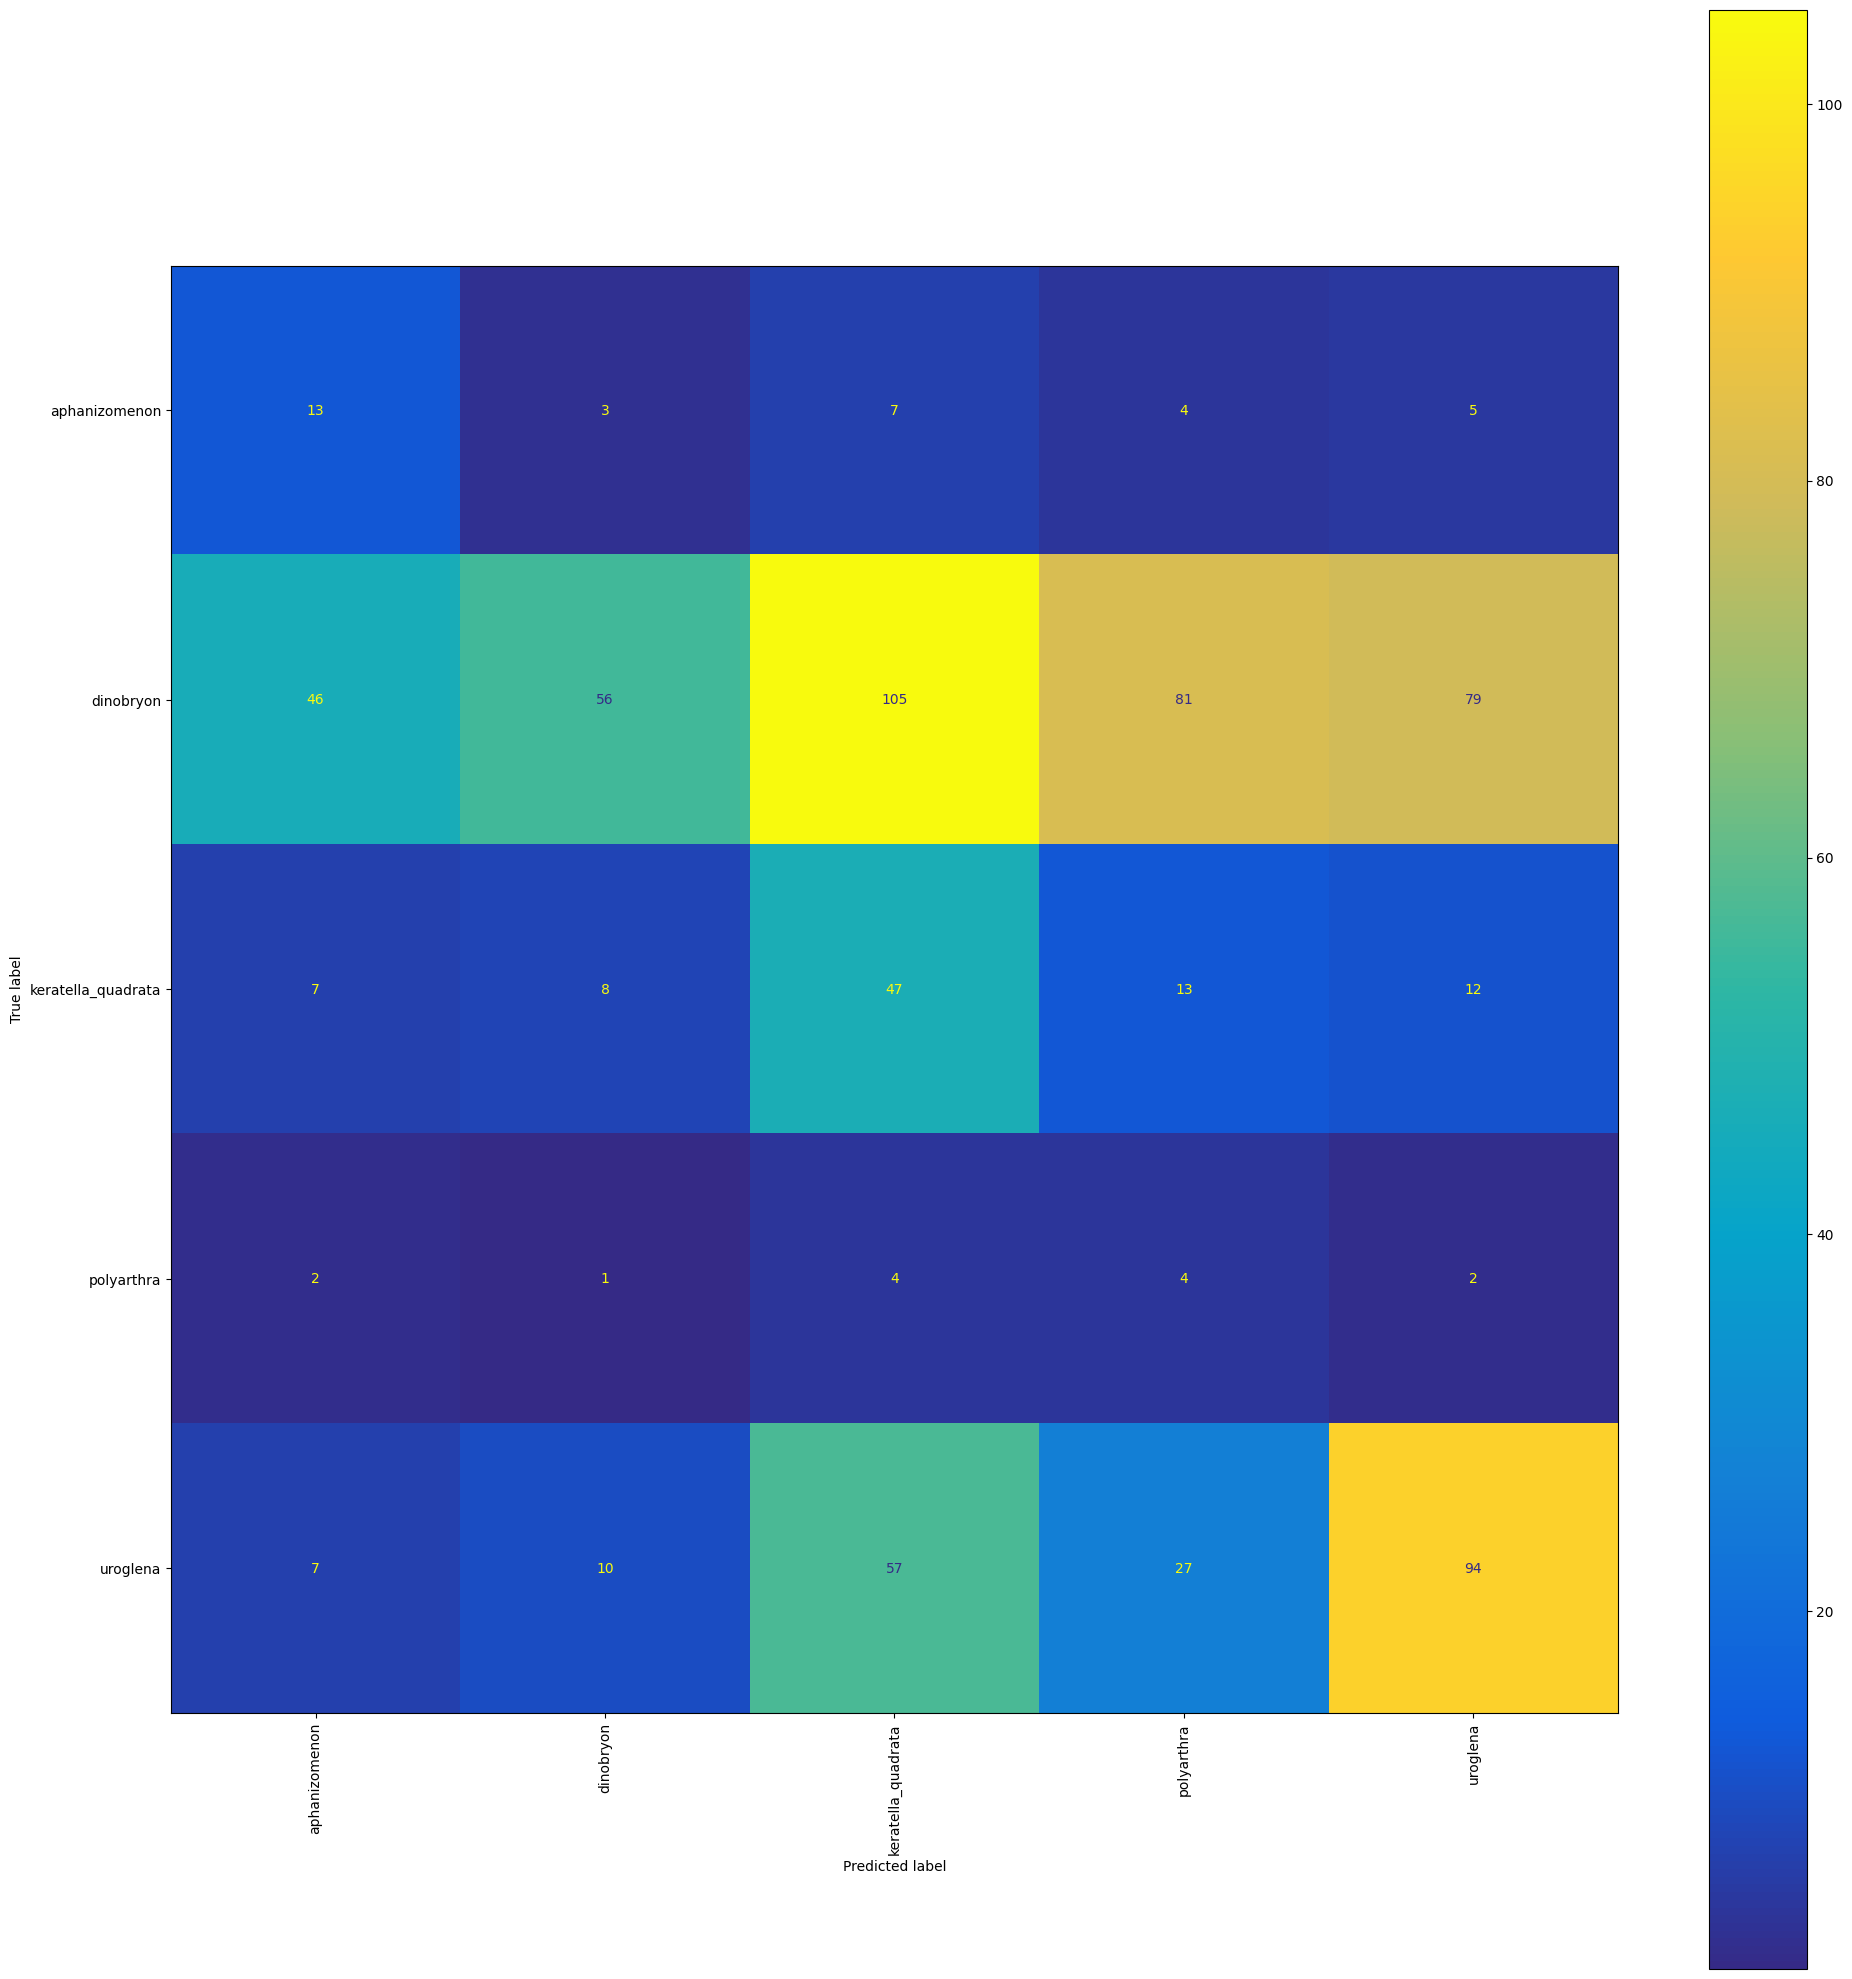

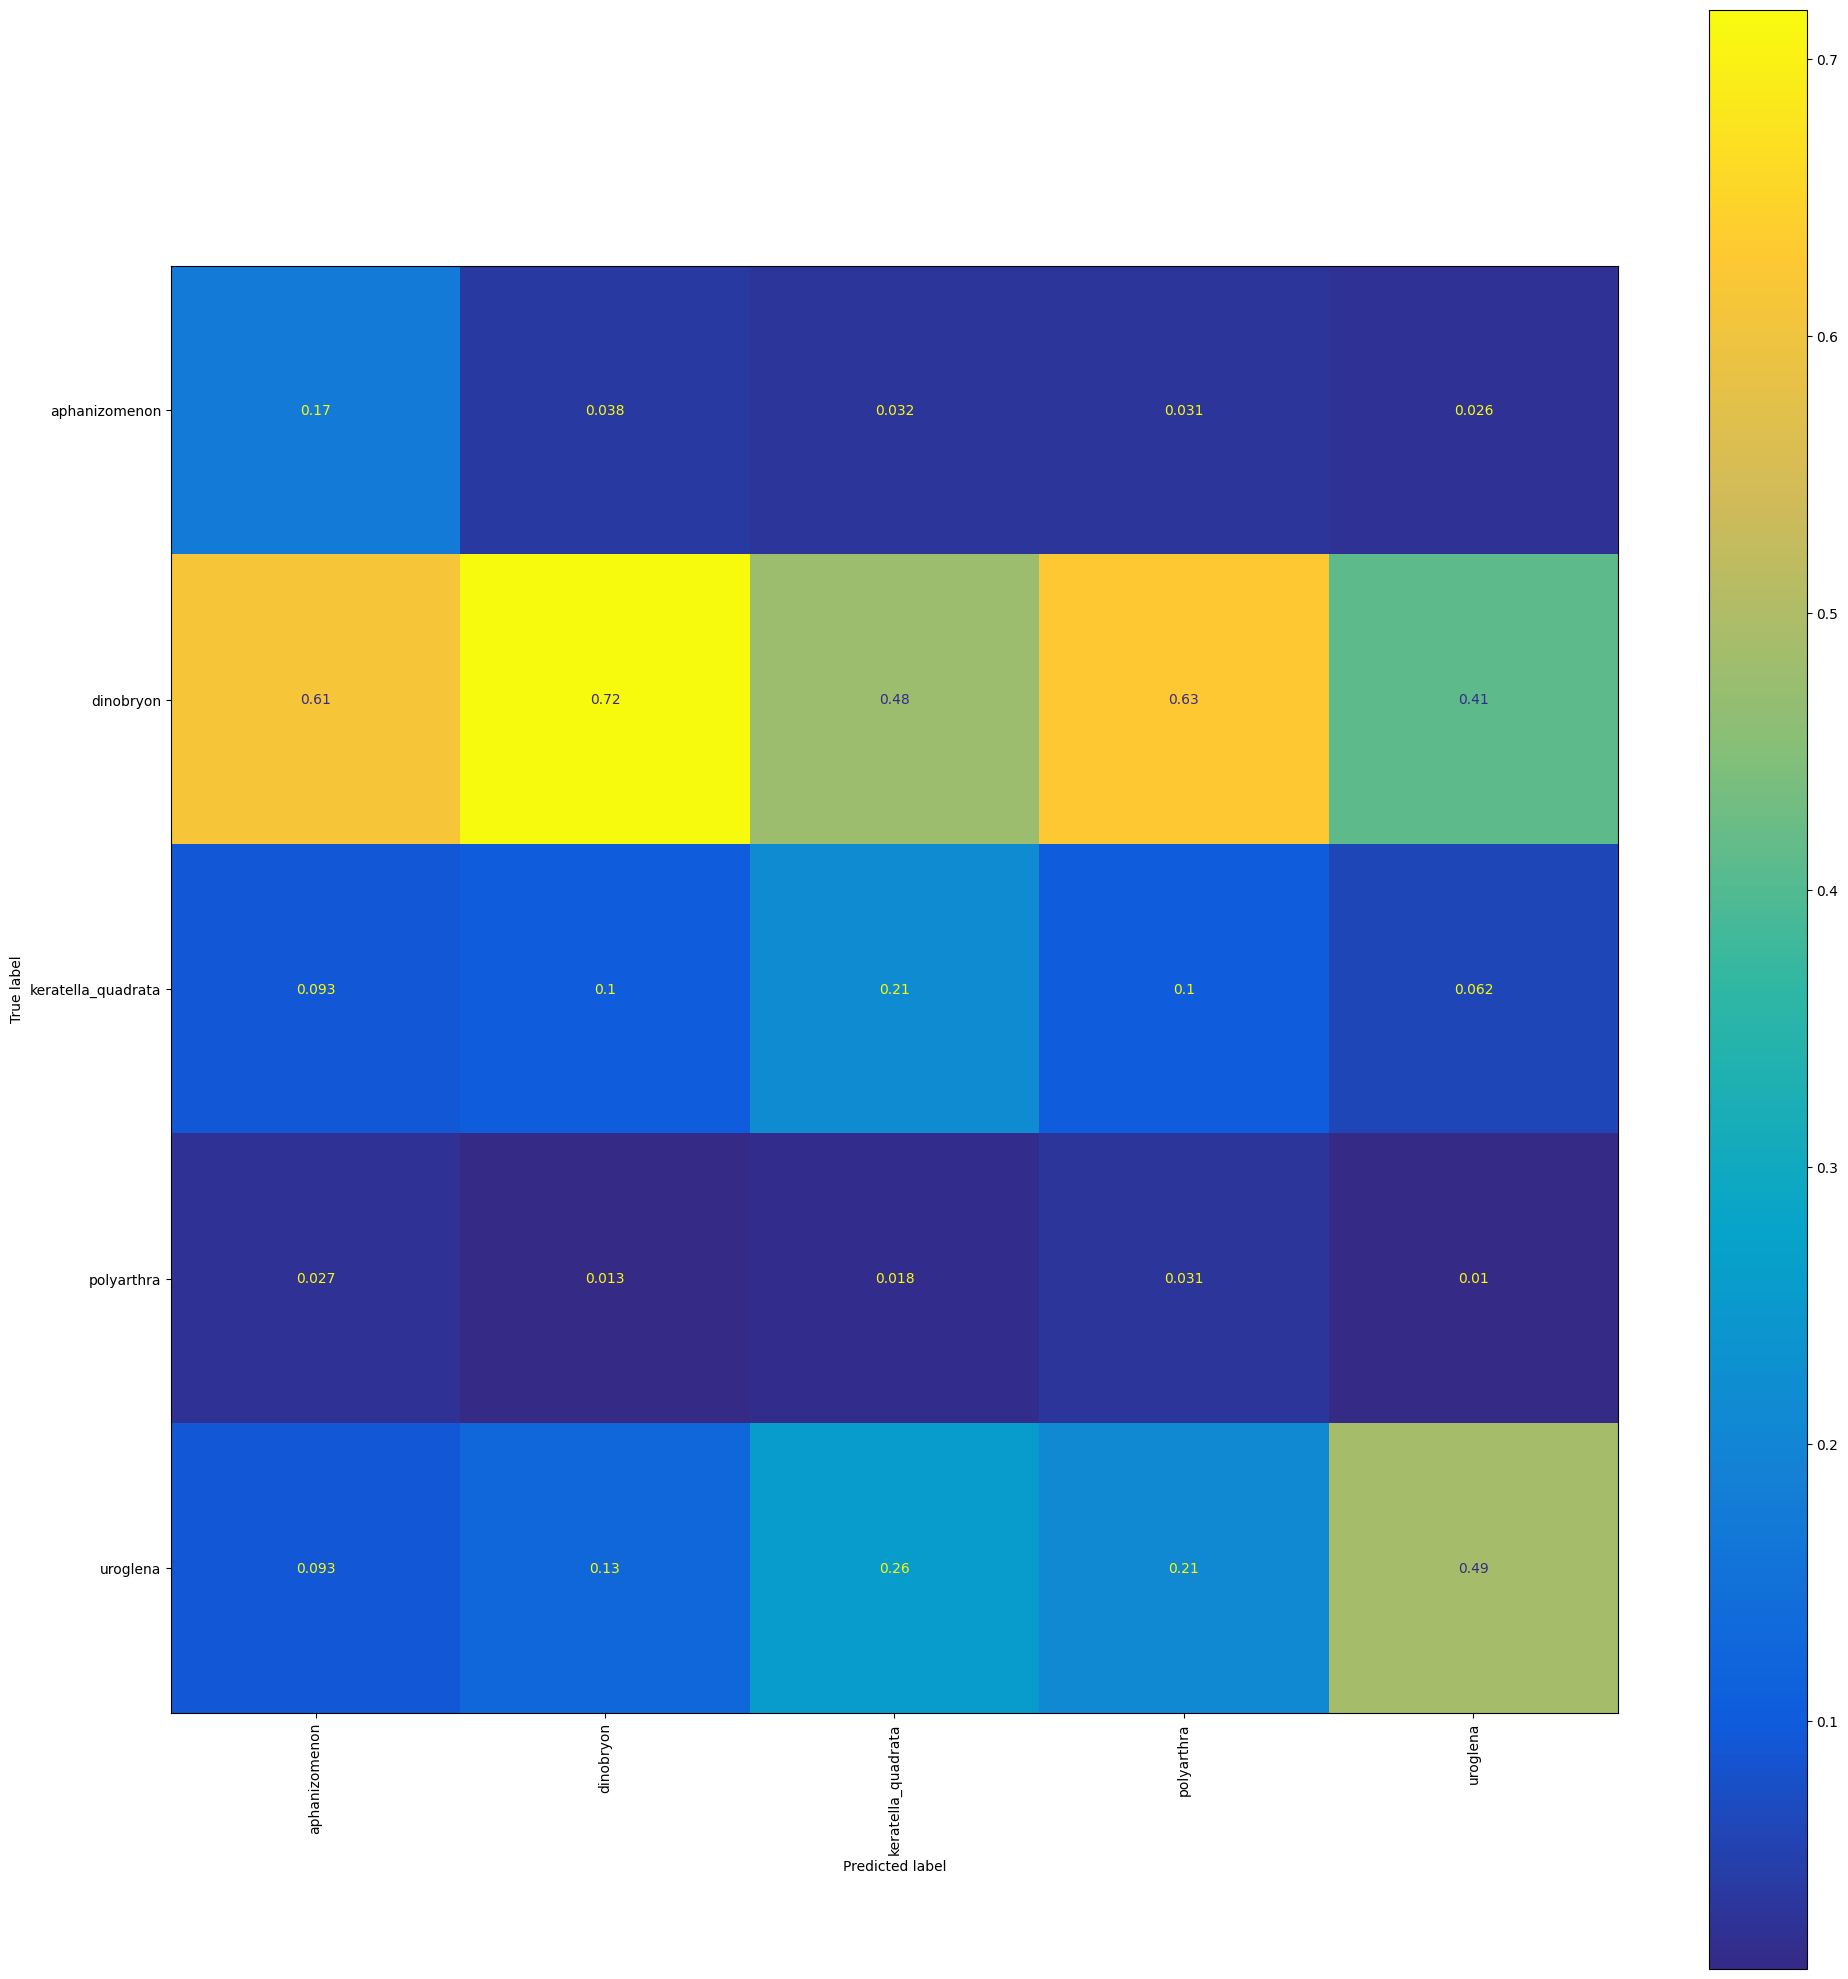

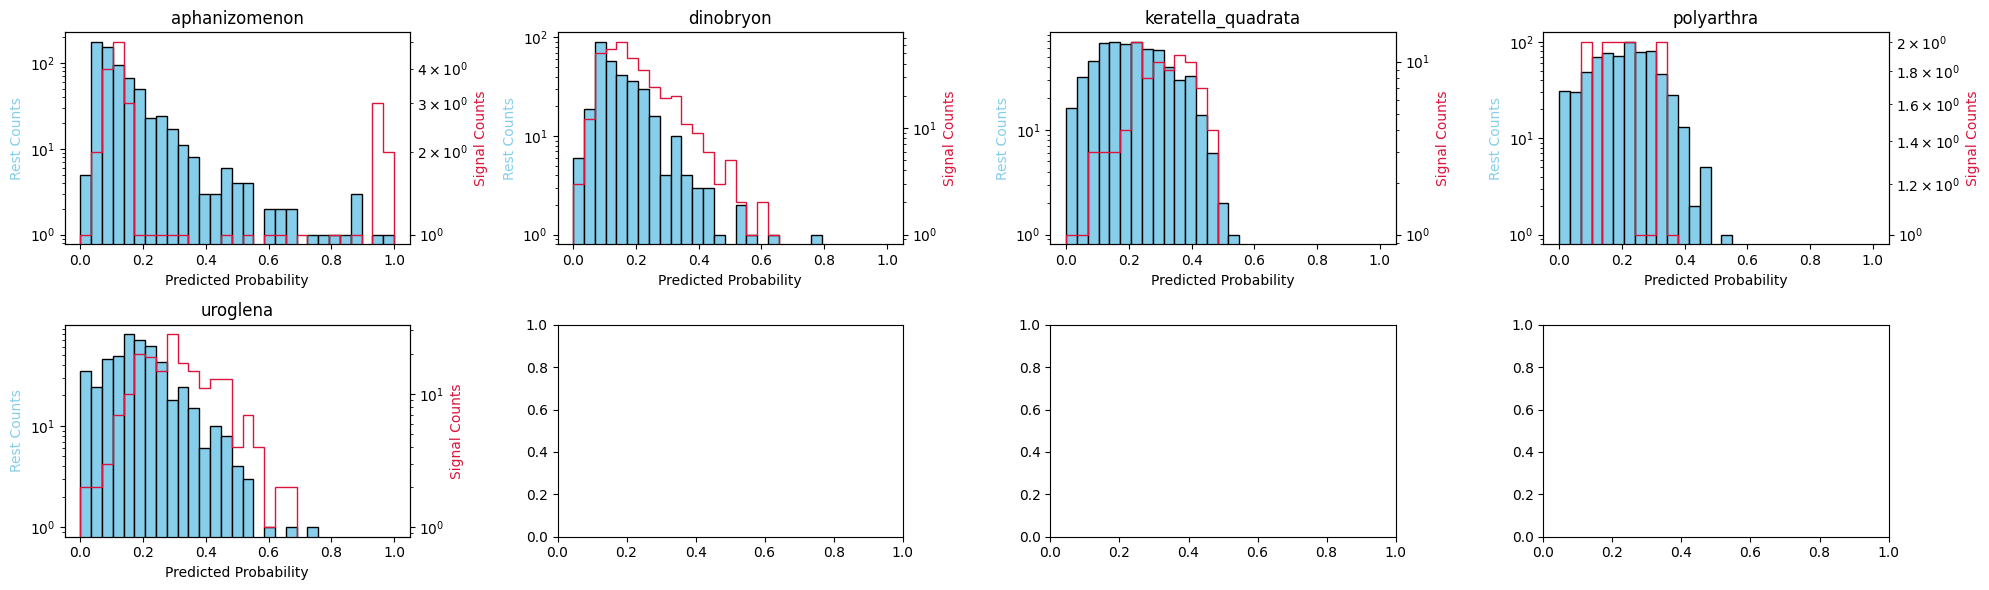

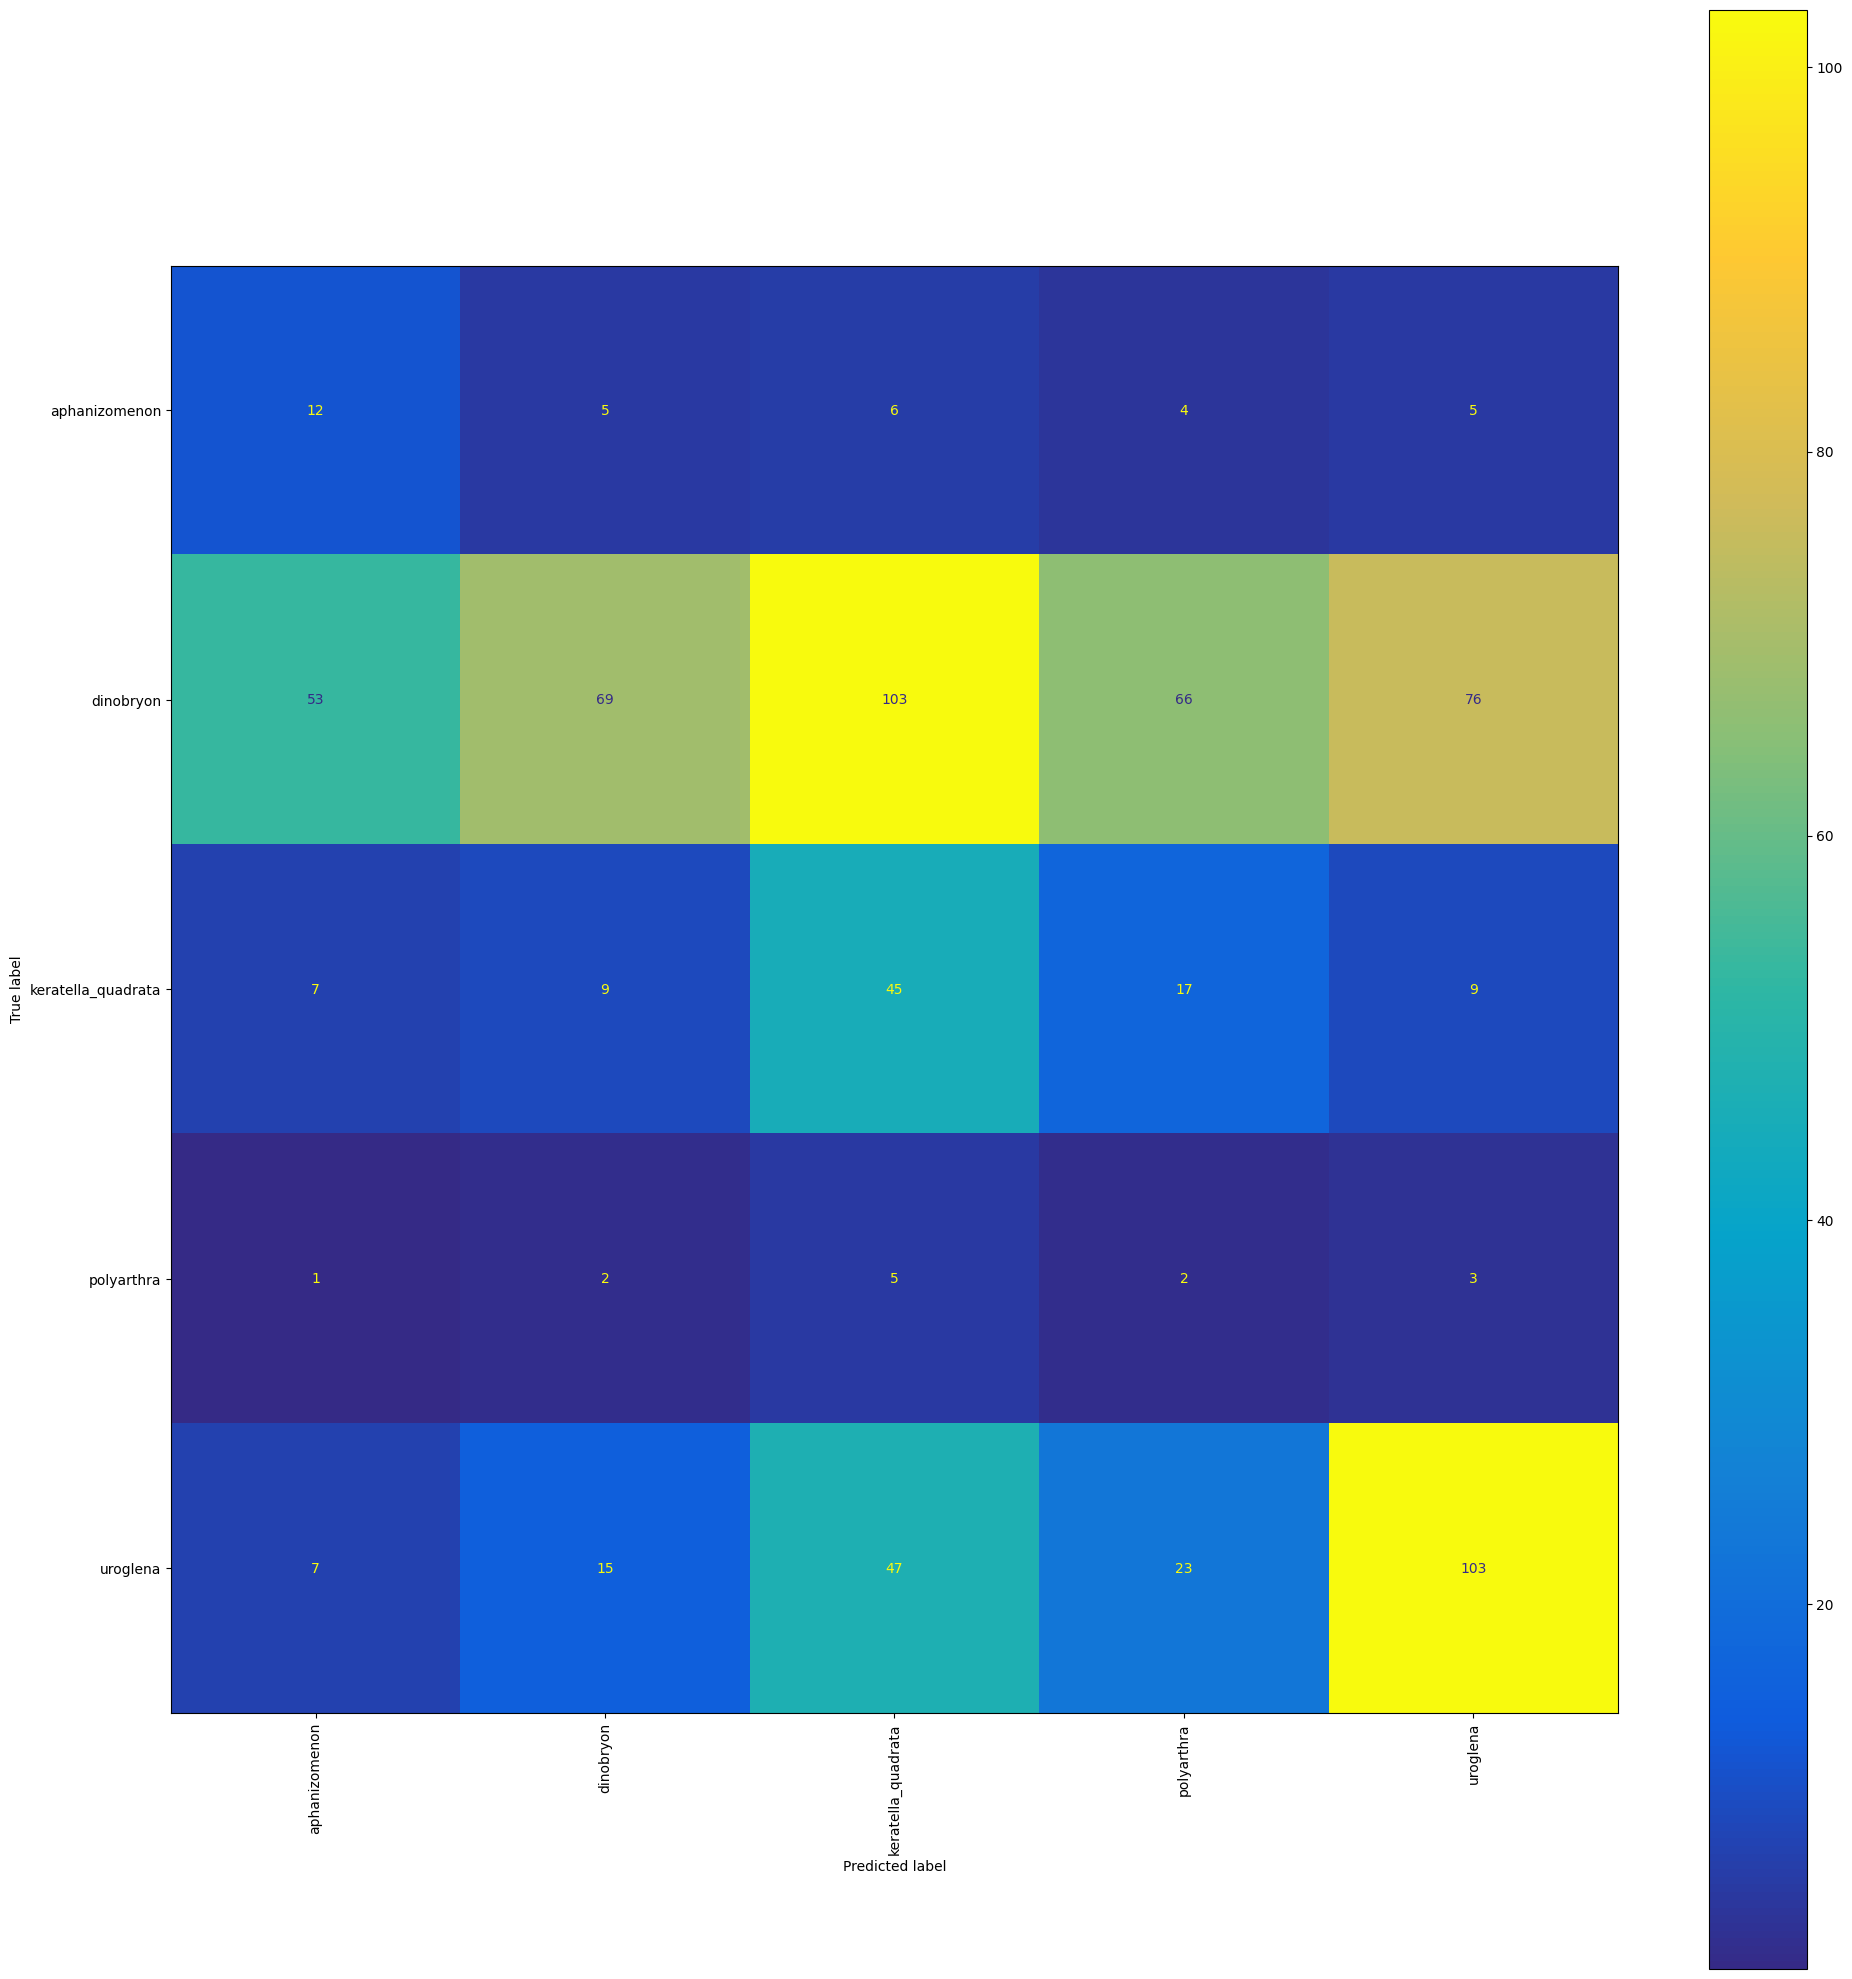

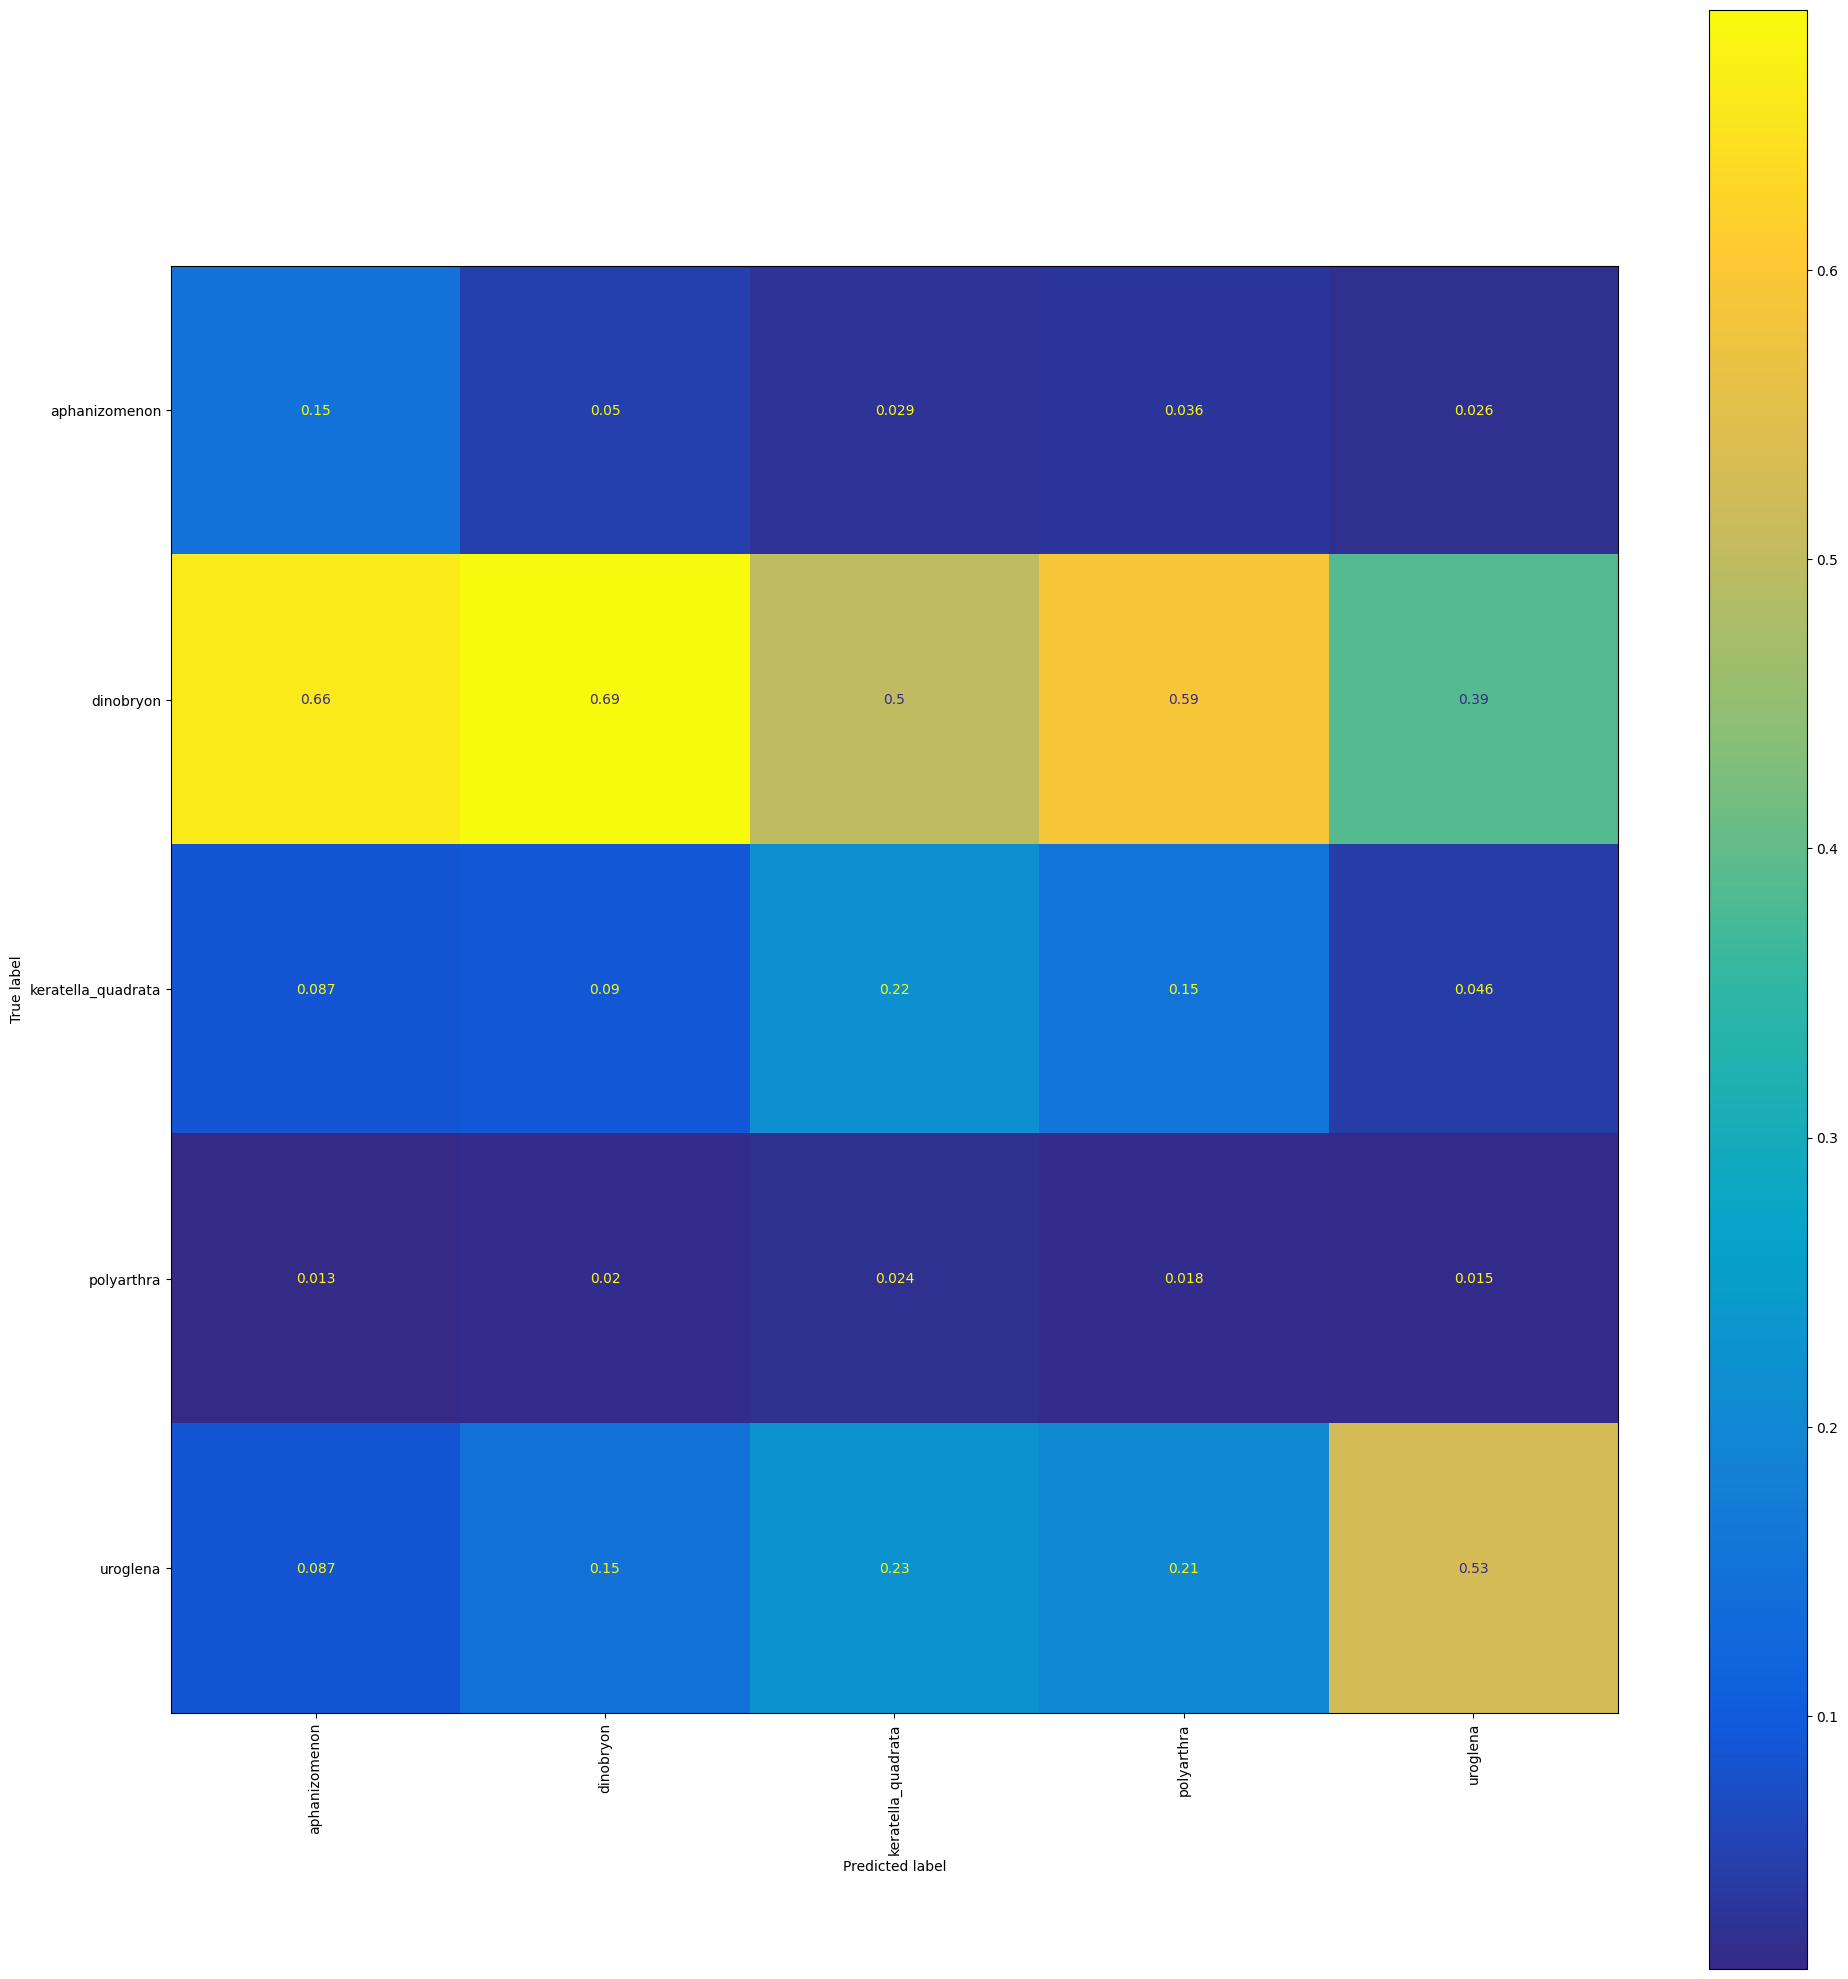

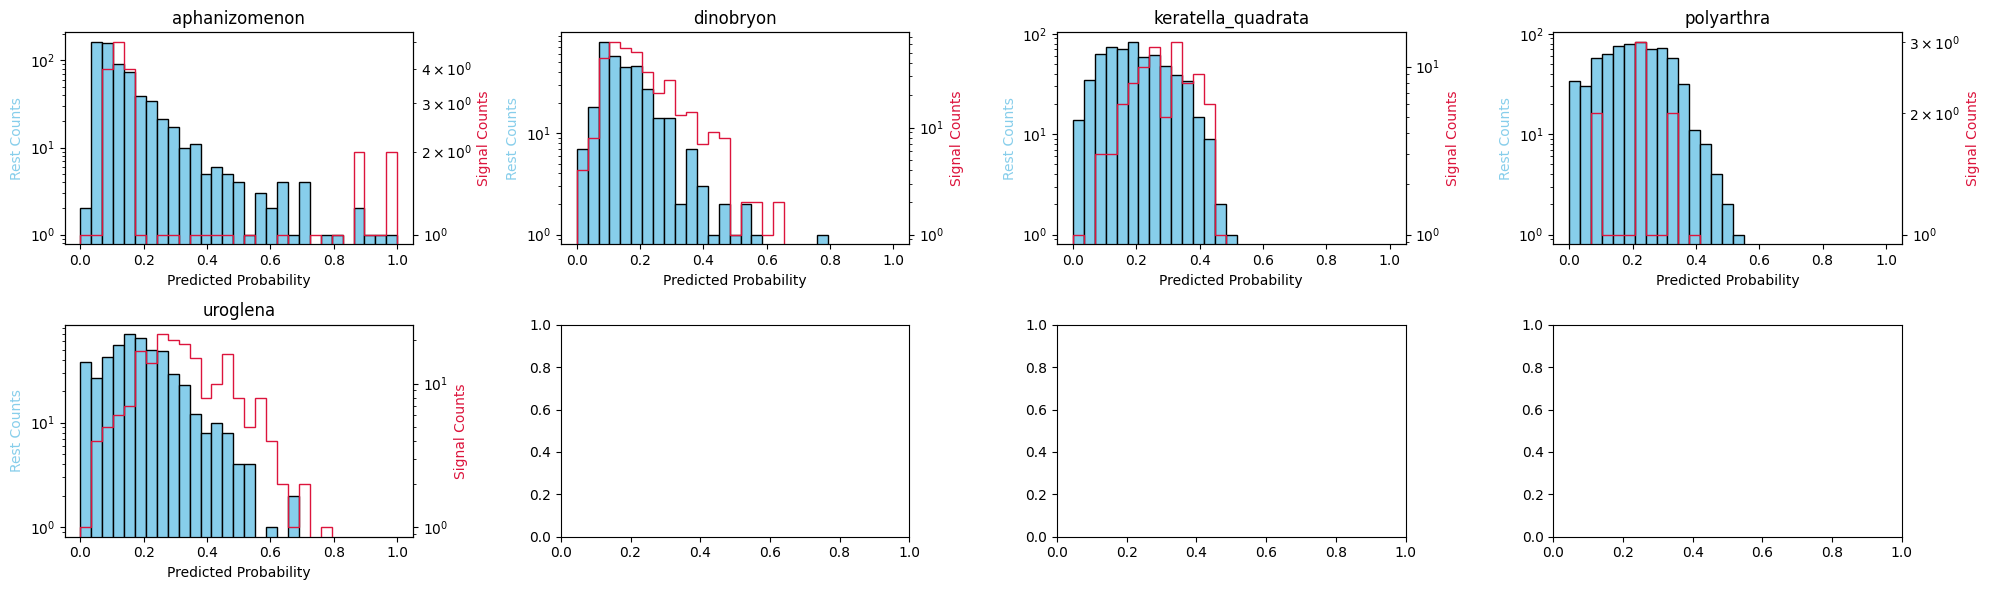

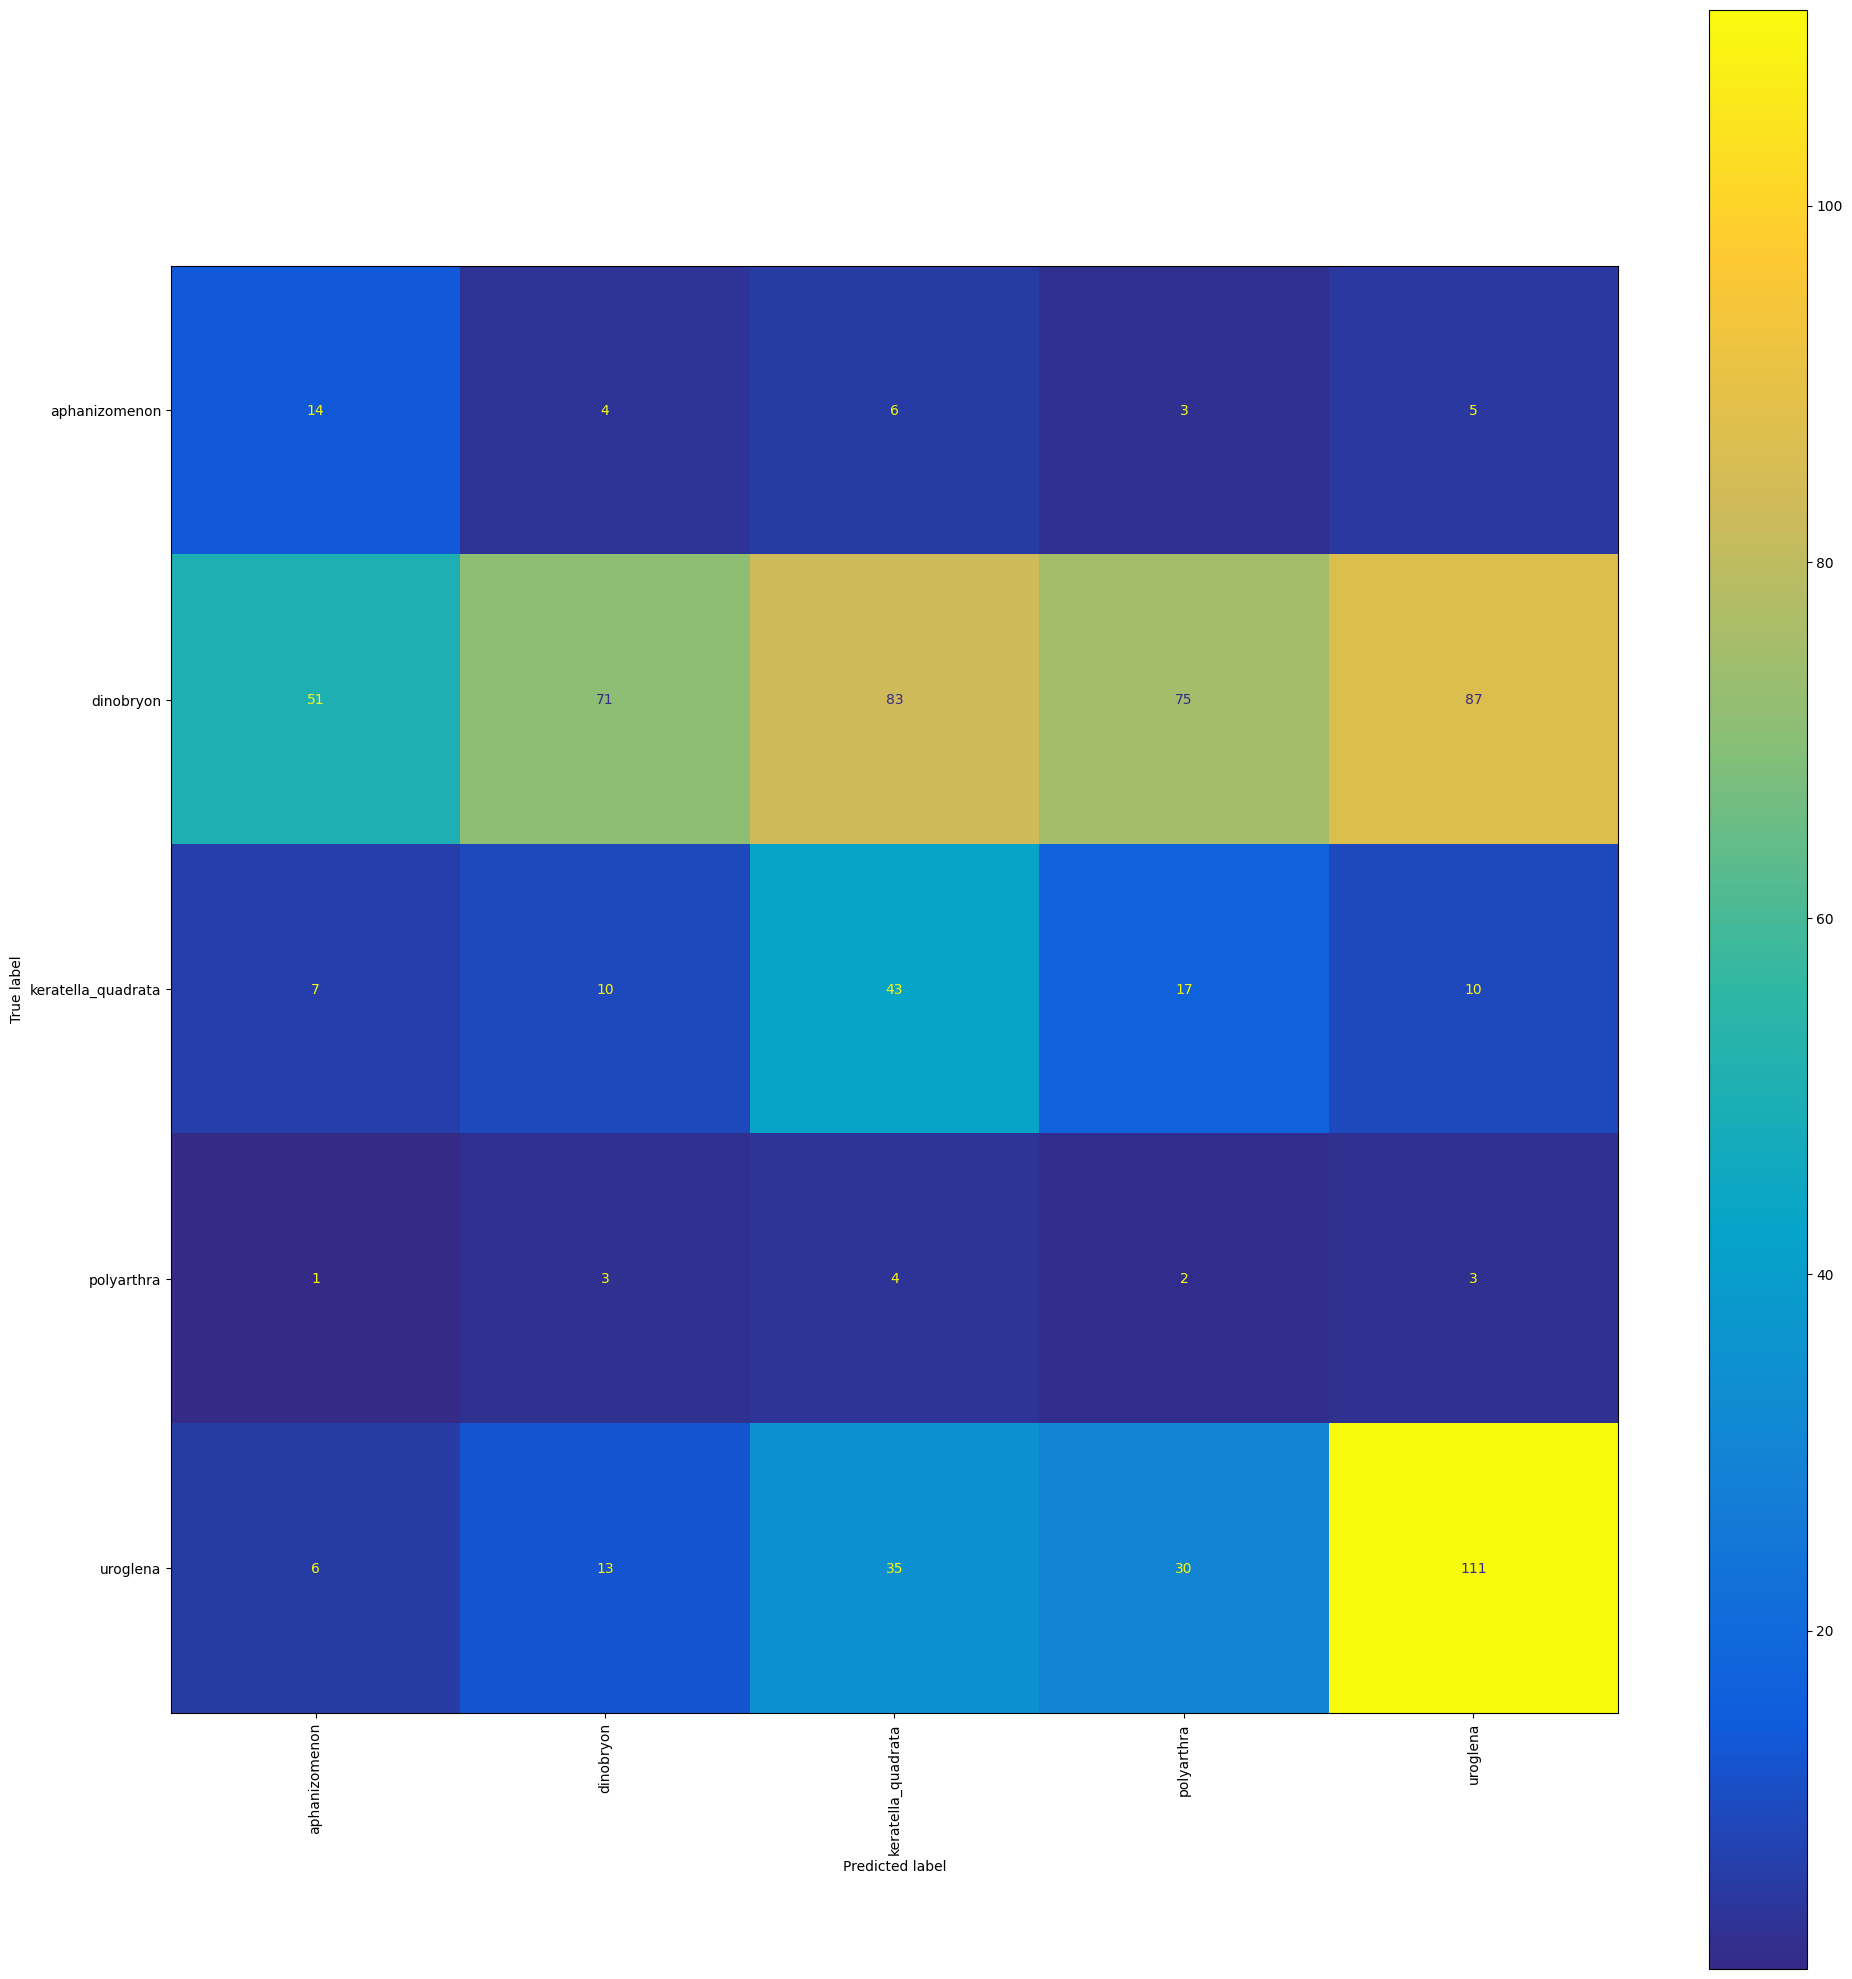

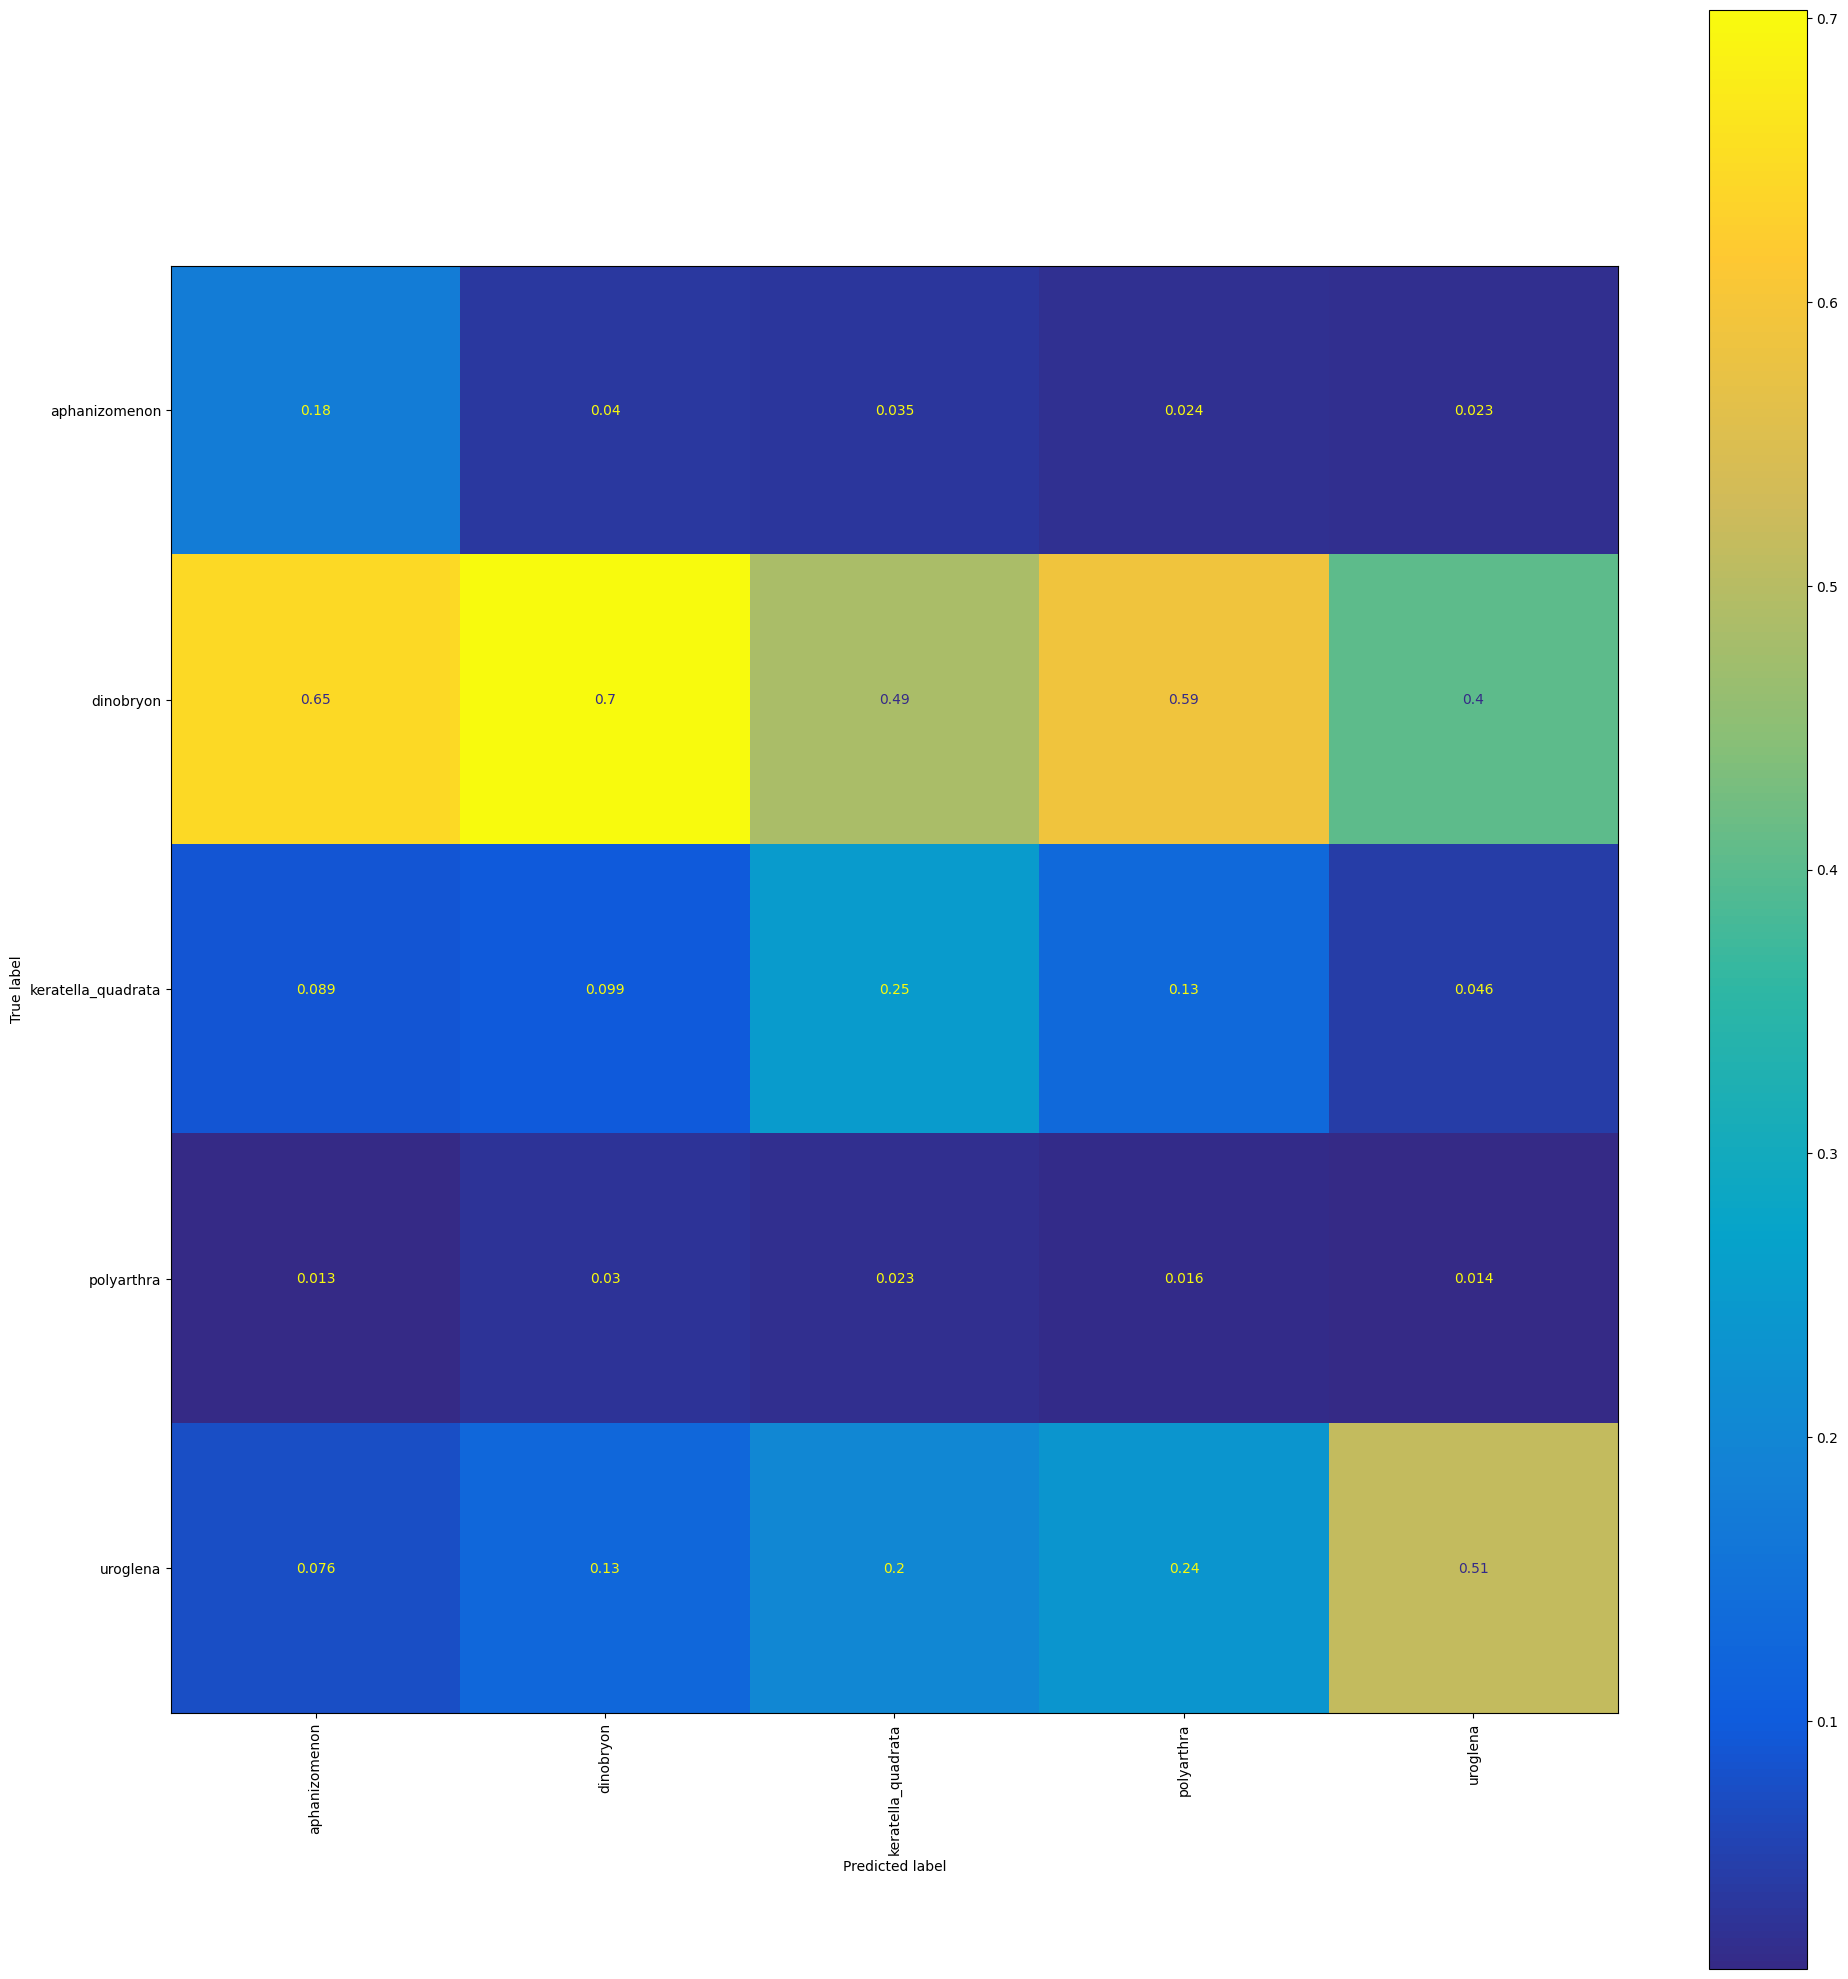

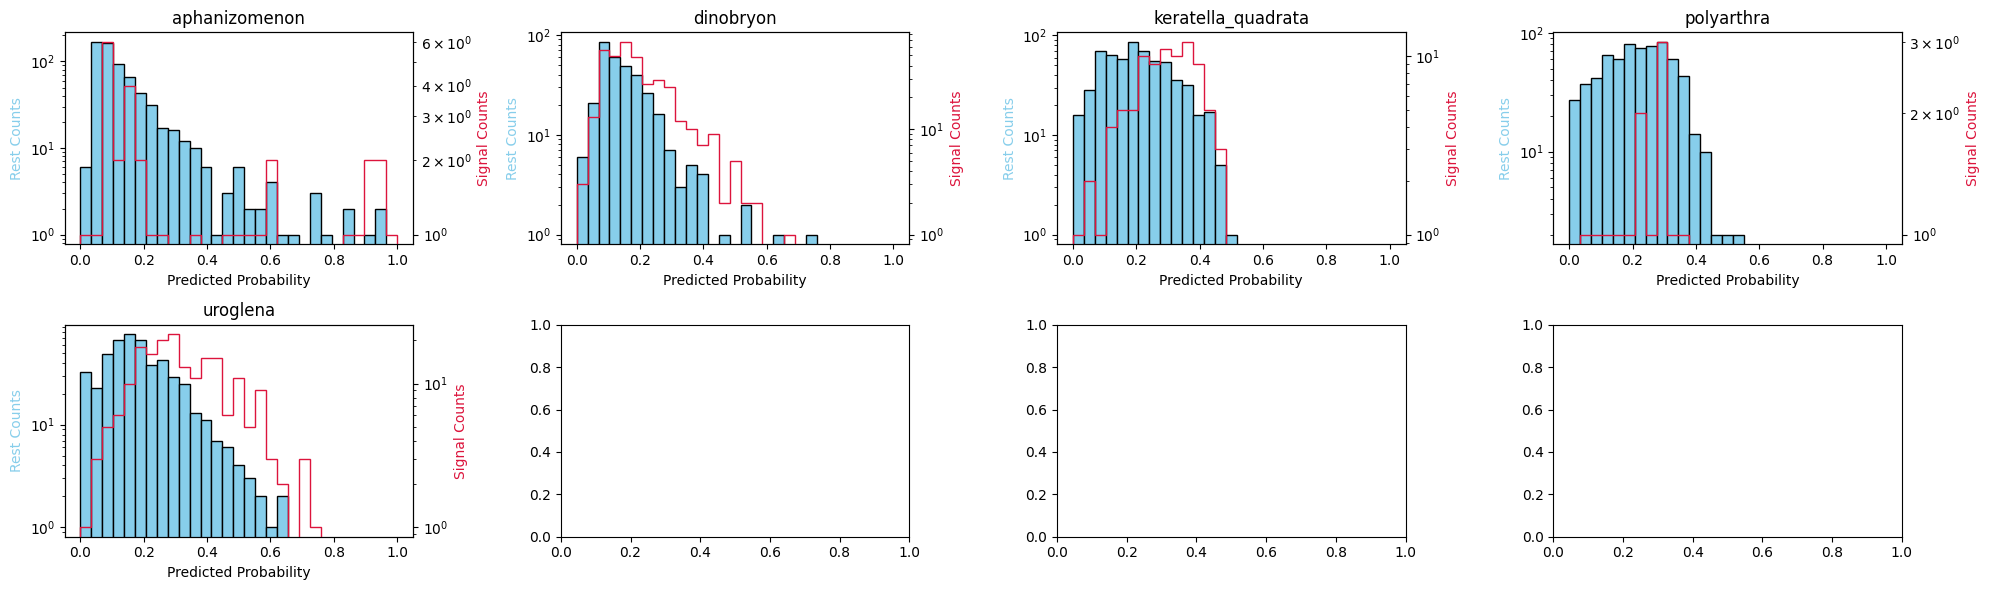

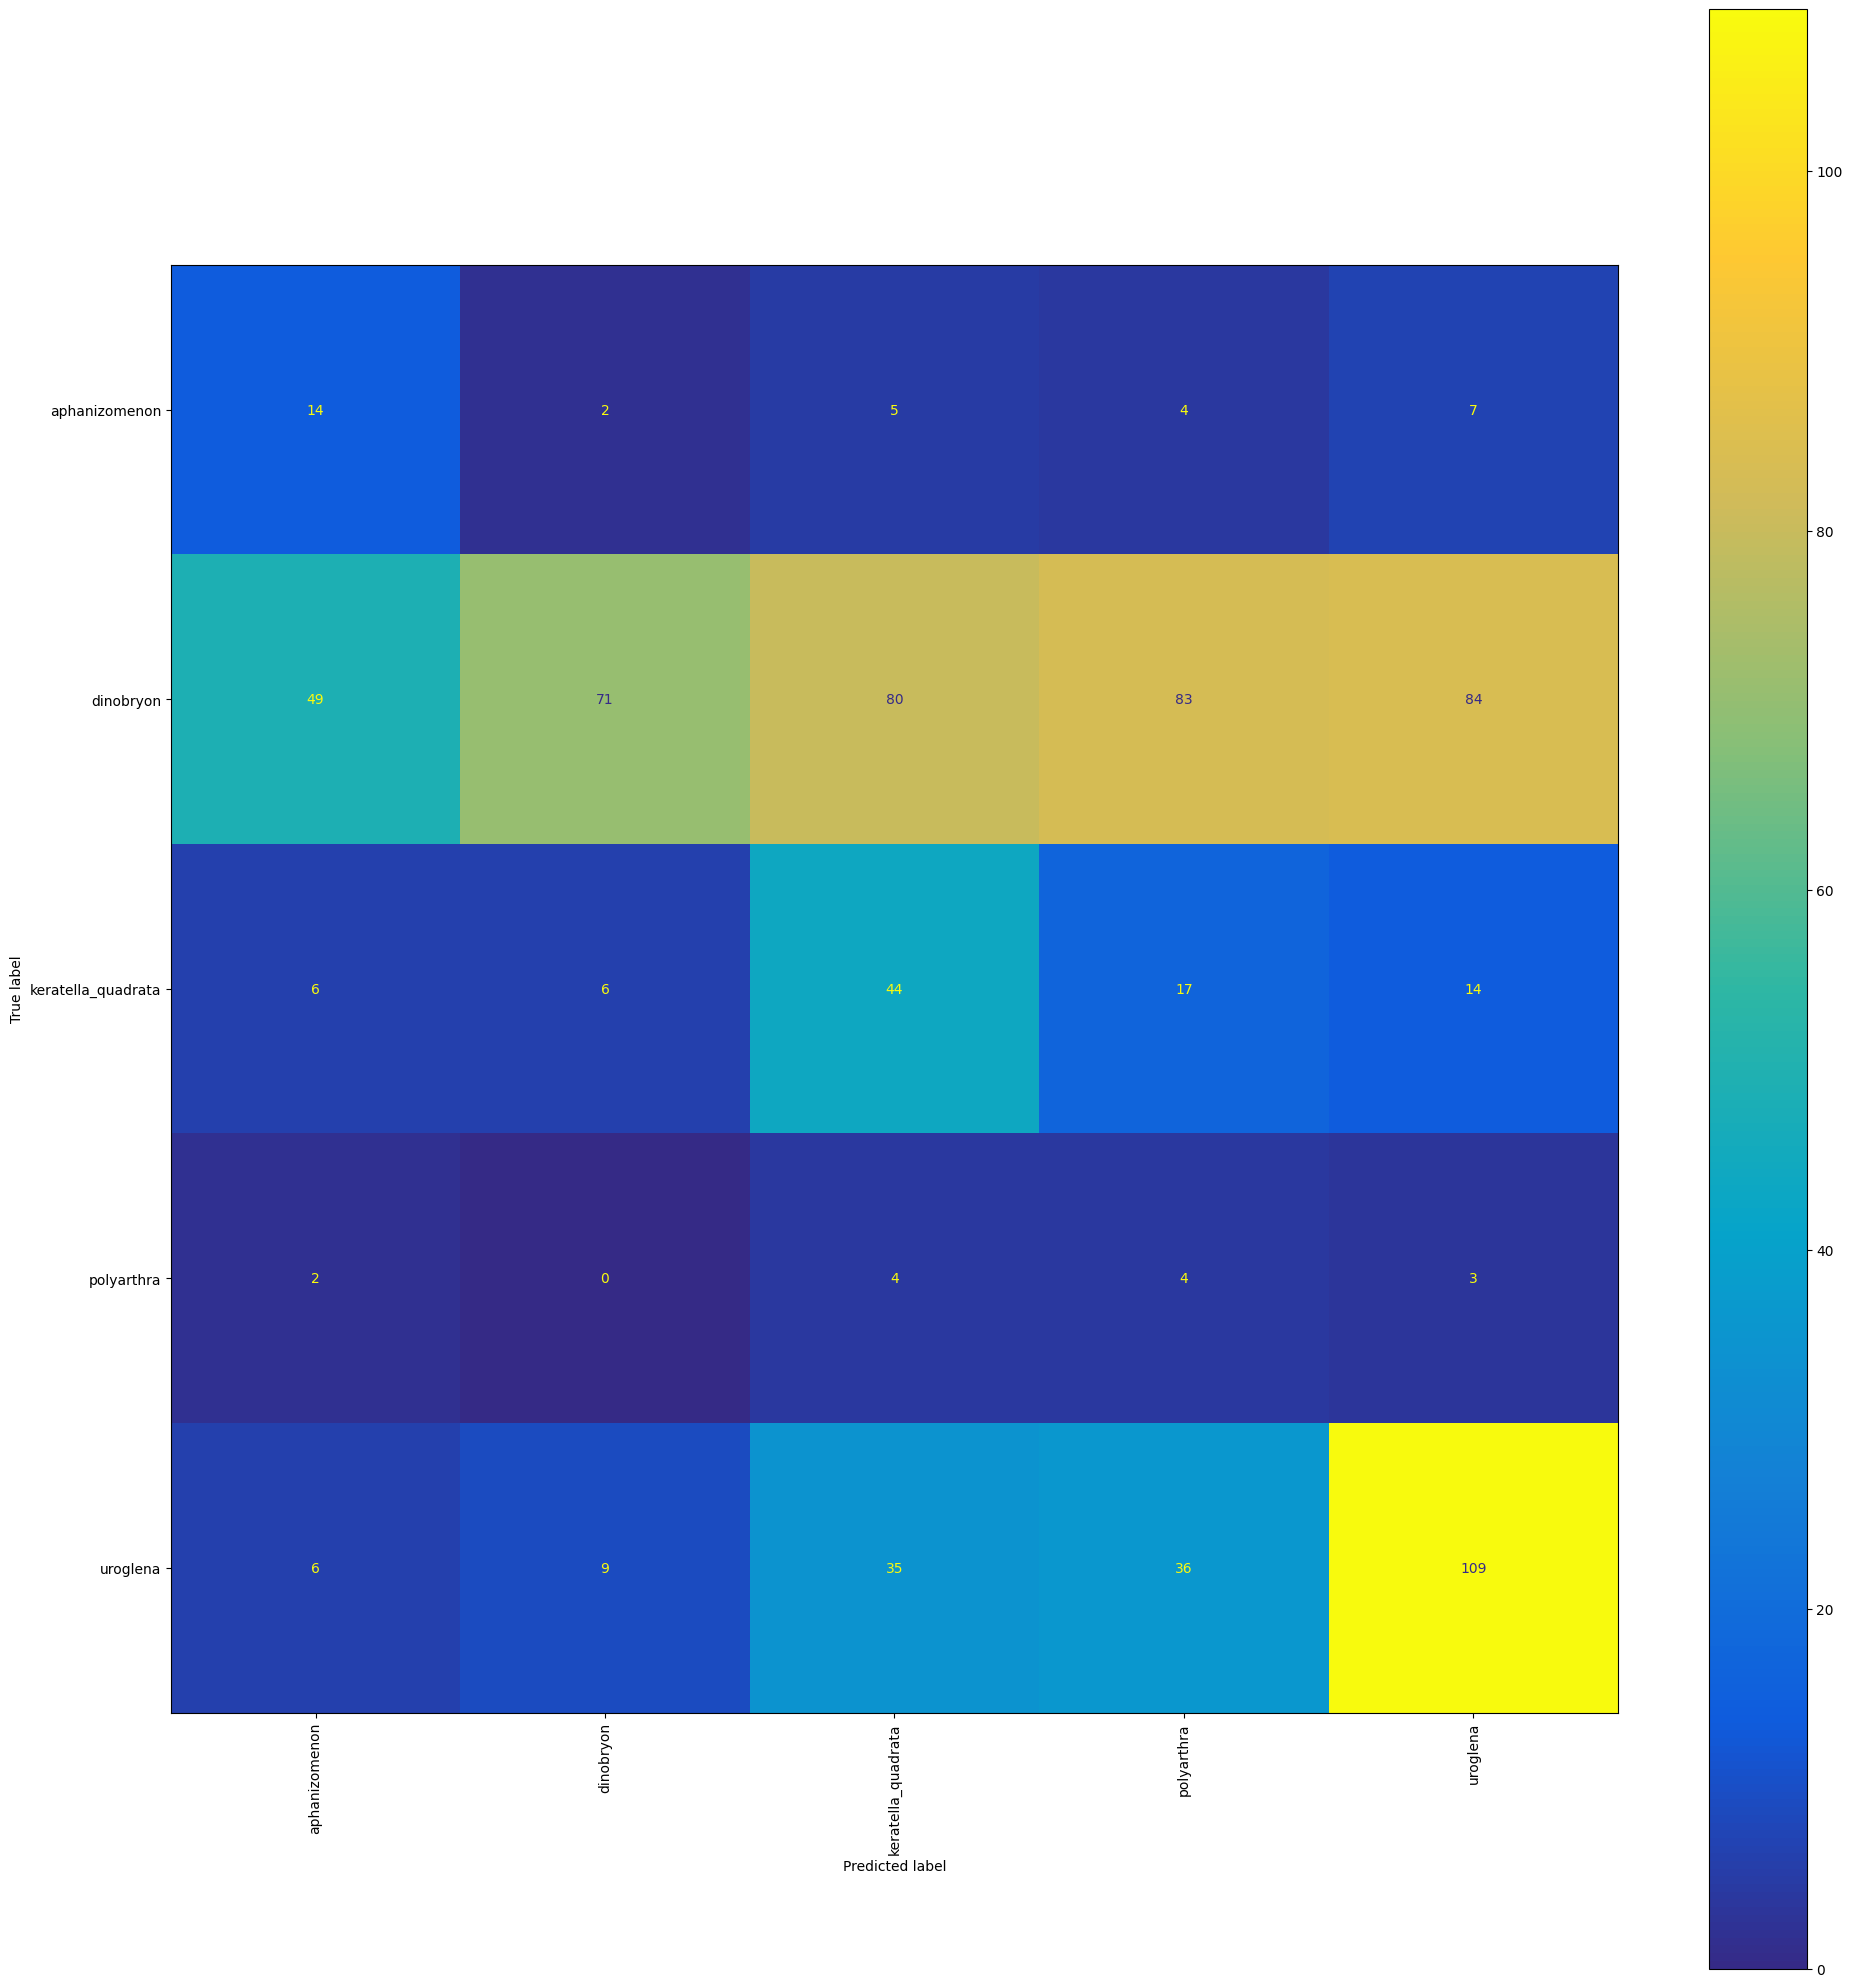

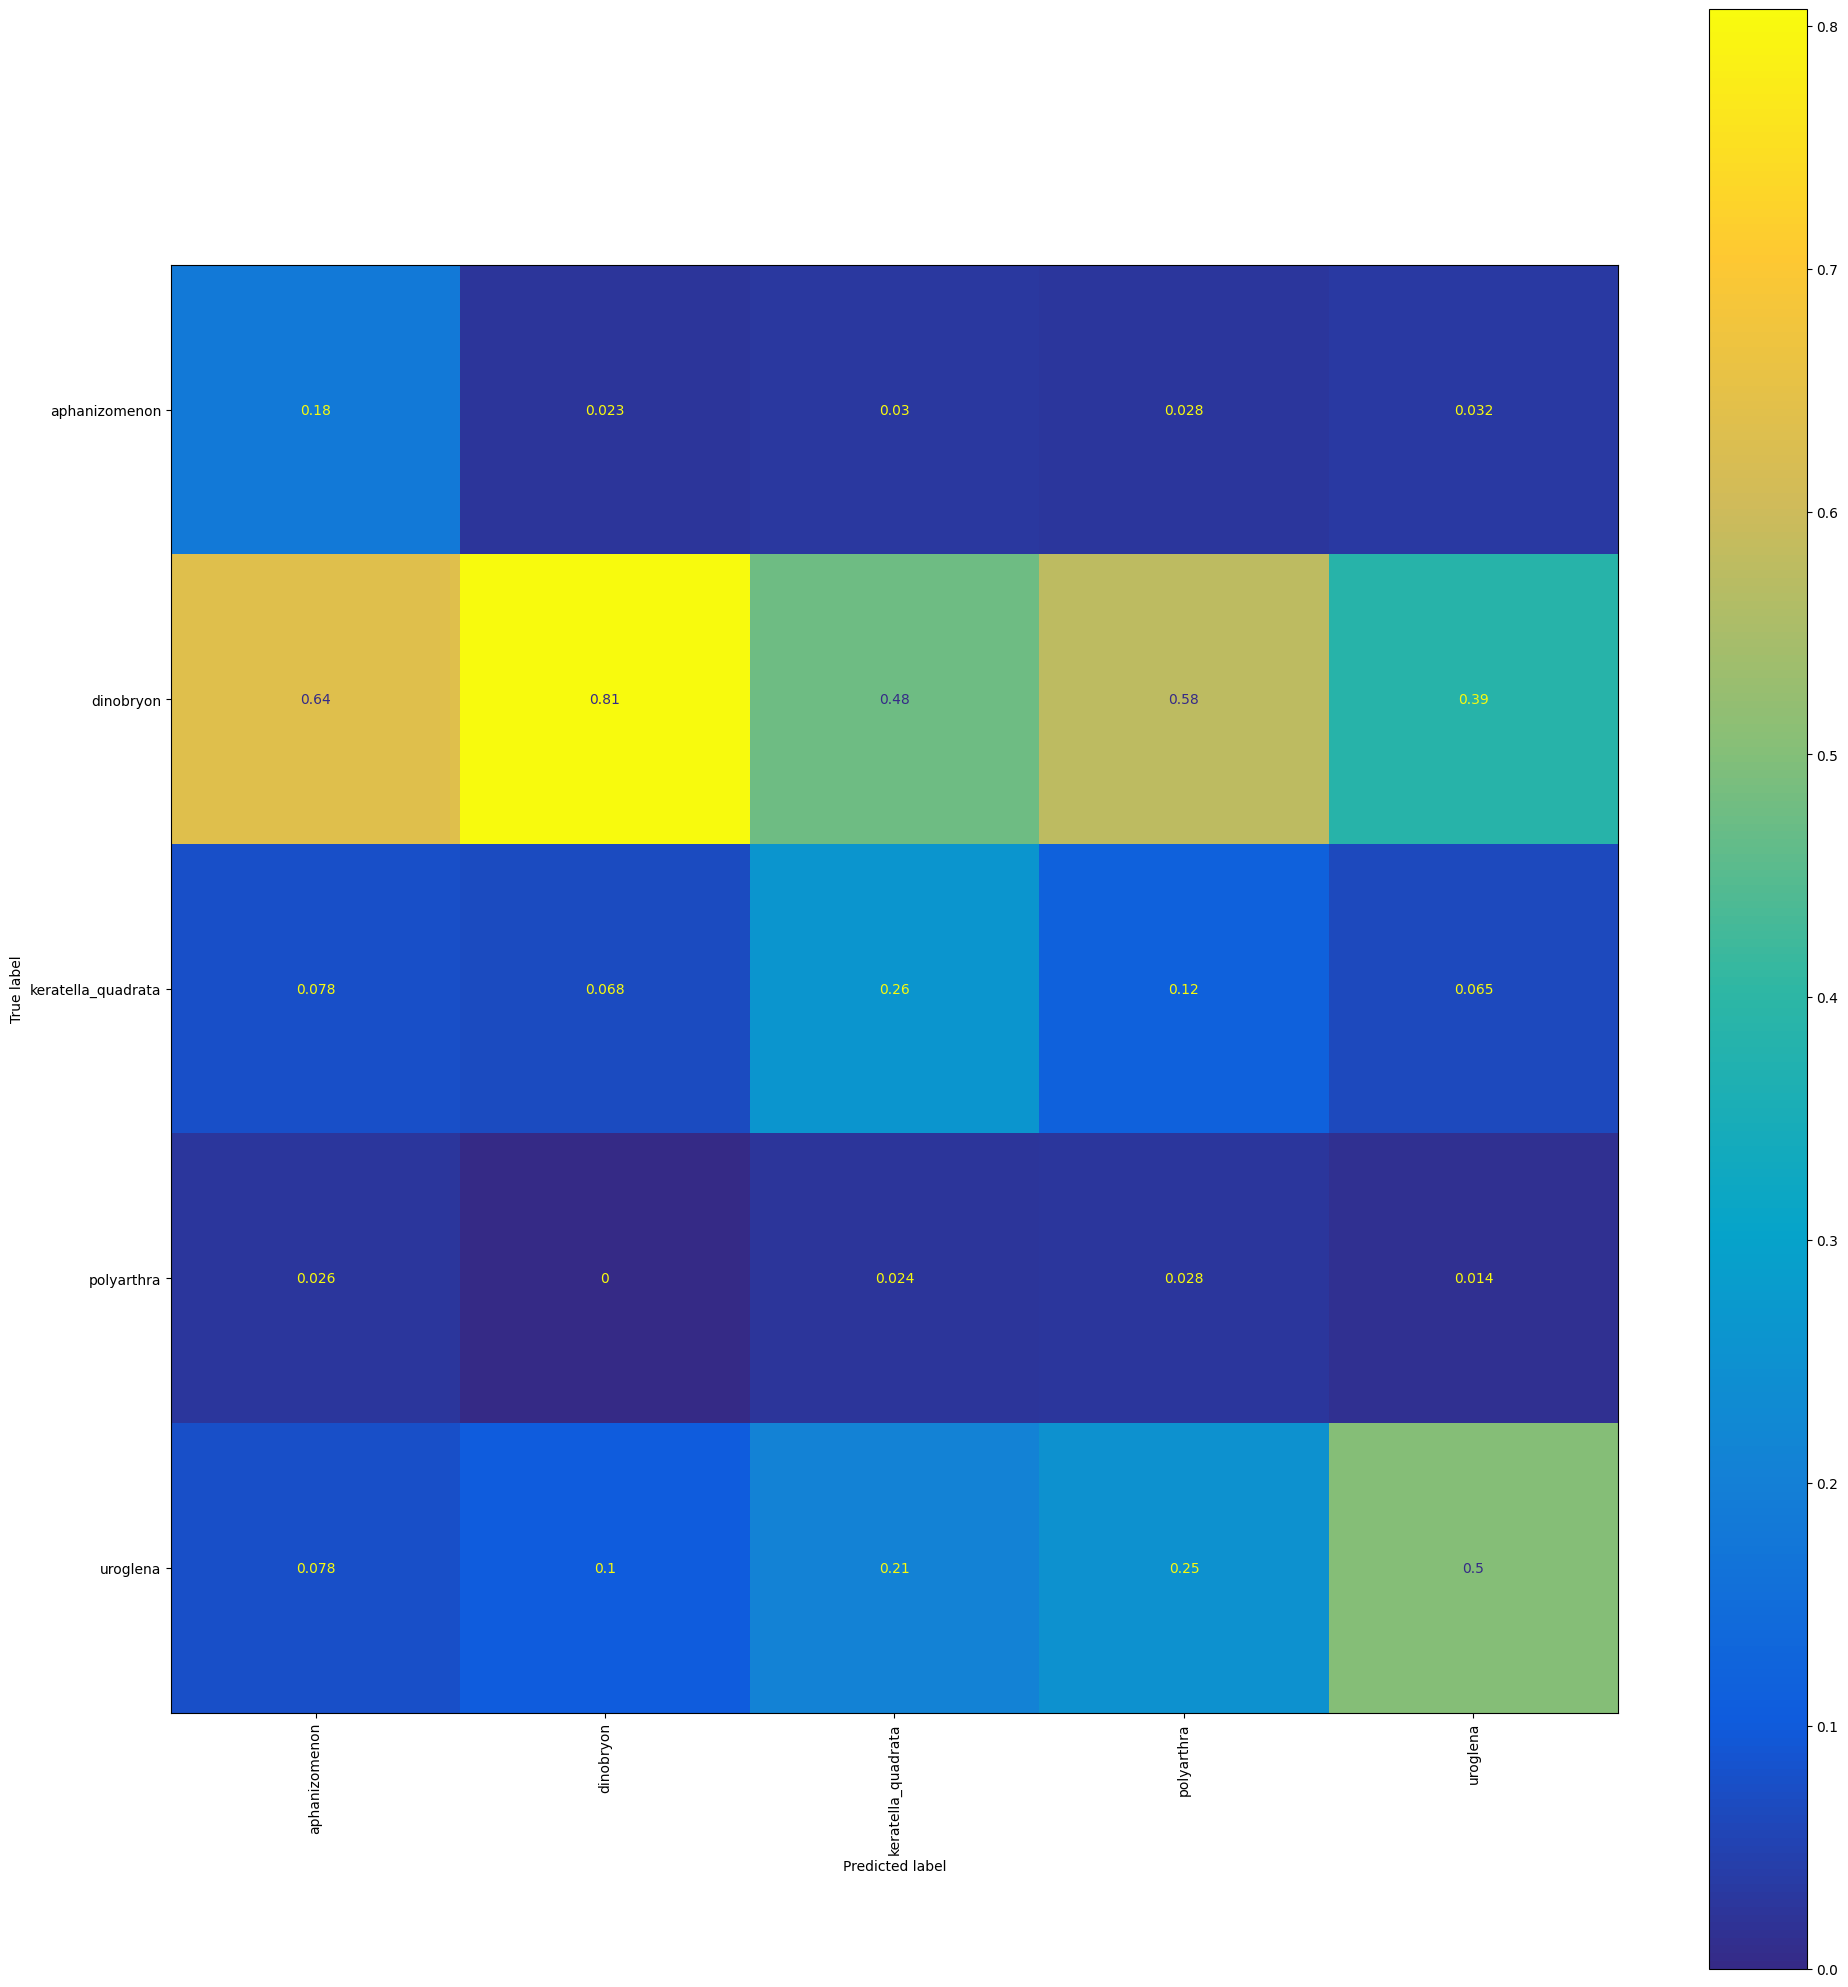

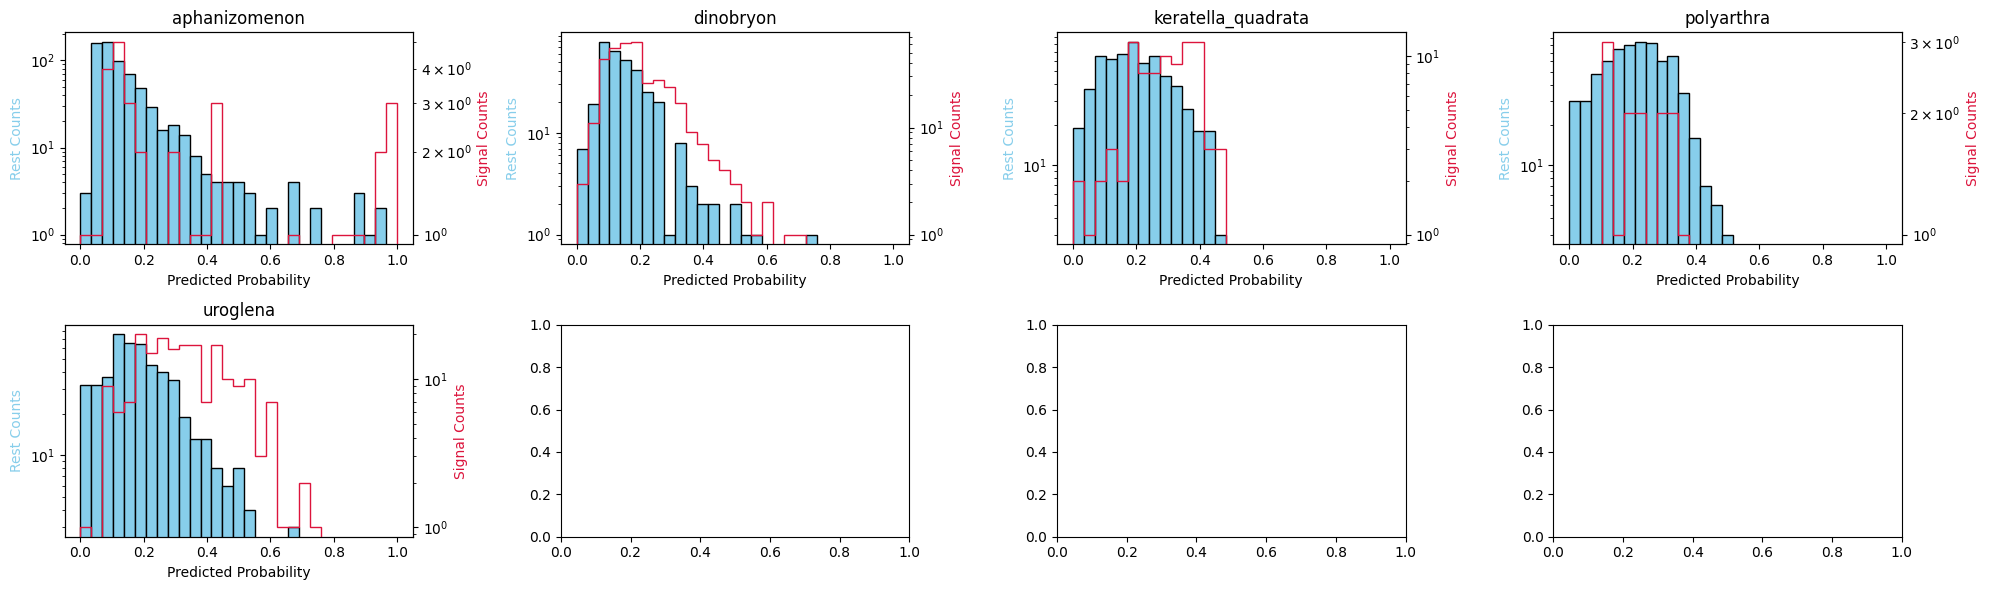

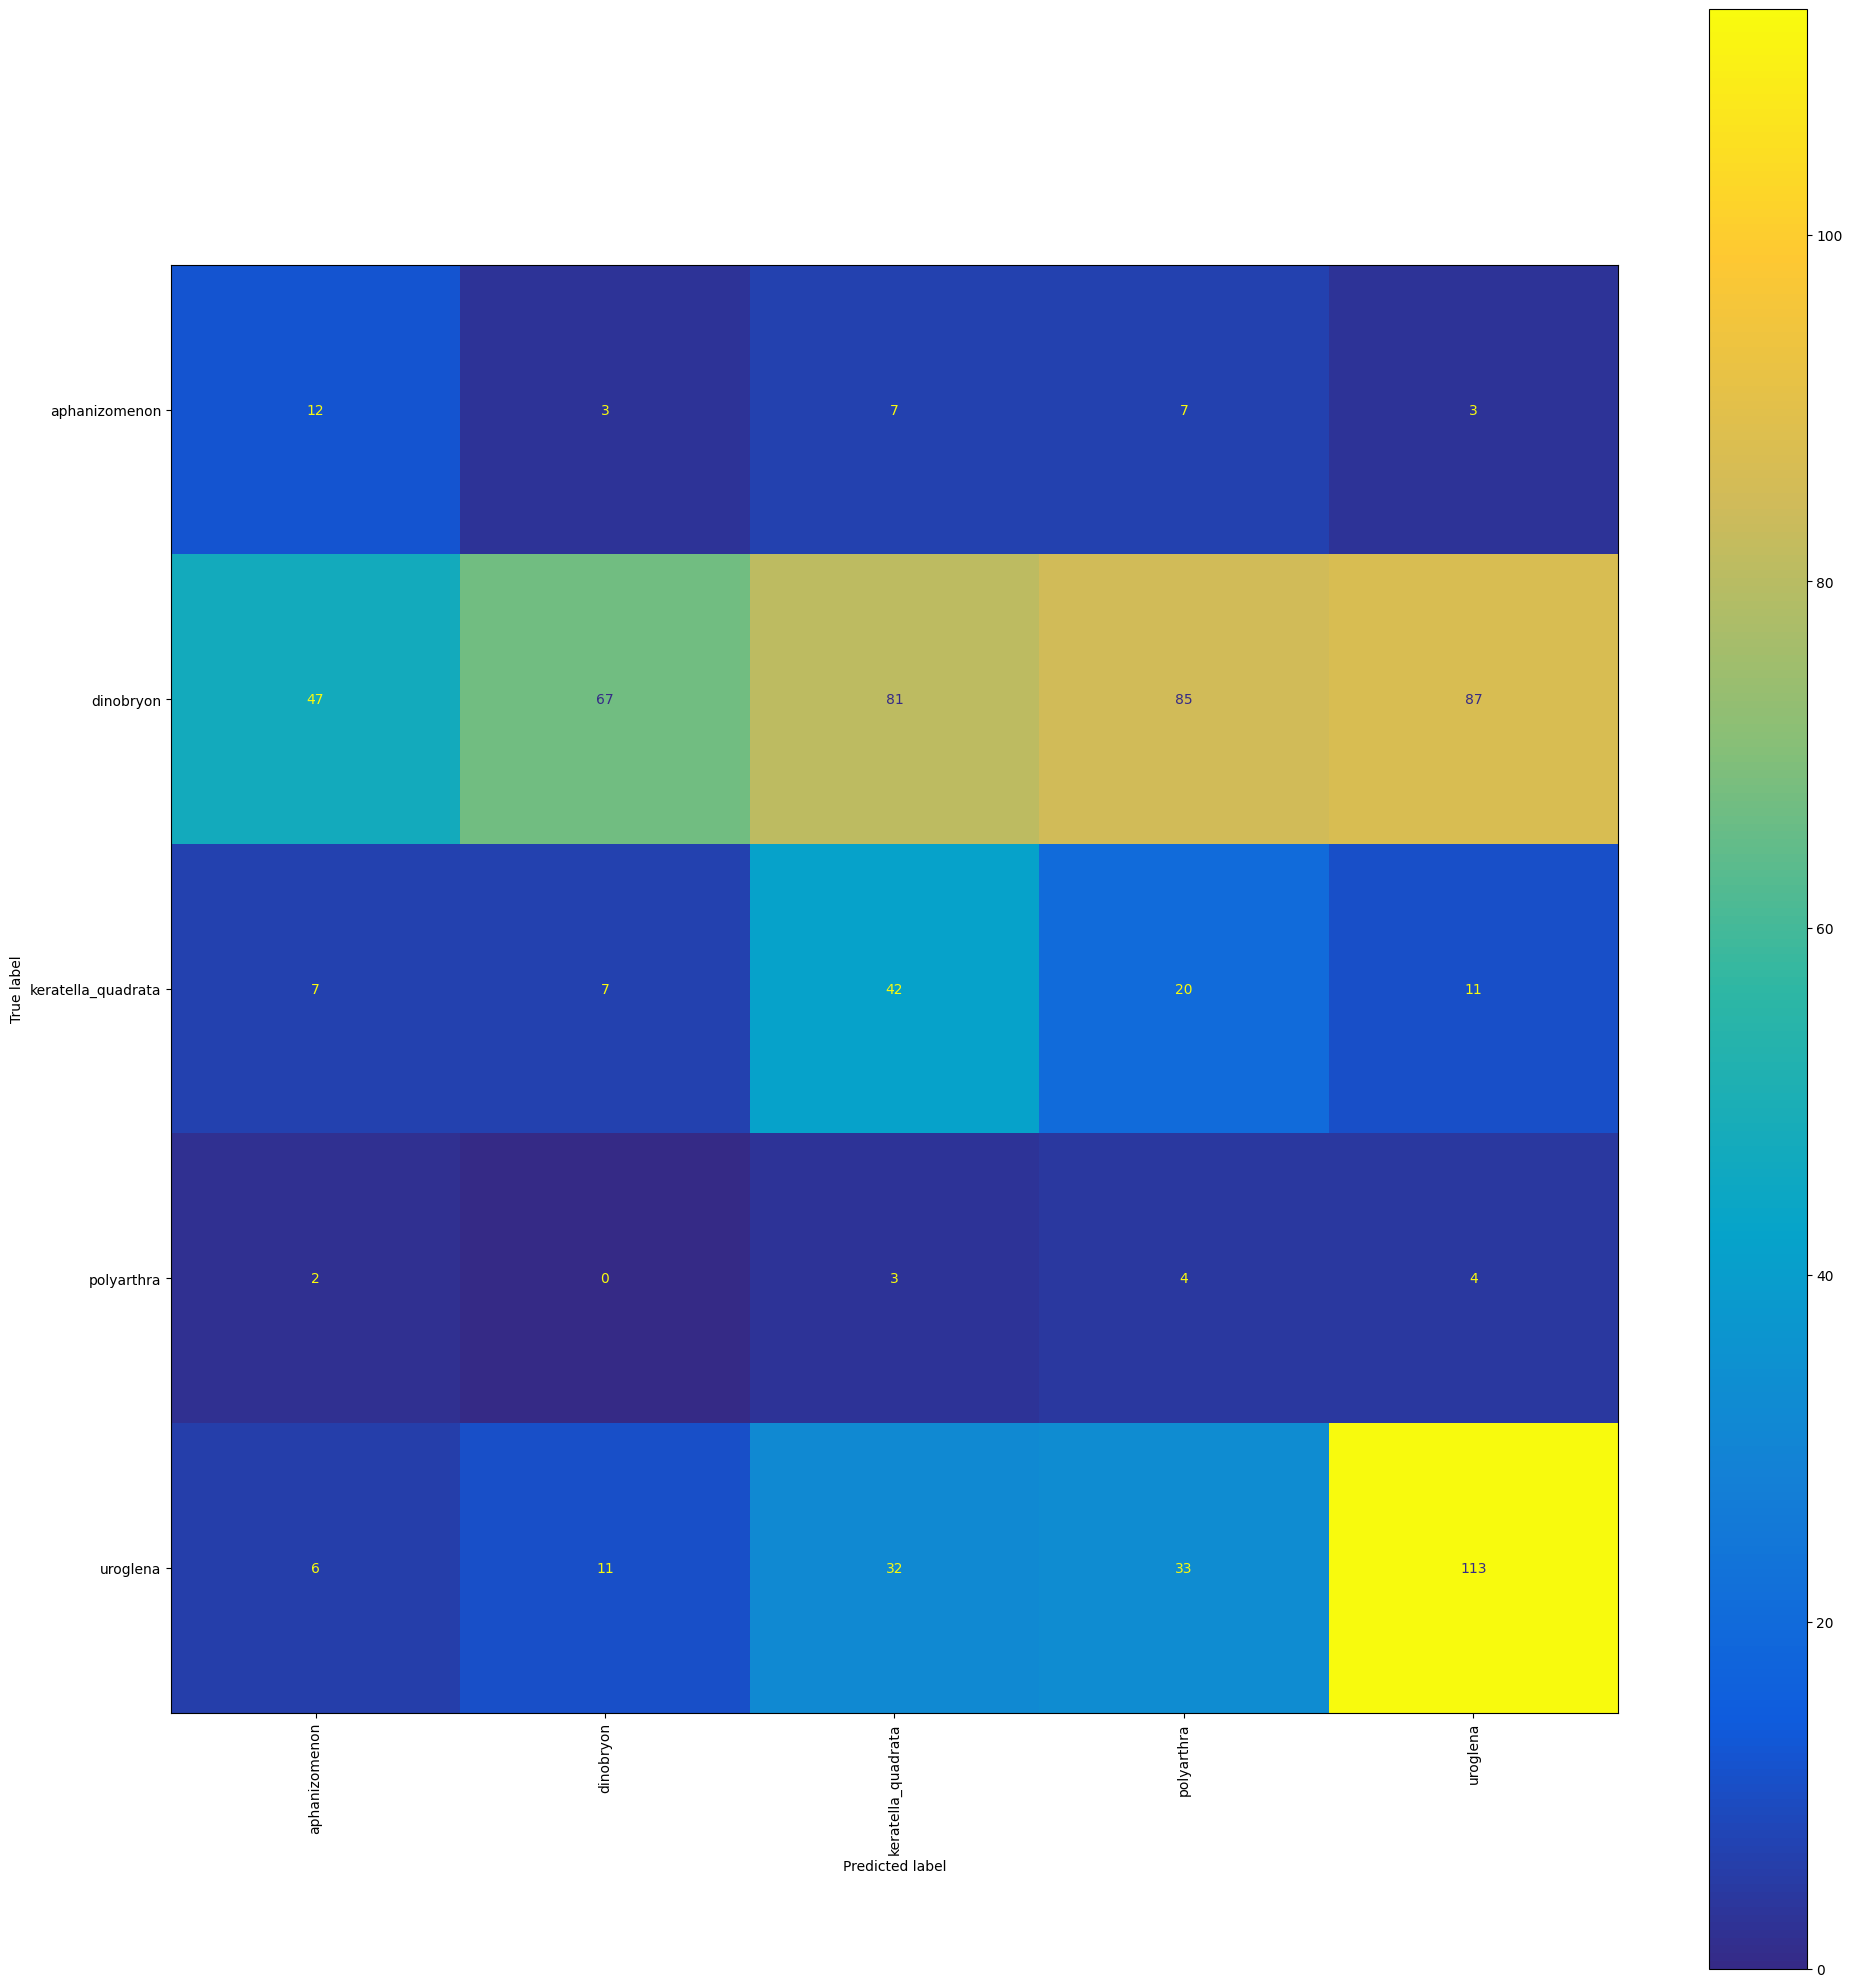

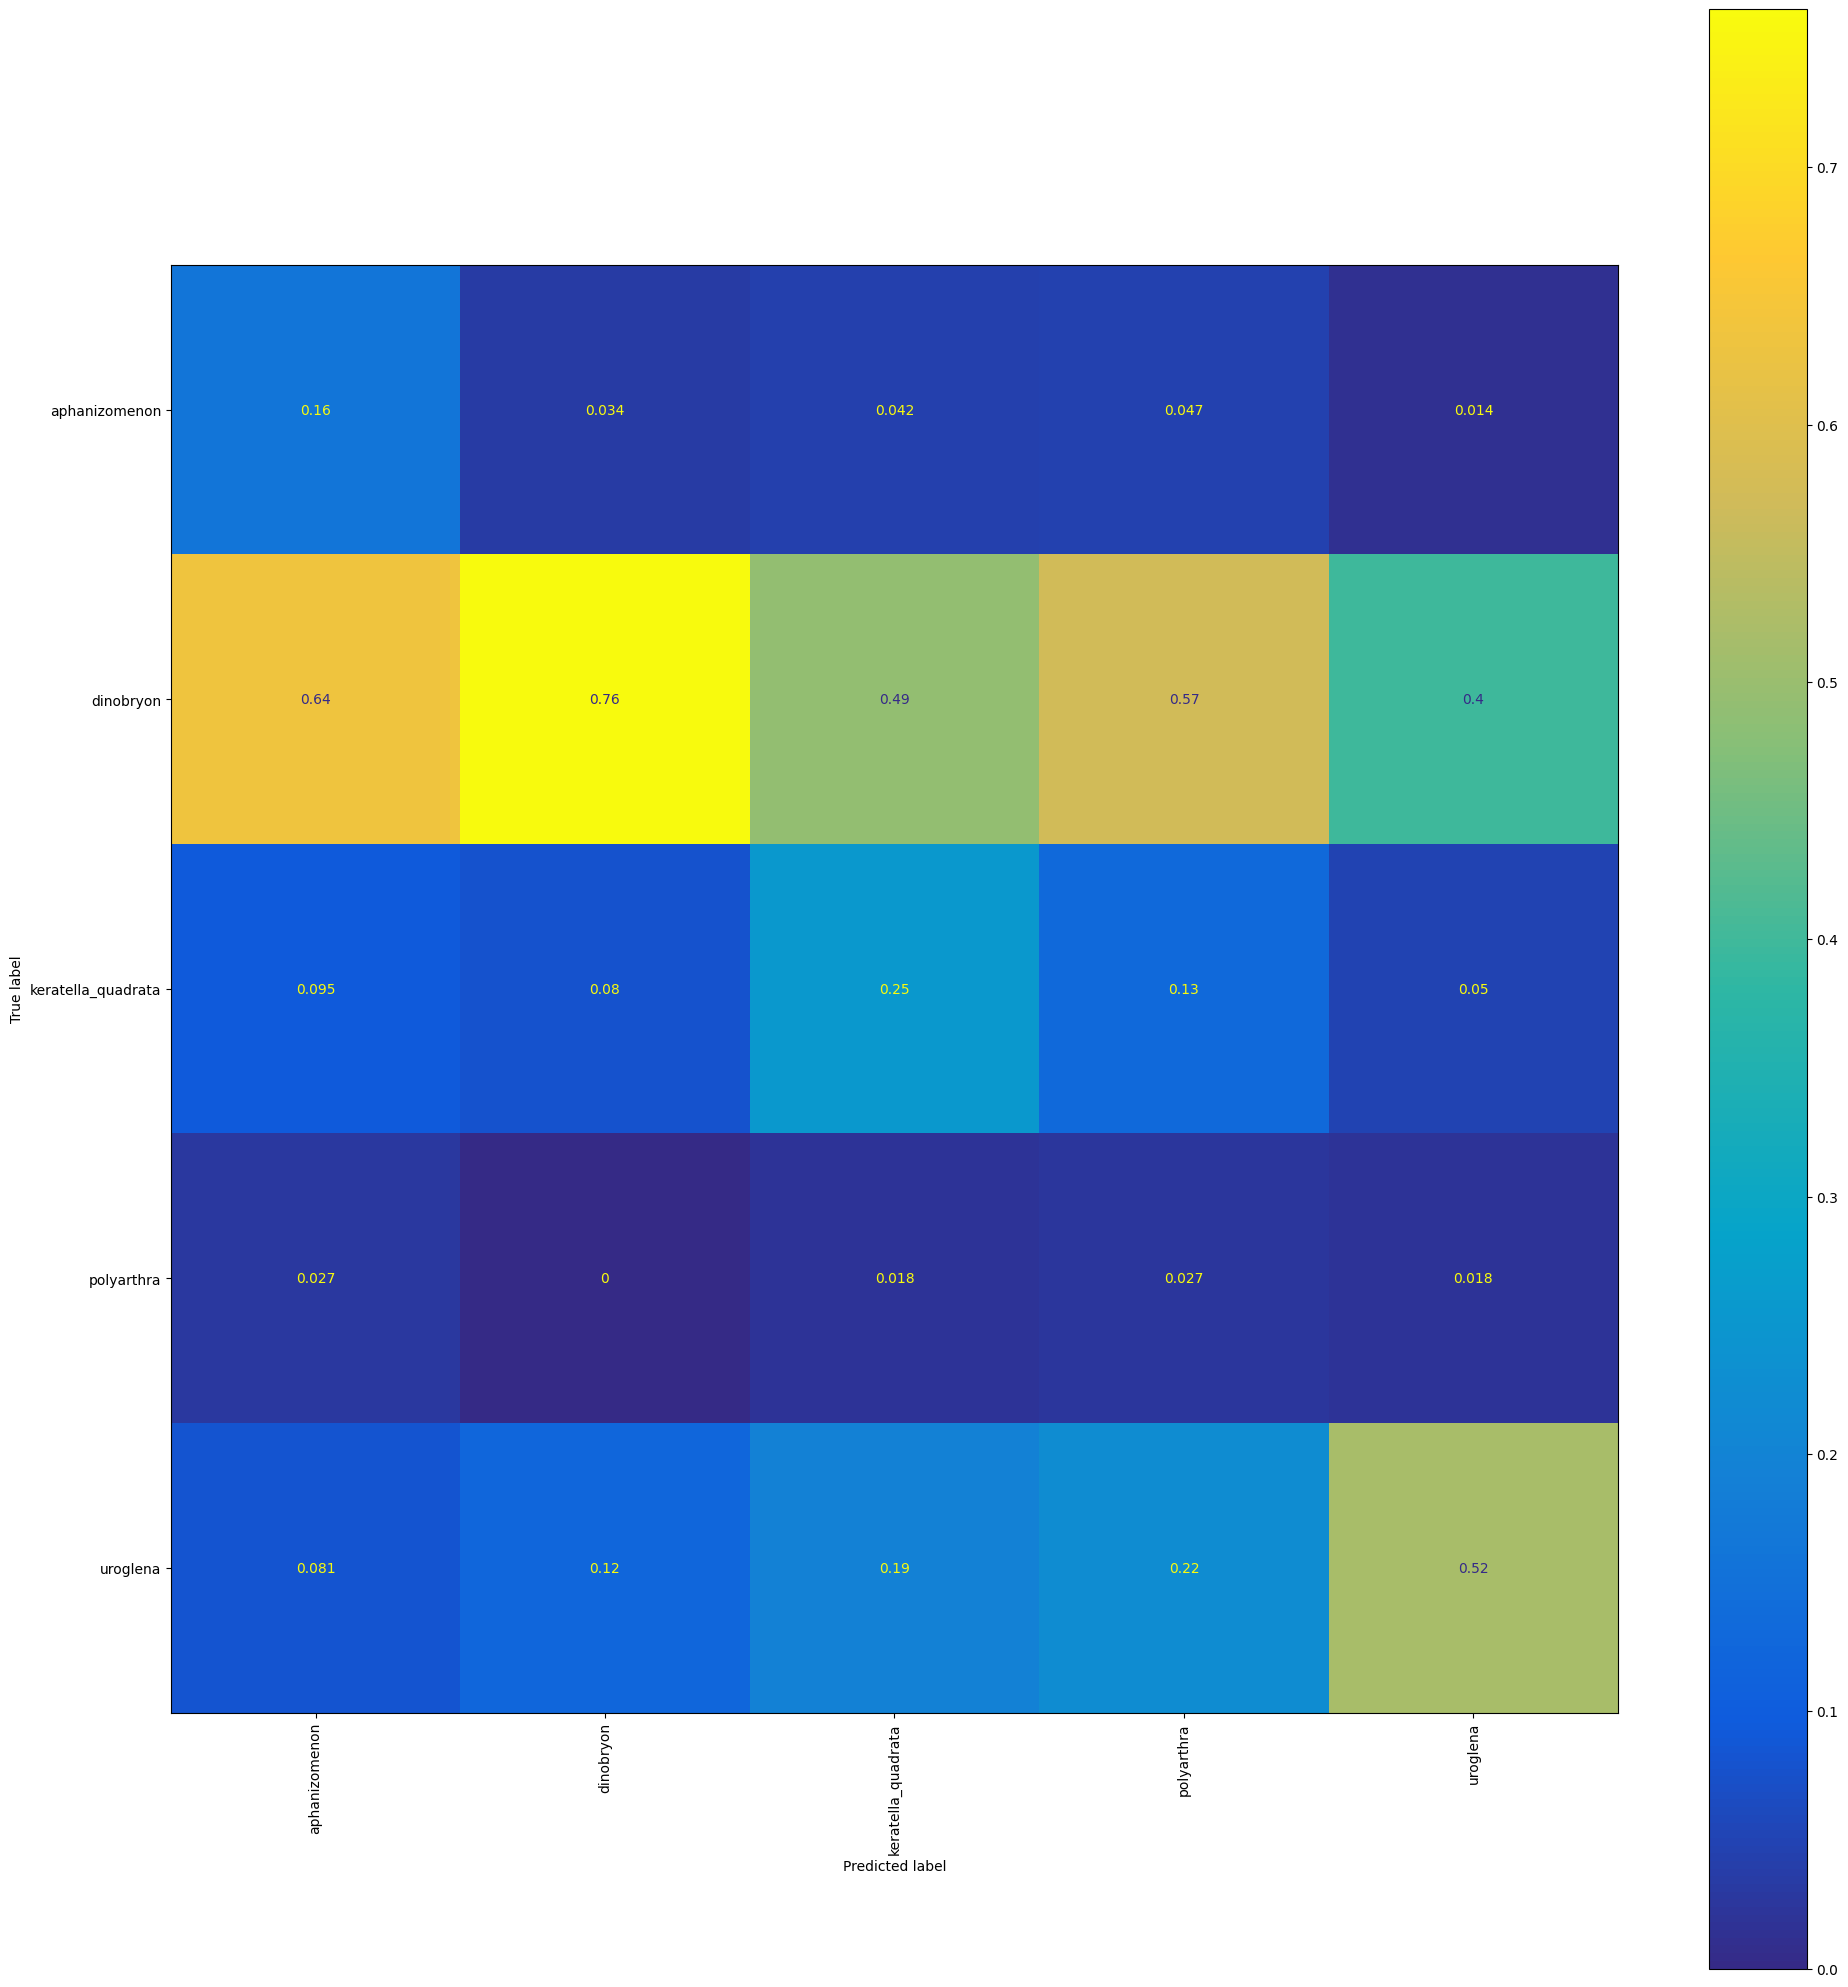

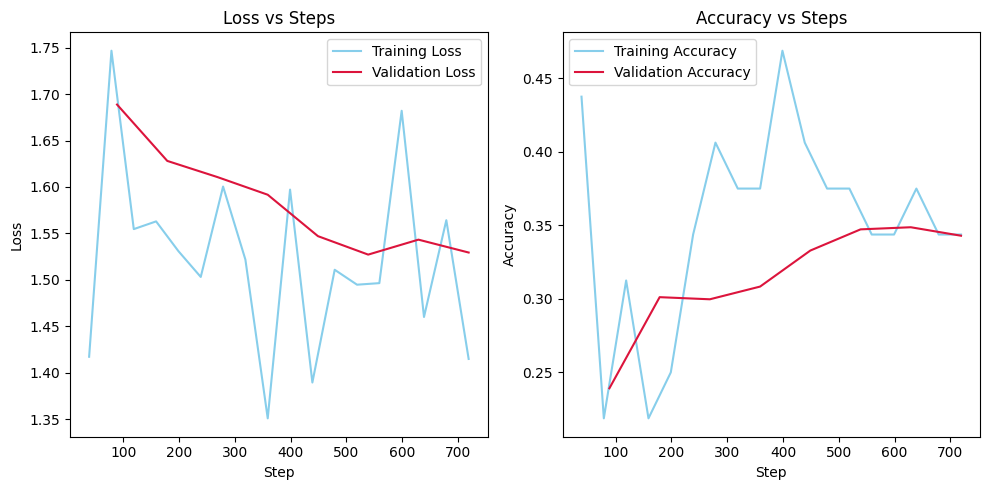

In [25]:
trainer.fit(model, datamodule=datamodule)

INFO:lit_ecology_classifier.data.datamodule:Train size of df: 510
INFO:lit_ecology_classifier.data.datamodule:Validation size of df: 694
INFO:lit_ecology_classifier.data.datamodule:Test size of df: 695


Train size of df:  510
Validation size of df:  694
Test size of df:  695


/home/marco/miniconda3/envs/plank/lib/python3.9/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Testing: |                                                                                                    …

AttributeError: 'AttributeDict' object has no attribute 'datapath'

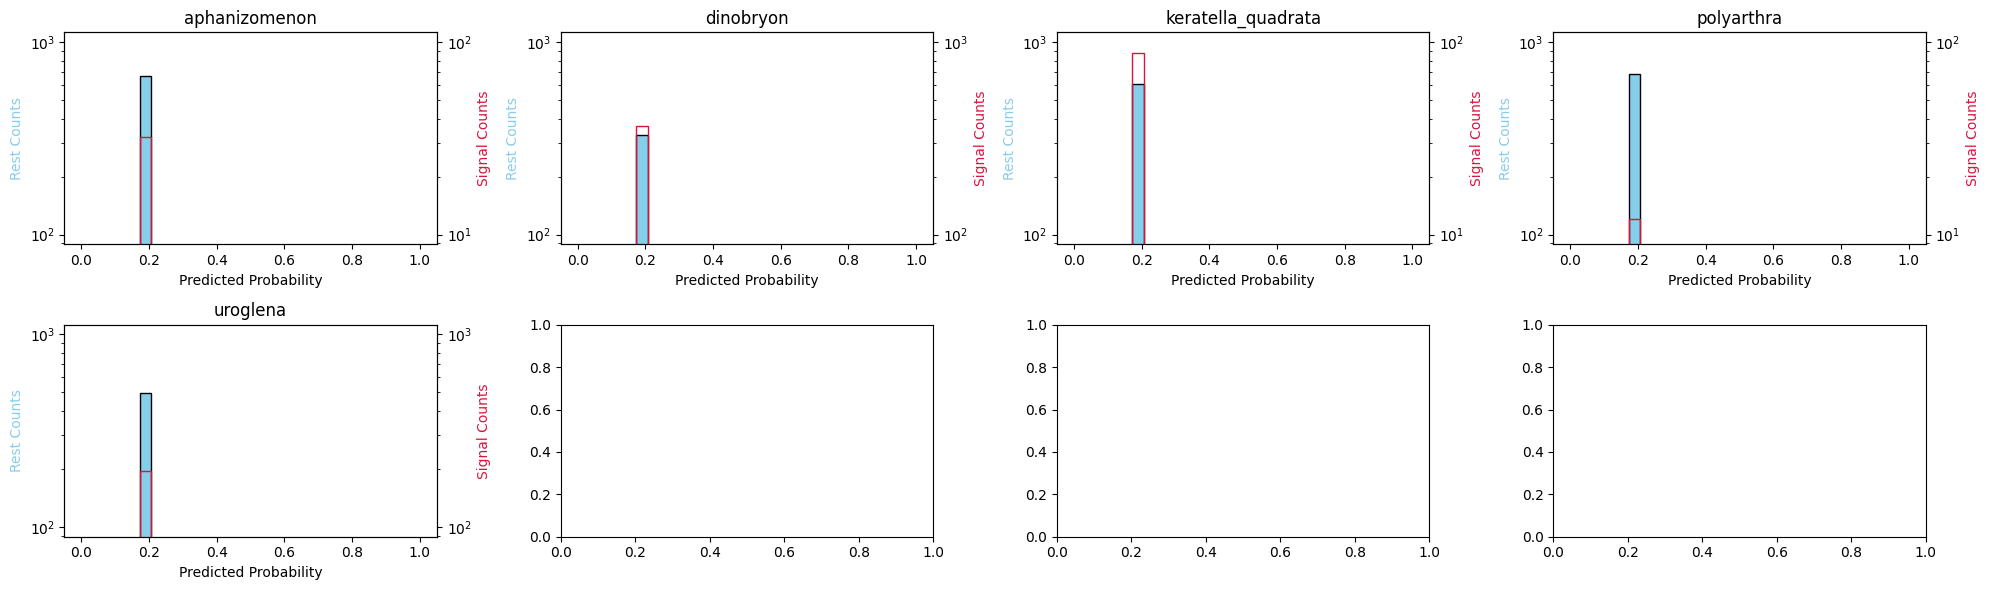

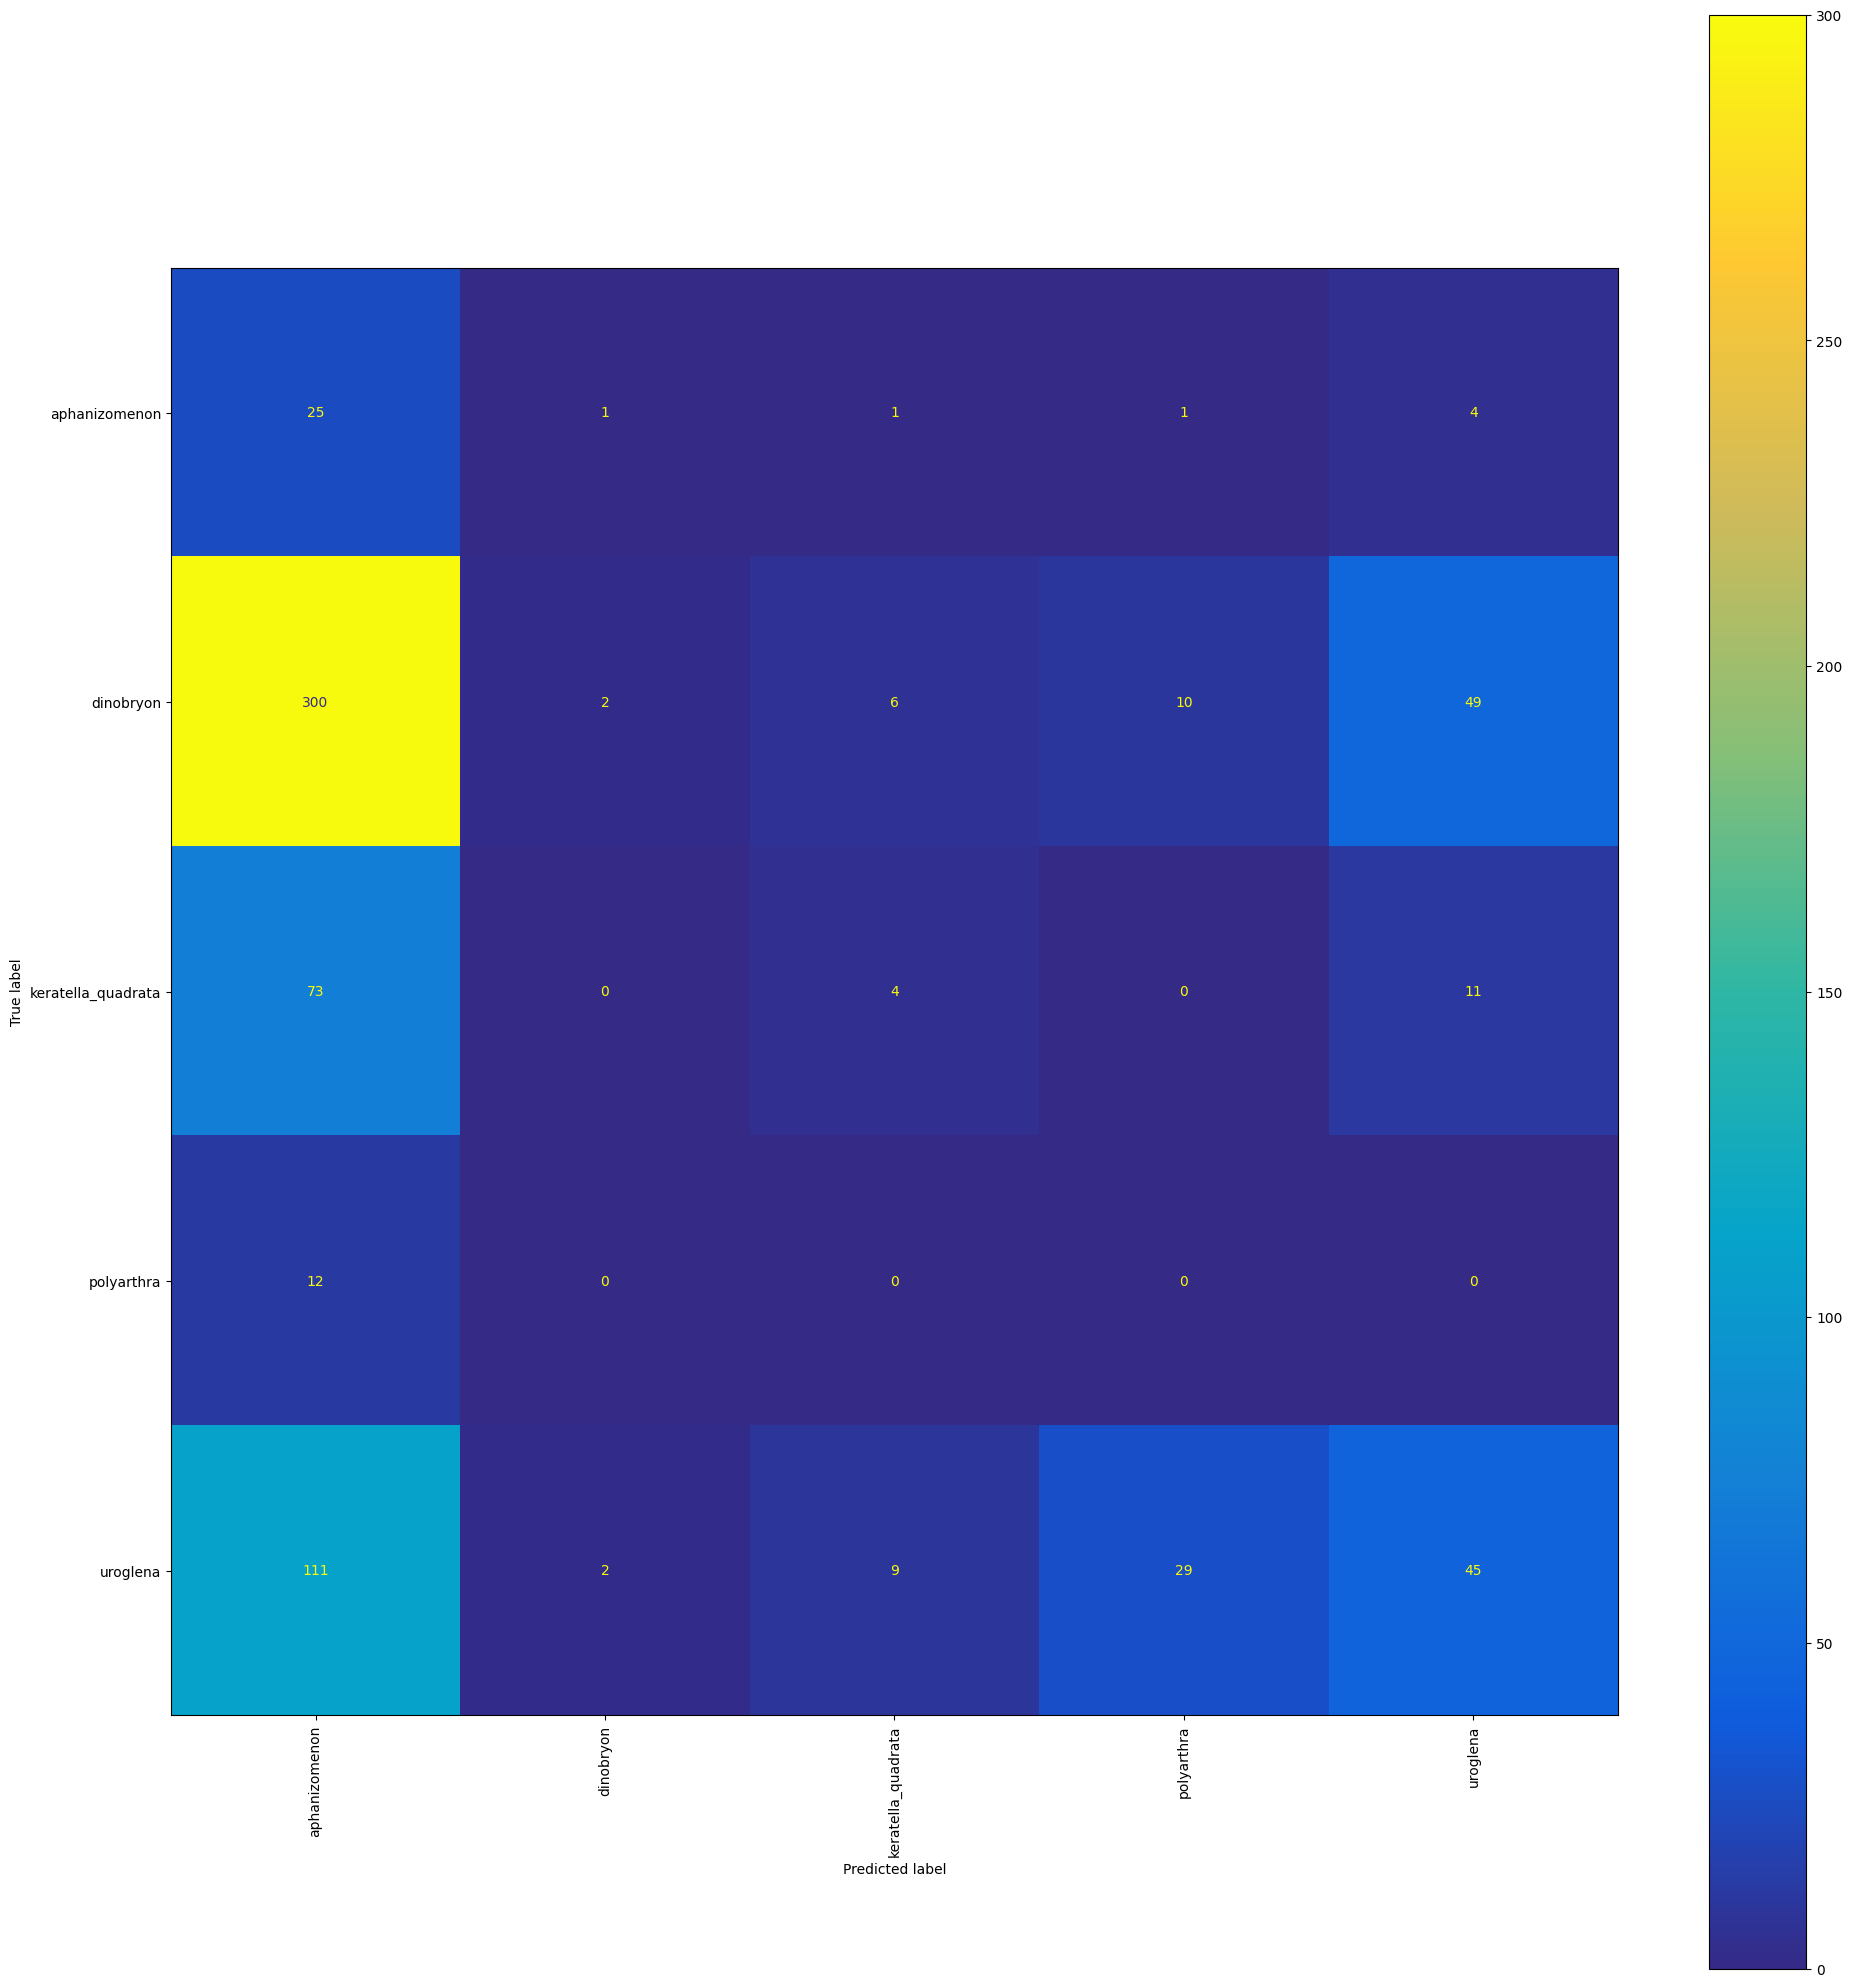

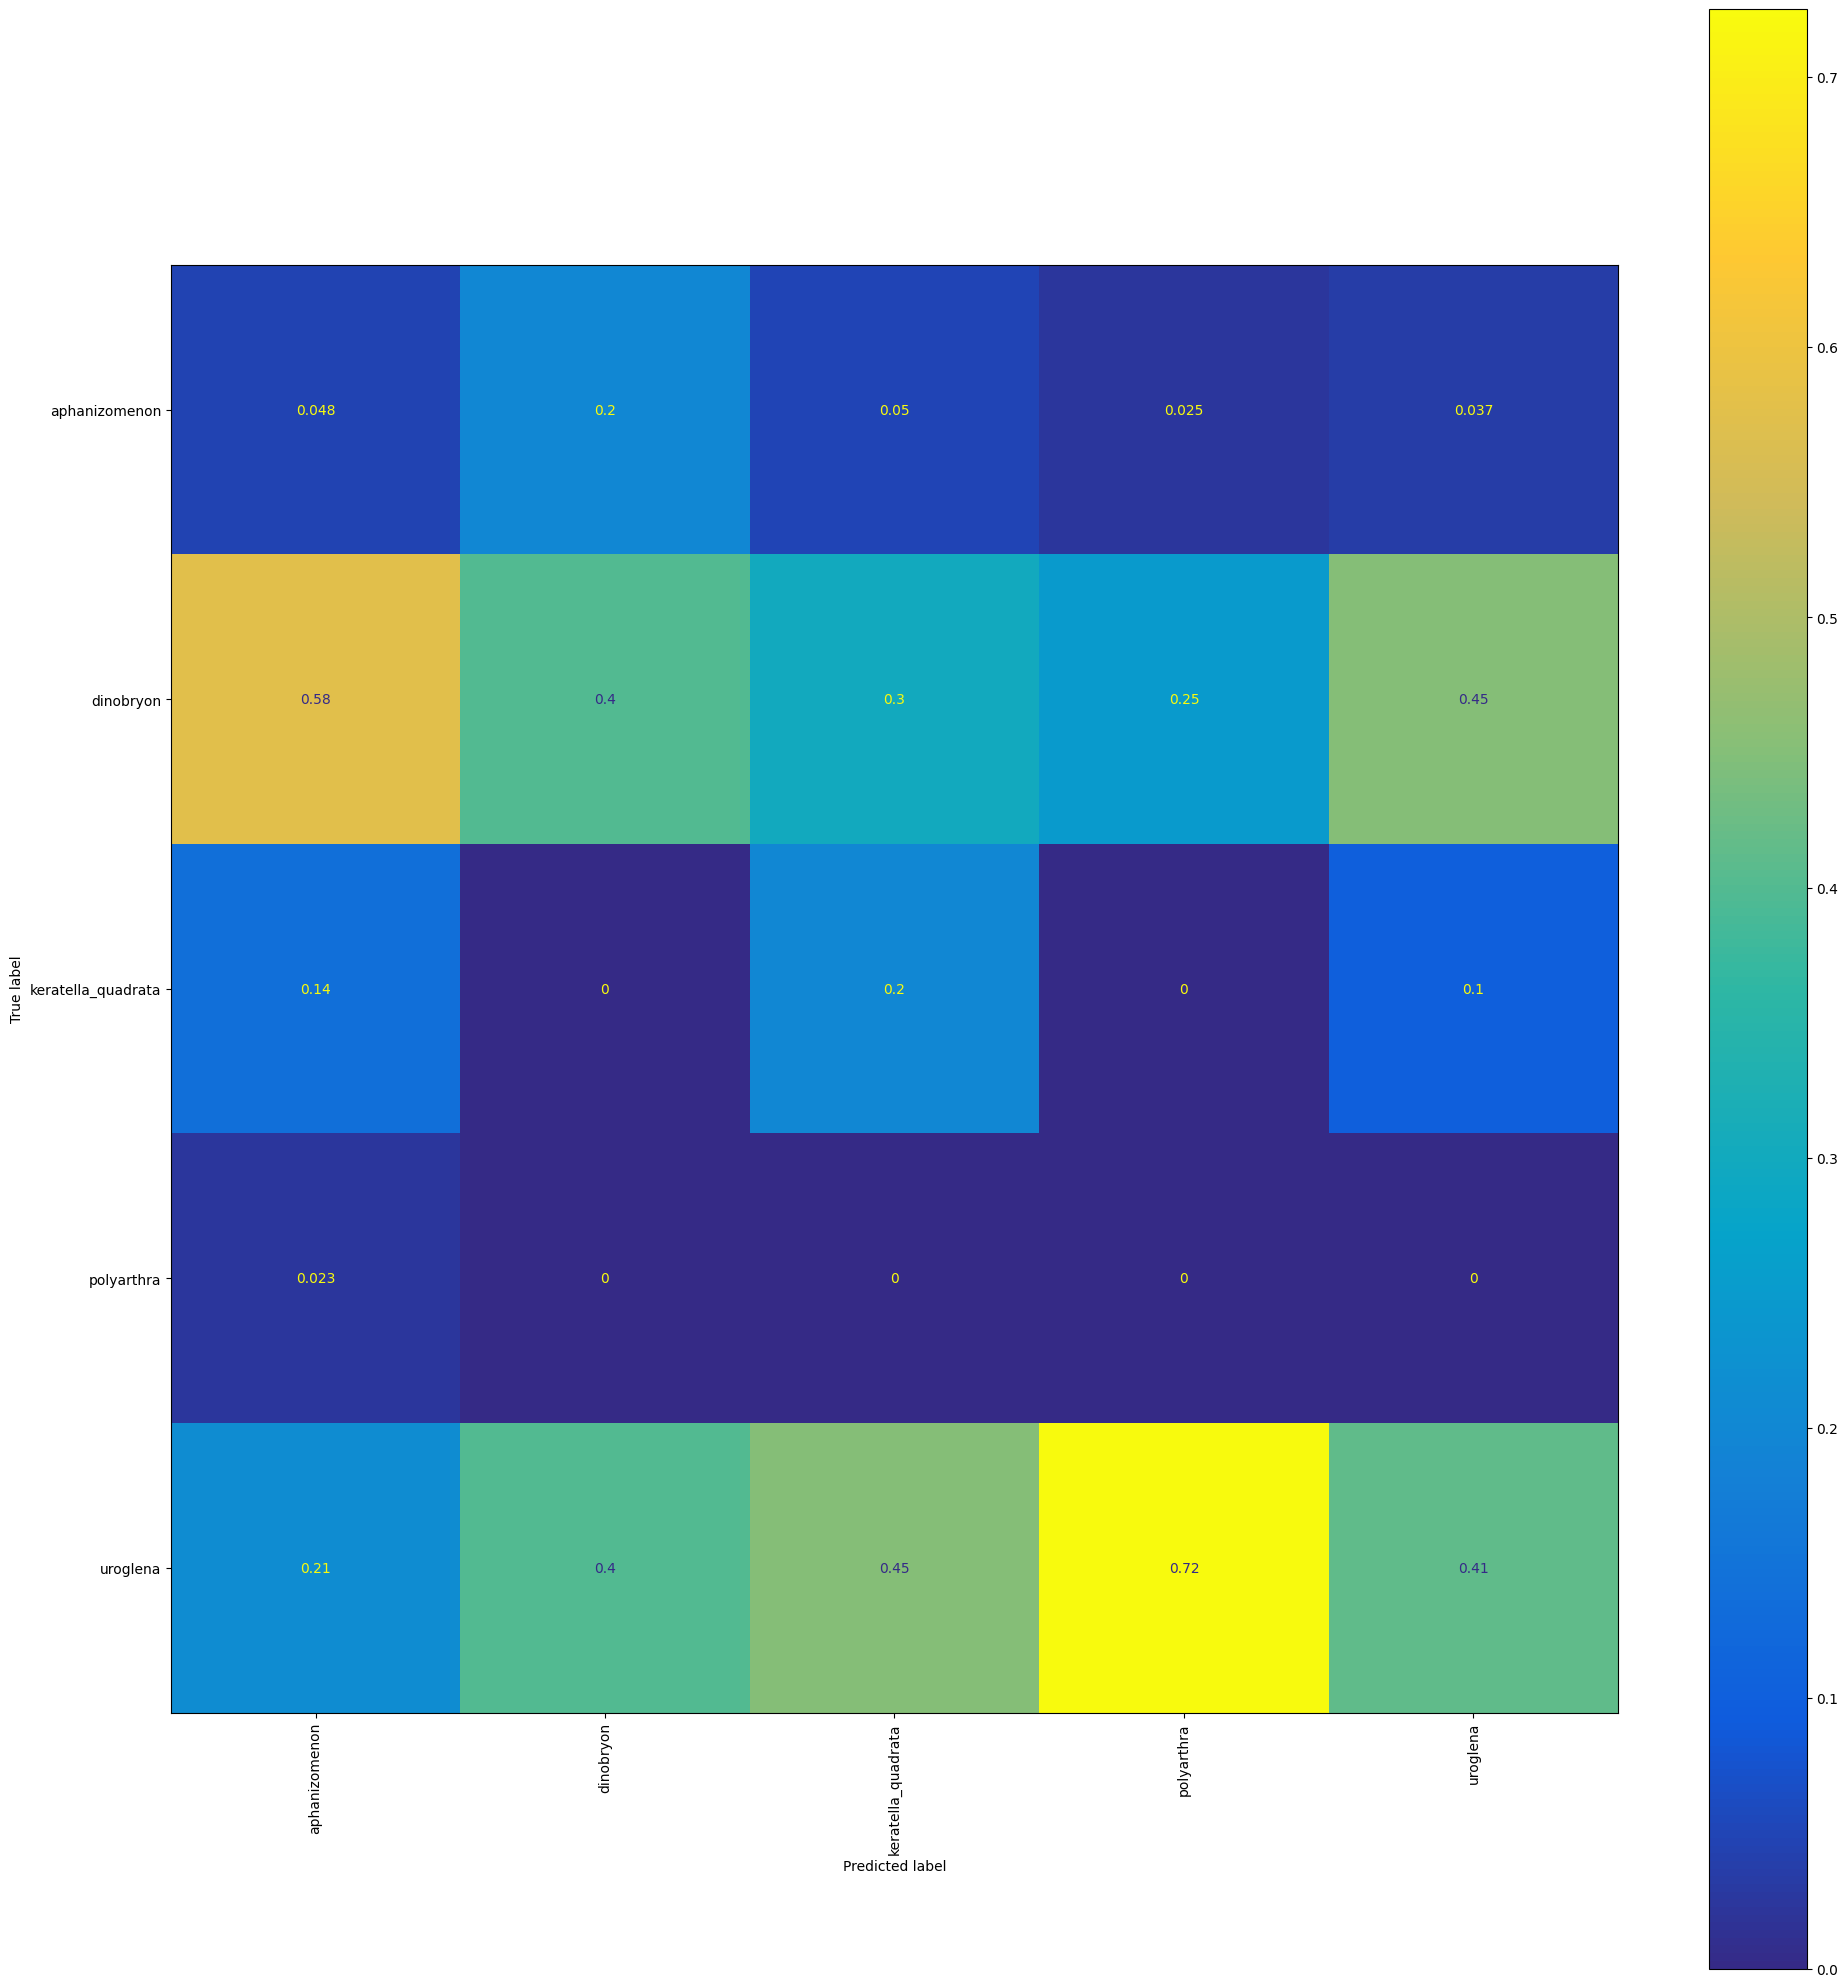

In [28]:
trainer.test(model, datamodule=datamodule)